# Logical Reasoning

Humans make decisions by reasoning with what they know. **Knowledge-based agents** follow the same principle: they use an internal **knowledge representation** and apply **logical inference** to determine their actions. In contrast, **search-based agents** operate with much narrower, task-specific knowledge. They can evaluate available actions and their outcomes, but lack broader reasoning capabilities. For example, a route-finding agent doesn’t know that roads can’t have negative lengths, just as an 8-puzzle agent doesn’t realize that two tiles can’t occupy the same space. Such agents are effective at solving predefined tasks but **cannot generalize** or reason beyond them.

To support more flexible and general-purpose behavior, **Constraint Satisfaction Problems** introduce a **factored representation** of states, as assignments of values to variables. This structure enables domain-independent reasoning and allows the design of more efficient algorithms. 

What if we go further? What if we represent **states** as collections of **objects**, their **relations**, and the **statements** that hold about the world? This leads to a more expressive and semantically rich representation, one where agents can **reason about what exists**, how things are connected, and what is true in their environment. Building on these ideas, **logical agents** leverage logic as a powerful and general framework for representing knowledge. They can **combine and reorganize information**, **accept new goals**, **learn new skills** through instruction, and **adapt dynamically** by updating their knowledge base in response to environmental changes.

This is increasingly important today. While **deep learning** excels at low-level perception (analogous to the brain’s sensory cortices), true intelligence requires the ability to **represent and recombine structured knowledge** for high-level reasoning. Deep learning models largely rely on statistical pattern recognition, lacking explicit understanding. Knowledge-based agents fill this gap by explicitly representing, reasoning about, and manipulating symbolic knowledge. A promising direction is **Neuro-Symbolic AI**, which integrates deep learning’s perceptual capabilities with symbolic reasoning’s structure and flexibility. The result: agents that are not only robust and adaptive but also capable of deeper understanding and generalization.

## Knowledge-Based Agents

We introduce the knowledge-based agents, intelligent systems that represent, store, and reason with knowledge to make decisions, by exploring the structure of the knowledge, the agent’s control loop, and the foundations of reasoning with logic that enable informed and adaptive behavior.

### Knowledge-Base

At the core of a knowledge-based agent is the **knowledge base (KB)**, a collection of sentences expressed in a **formal knowledge representation language**. These sentences encode assertions about the world, which can be either **facts** (e.g., "Riccardo is a parent of Alice") or **rules** (e.g., "If a person is a parent of another, then the first is older than the second"). Sentences that are accepted as true without requiring proof, such as general rules, are called **axioms**. The simplest type of sentence is an **atomic sentence**, which consists of a single symbol, like: 

$\displaystyle P, Q, R, W_1$

We typically write symbols starting with an uppercase letter, possibly followed by subscripts or other characters. To use the knowledge base, an agent must be able to **add new information** (tell operation) and **query what is known** (ask operation). Both of these may involve **inference**, which is the process of deriving new conclusions from existing sentences (e.g., answering a query like "Is Riccardo older than Alice?" based on known facts and rules). We can defince a KB class as a **database** of facts, rules, and relationships that the agent can use to reason about its actions and make decisions:

In [498]:
class KB:

    # Initialize the knowledge base
    def __init__(self):
        self.sentences = []

    # Add the sentence to the KB
    def tell(self, sentence):
        self.sentences.append(sentence)

    # Query the KB
    def ask(self, query):
        raise NotImplementedError

### Agent Control Loop

The agent interacts with its environment through a continuous **sense–think–act cycle**. It maintains an internal KB that stores facts and rules about the world. When the agent perceives new information, it incorporates it into the KB (tell). To decide what to do next, the agent **reasons** over its knowledge by formulating and answering queries (ask). Ideally, a logical agent could determine the best course of action entirely through reasoning. In practice, however, agents often **combine logical inference with search techniques** to efficiently choose actions, especially in complex or uncertain environments. Based on its reasoning, the agent selects an appropriate action. For example, if the KB contains the fact "Danger", the agent might decide to "Run"; if it knows "Food" is available, it might choose to "Eat". If no relevant knowledge is available, it may default to an exploratory action like "Explore" to gather more information. Below is a general implementation of a logic-based agent that follows the control loop and uses the abstract KB class:

In [499]:
class LogicAgent:

    def __init__(self, kb):

        # The knowledge base (KB) where the agent will store and query information
        self.kb = kb      
        
        # A counter to keep track of time steps   
        self.time = 0         

    # Convert a percept into a sentence to be added to the KB.
    def make_percept_sentence(self, percept, t):
        raise NotImplementedError("make_percept_sentence must be implemented")

    # Create a query asking what the agent should do at time t.
    def make_action_query(self, t):
        raise NotImplementedError("make_action_query must be implemented")

    # Convert the chosen action into a sentence to be added to the KB.
    def make_action_sentence(self, action, t):
        raise NotImplementedError("make_action_sentence must be implemented")

    # The main method that the agent will call to act based on its percept.
    def act(self, percept):
        # Step 1: Tell the KB what was perceived
        percept_sentence = self.make_percept_sentence(percept, self.time)
        self.kb.tell(percept_sentence)

        # Step 2: Ask the KB what action to take
        action_query = self.make_action_query(self.time)
        action = self.kb.ask(action_query)

        # Step 3: Tell the KB what action was taken
        action_sentence = self.make_action_sentence(action, self.time)
        self.kb.tell(action_sentence)

        # Step 4: Advance time and return action
        self.time += 1
        return action

After acting, the environment may change, generating new percepts. These are added to the KB, and the cycle begins again. In this way, the KB becomes more than a repository of facts, it enables the agent to **perceive, reason, and act intelligently and adaptively** over time.

The knowledge-based agent separates **domain-specific content** from **general-purpose inference procedures**, allowing the same reasoning mechanisms to be applied across different domains, by simply changing the knowledge base. Such agents are defined by **what they know**, rather than **how they are implemented**, enabling greater modularity, reuse, and adaptability. This design also promotes economy of representation: only the essential facts are explicitly stored, while additional information is inferred as needed. In contrast to search-based agents, which are limited to answering narrowly defined, task-specific questions, a logical agent can answer any query that logically follows from its available knowledge.

### Reasoning with Logic

At the heart of human reasoning lies **logic**, a formal system for representing knowledge and drawing conclusions. Logic provides a **precise language** for expressing **facts** about a domain, along with **systematic rules** for deriving new insights from those facts. To introduce its fundamental concepts in an intuitive way, we will use arithmetic as a running example. Arithmetic is familiar yet expressive enough to illustrate the structure of logical statements, the process of inference, and the strength of formal reasoning. To understand logic formally, we focus on four five key notions: syntax, semantics, models, entailment, and inference.

**Syntax** defines the **formal structure of the language**, it specifies **which symbols are allowed** and how they can be combined to form **well-formed sentences**. Syntax concerns only the form of expressions, not their meaning. In arithmetic, the syntax includes symbols such as numbers, variables, operators (like + and −), and parentheses. The rules of syntax determine how these symbols can be arranged to form valid expressions. A sentence like 

$\displaystyle x + y = 4$

is syntactically correct, while 

$\displaystyle x 4 y + = $

is not. Here, syntax enforces rules such as requiring an operator between operands and ensuring the = sign follows a valid expression on both sides. In general, syntax includes predicates (properties of objects or relations between them), functions, constants, and logical connectives (such as and, or, implies, etc.). These elements must be combined according to strict syntactic rules to produce meaningful formulas that can be evaluated or reasoned about.

**Semantics** defines the **meaning of sentences** in a logical language. While syntax tells us how to write valid sentences, semantics tells us **what those sentences mean** and **whether they are true or false** in a particular situation. This depends on the **interpretation of symbols**, such as the values of variables and the meaning of functions or predicates. For example, in arithmetic, the sentence 

$\displaystyle  x + y = 4$

is well formed, however can mean different things depending on the values assigned to "x" and "y". If 

$\displaystyle x=2$ and $\displaystyle y=2$ 

the sentence is true, but if

$\displaystyle x=1$ and $\displaystyle y=1$

the sentence is false. So, the truth of a sentence depends on the **specific situation** we are considering. Semantics gives logic its **connection to the real world**: it tells us **how the symbols we write relate to facts and situations**, and helps us decide whether a statement correctly describes a given state of affairs. In classical logic, every sentence is either true or false, there are no shades in between. In other types of logic, such as fuzzy logic, truth can be a matter of degree, allowing for statements to be partially true.

A **model** represents a **specific possible world** that defines how the symbols are interpreted and determines whether sentences are true or false in that world. In arithmetic, a model can be a particular assignment of values to variables:

$\displaystyle x = 2, y = 2$ is a model

$\displaystyle x = 1, y = 1$ is another model

In general, a model provides **a mapping from the symbols to their corresponding meanings**. This mapping allows us to **interpret** each sentence and **determine its truth** based on the situation described by the model. We say that **a model satisfies a sentence** if the sentence is true under that interpretation. In that case, the model is also said to be **a model of the sentence**. We write:

$\displaystyle \mathcal{M}(A)$

to denote the set of all models in which the sentence is true. For example, the sentence 

$\displaystyle x + y = 4$

is satisfied by all assignments of values to x and y such that their sum is 4, such as 

$\displaystyle (2,2), (1,3), (0,4)$, etc. 

The set of all such assignments forms the set of models for the sentence. 

Once we have a formal **notion of truth**, we can define what it means for one sentence to **logically follow** from another. This relationship is called **entailment**. A sentence (or set of sentences) logically entails another sentence if, in every situation where the first sentence(s) are true, the second must also be true. This is written in logical notation as:

$\displaystyle A \models B$

The formal definition is:

$\displaystyle A \models B \quad \Leftrightarrow \quad \mathcal{M}(A) \subseteq \mathcal{M}(B)$

This means that every model in which sentence A is true is also a model in which B is true. In other words, if a world satisfies A, it must also satisfy B. Entailment is central to logical reasoning, as it captures the idea of **drawing valid conclusions from known facts**. For example, in arithmetic, we intuitively accept that the sentence: 

$\displaystyle x = 0$

entails the sentence:

$\displaystyle x * y = 0$

because in any situation where x is zero, the product x * y must also be zero, regardless of the value of y. 

Finally, we define **inference**, as **the process by which we can derives new sentences from existing ones**. While entailment is a **semantic notion** (it tells us what must be true given certain facts), inference is a **syntactic procedure** that attempts to identify those truths through symbolic manipulation. We write:

$\displaystyle \text{KB} \vdash_i A$

to indicate that sentence A is inferred from the knowledge base KB using inference procedure i. This means that A has been derived from KB by applying the rules of the inference system.

A correct inference procedure must be **sound**, meaning **it derives only sentences that are logically entailed by the KB**:

$\displaystyle \text{KB} \vdash_i \alpha \quad \Rightarrow \quad \text{KB} \models \alpha$

Ideally, it is also **complete**, meaning **it can derive every sentence that is entailed**: 

$\displaystyle \text{KB} \models \alpha \quad \Rightarrow \quad \text{KB} \vdash_i \alpha$

Inference is what **allows a knowledge-based agent to reason**, to draw conclusions that were not explicitly stated but must hold given what is known. Although inference operates purely on the syntax of logical expressions, a sound inference procedure will yield semantically valid conclusions. In this way, inference links the formal structure of logic to the process of reasoning, enabling agents to **think symbolically**, **derive implications**, **make decisions**, and **extend their knowledge through deduction**. As Wittgenstein famously put it: "The world is everything that is the case". Thus, if the knowledge base accurately reflects the real world, any sentence derived from it by a sound inference procedure will also be true in the real world:

A final and important challenge is **the problem of grounding**, how to connect the agent’s internal symbolic representations to the external world. The knowledge base consists of syntactic structures: formal sentences made up of symbols. But a crucial question arises: **how do these symbols come to represent real-world facts**? This is not just a technical issue, but a **deep philosophical challenge** in the design of intelligent systems.

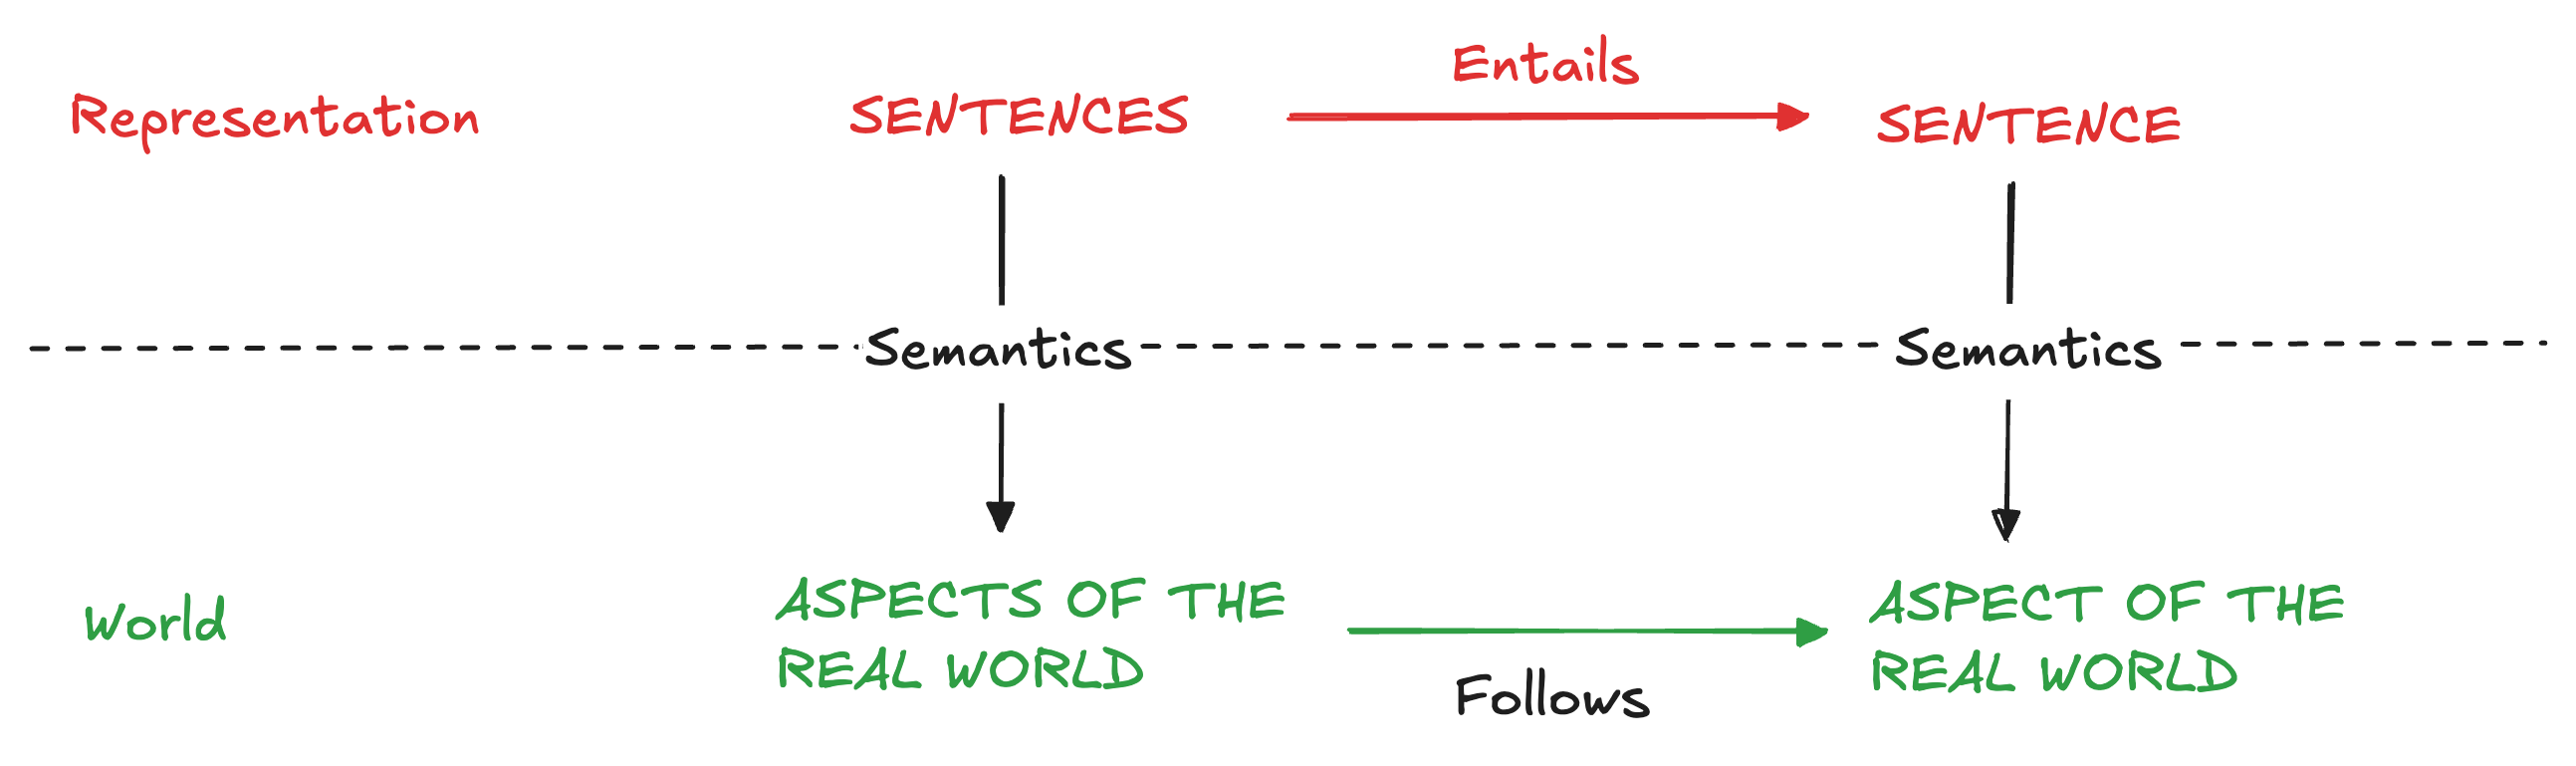

In practice, grounding is achieved through the **agent’s sensors**, which serve as the **interface** between the agent and its environment. **Percepts** generated by sensors (such as detecting light, temperature, or other signals) are translated into **logical sentences** and added to the KB. These sentences are treated as true because they originate from **trusted perceptual mechanisms**. In this way, the truth and meaning of perceptual knowledge are directly tied to the processes that generate it.

Beyond direct perception, agents also rely on **abstract knowledge**, such as rules, regularities, or causal relationships. These are not based on immediate sensory input but are often generalizations formed through **learning**. For example, the rule that certain conditions imply a specific outcome may be inferred from experience rather than directly observed. Although such learned knowledge may be imperfect, effective learning algorithms can ensure that the knowledge base remains well aligned with the structure of the world, allowing the agent to reason and act adaptively.

## The Wumpus World

The Wumpus World is a **classic environment** used to illustrate the capabilities of knowledge-based agents. It consists of a grid-like cave composed of interconnected rooms. Somewhere in the cave lurks the Wumpus, a dangerous creature that will devour any agent entering its room. The agent has a single arrow and one opportunity to eliminate the Wumpus. In addition to this threat, some rooms contain bottomless pits that instantly trap and kill the agent. The only reward in this perilous setting is the possibility of discovering a pile of gold hidden in one of the rooms. To survive and succeed, the agent must explore the cave while avoiding dangers and seeking the gold. It relies on perceptual input from sensors that provide indirect clues about adjacent rooms. For example, detecting a stench near the Wumpus, a breeze near a pit, or a glitter near the gold. The agent uses these percepts to update its knowledge base and make decisions through logical inference.

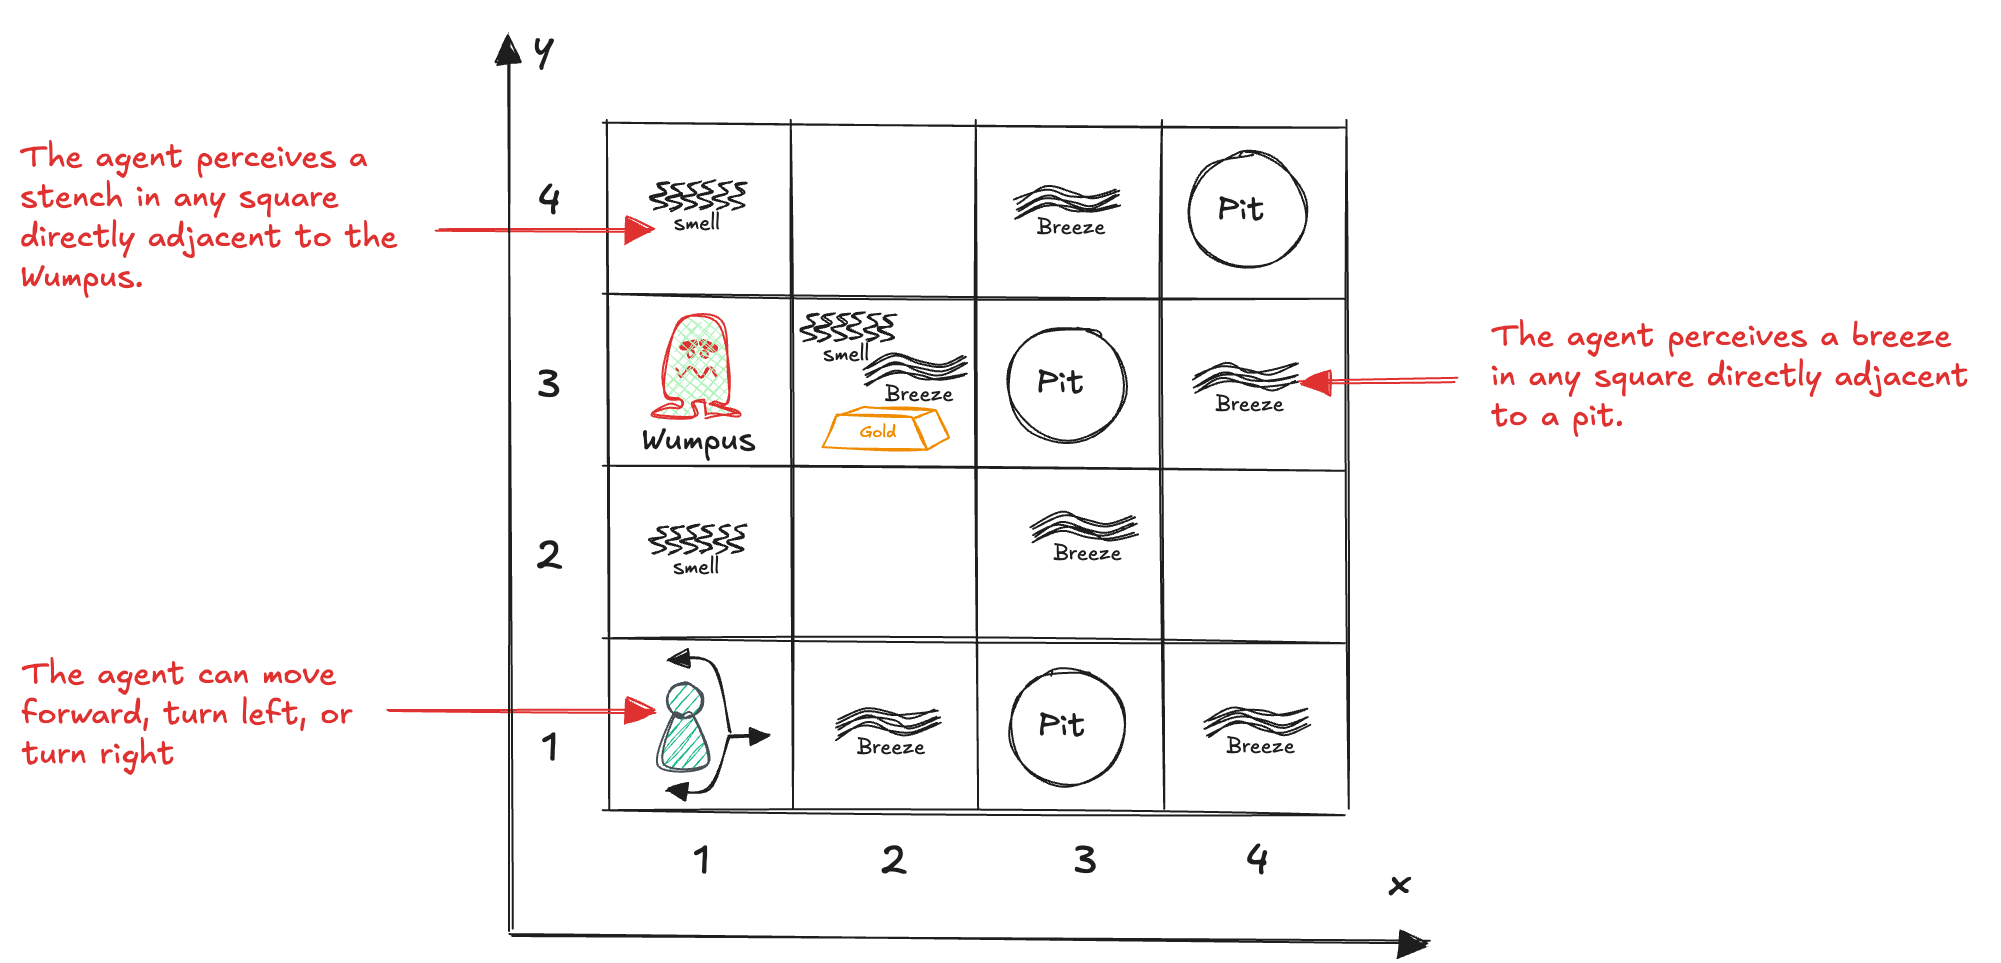

The Wumpus World is a **deterministic**, **discrete**, **static**, and **single-agent** environment. It is also **sequential**, as achieving goals requires a series of deliberate actions. The world is **partially observable**: key aspects of the environment, like the locations of pits and the Wumpus, cannot be directly perceived but must be inferred from indirect percepts. The primary challenge for the agent is its **initial ignorance** about the world’s configuration. To navigate safely and effectively, the agent must rely on logical reasoning to interpret limited sensory information and build a coherent internal model. At every step, the agent must weigh the risk of death against the potential reward of success, deciding whether to retreat to safety or press forward in pursuit of the gold.

Let us follow the agent as it explores the environment, using an informal symbolic representation in which information is annotated directly onto the grid:

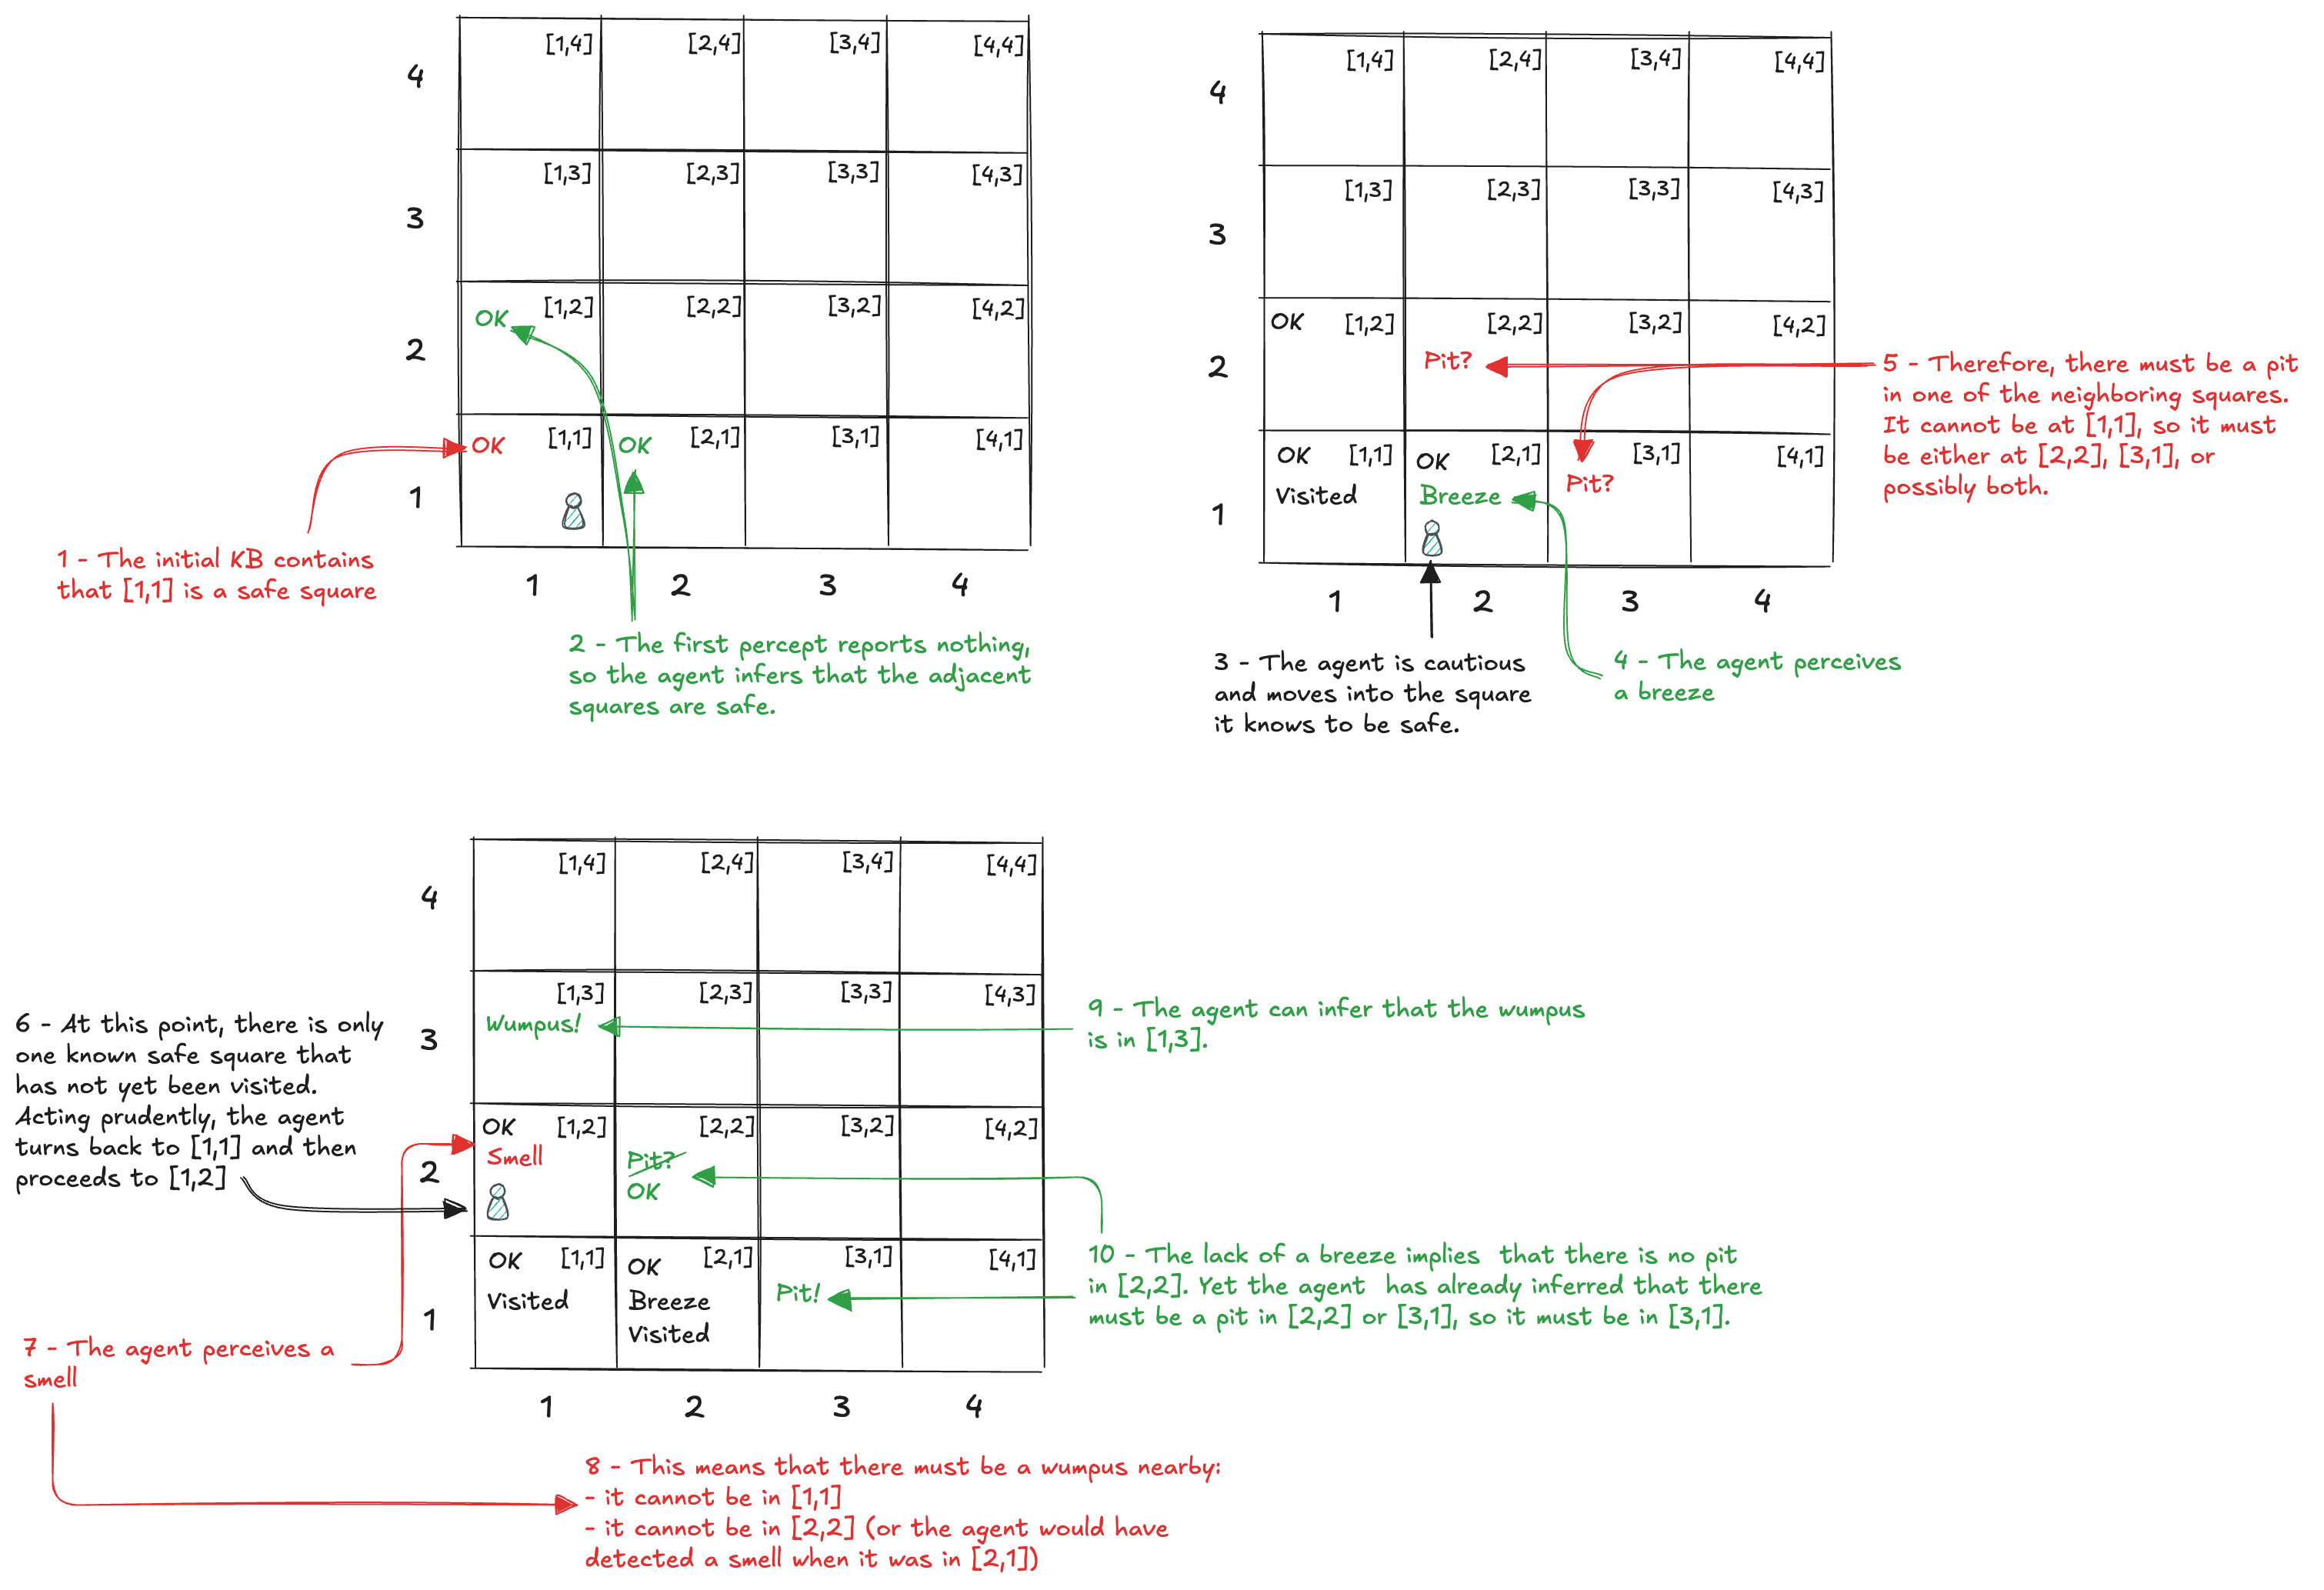

Notice that the final inference is particularly challenging, as it requires **integrating knowledge acquired at different times and locations**, and depends on the **absence of a specific percept**. Yet, whenever the agent draws a conclusion from its available information, that conclusion is guaranteed to be correct, as long as the initial information is accurate. This **reliability** is a defining strength of logical reasoning.

We can analyze this reasoning using logic. After the agent’s first action, its knowledge base can be understood either as a set of individual sentences or as a single sentence formed by their conjunction. The KB rules out any model that contradicts what the agent has perceived, it is false in every model that violates any of the known facts:

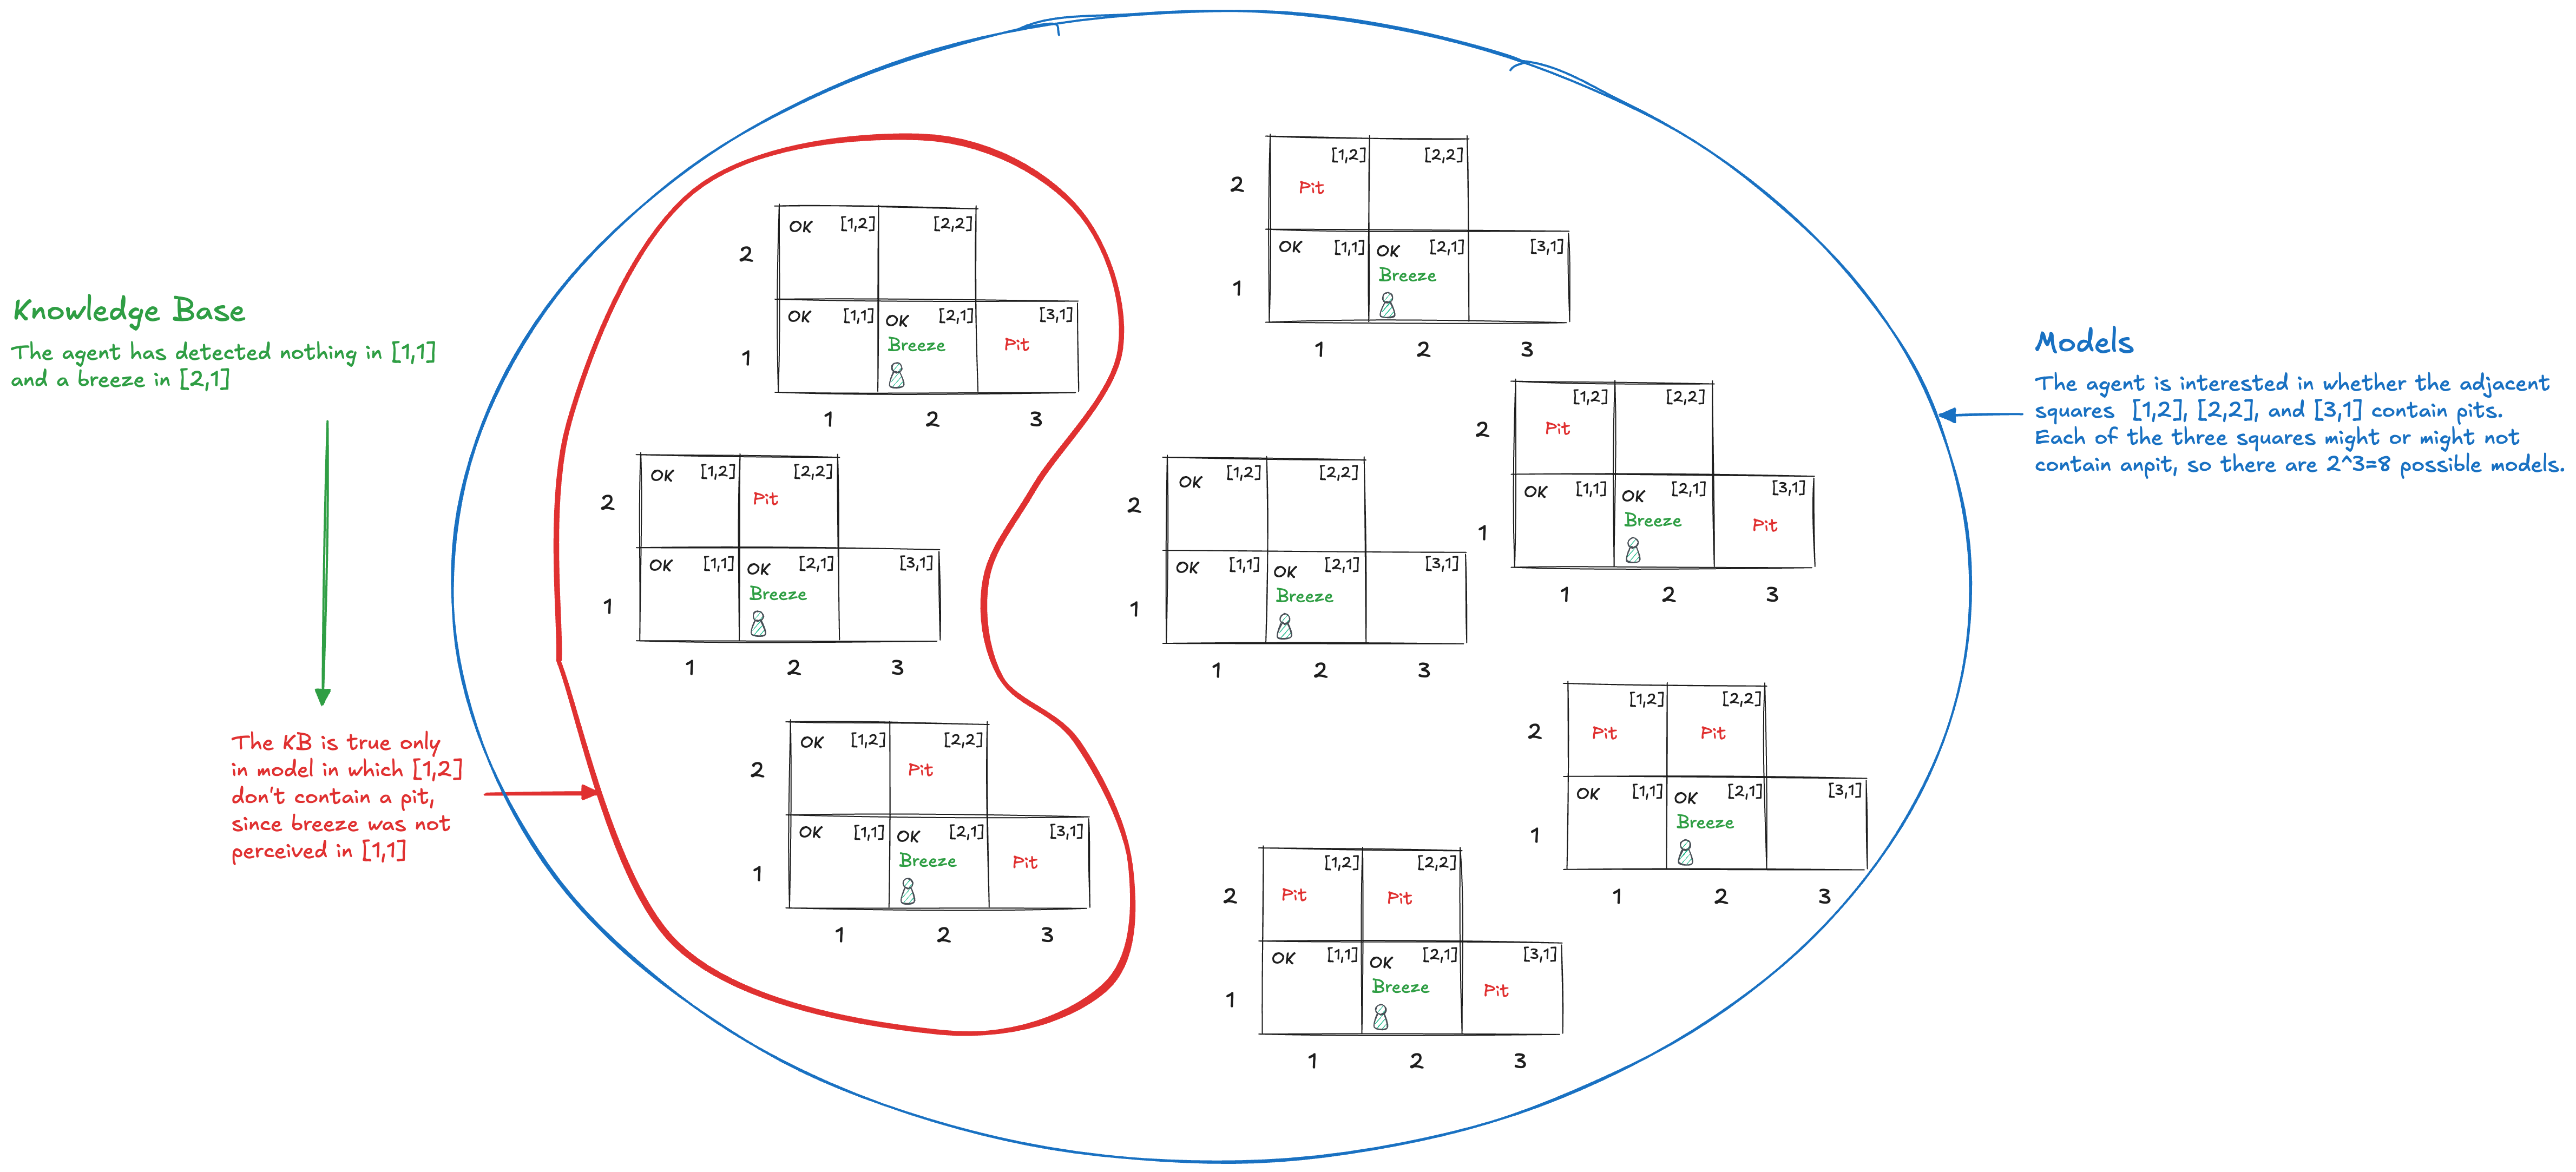

Now consider two possible new assertions: 

- A1: “There is a pit in [1,2]” 

- A2: “There is a pit in [2,2]”.

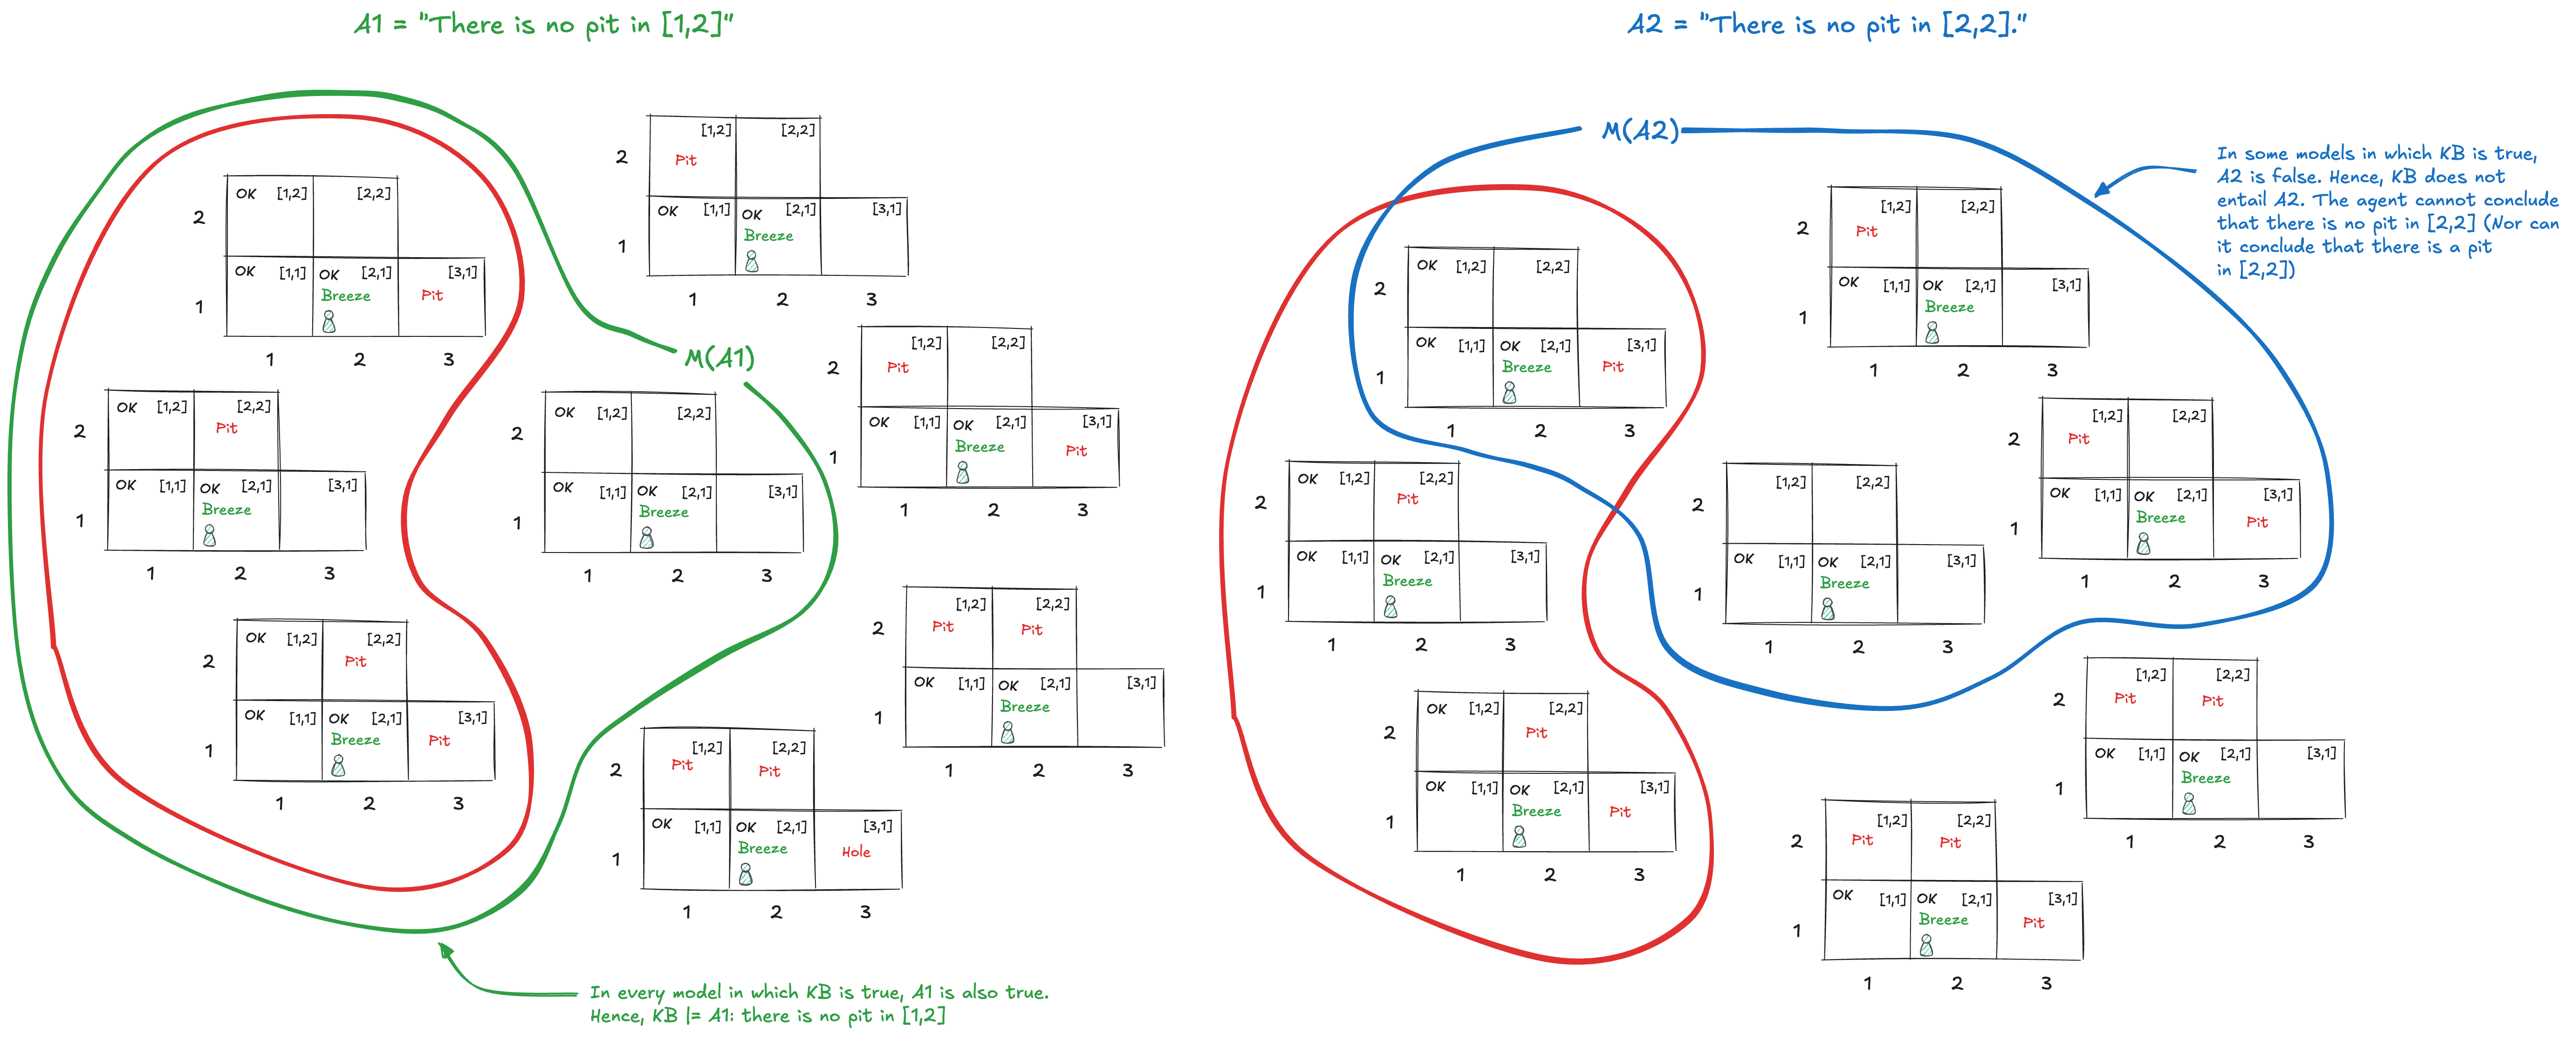

Some sentences are **logically entailed** by the knowledge base, while others are not. The first sentence is entailed because it holds **true in every model** consistent with the KB. The second sentence is not entailed, as it is **false in at least one model** where the KB is true.

## Propositional Logic

The simplest and most foundational form of logic is the **propositional logic**. While **limited in expressive power**, it serves as the basis for more advanced logical systems. We will first introduce its syntax, which defines how well-formed sentences are constructed, followed by its semantics, which determines the truth of those sentences relative to a given interpretation.

### Syntax

The **atomic sentences** consist of a single symbol (A, B, C) that can be true or false. **Complex sentences** are constructed from simpler sentences, using parentheses and **logical connectives** operators:

- **Negation** ($\lnot$, not): The sentence $\lnot$ A is the negation of A. It is true when A is false, and false when A is true
- **Conjunction** ($\land$, and): The sentence A $\land$ B is a conjunction, meaning both A and B must be true. A and B are called the conjuncts.
- **Disjunction** ($\lor$, or): The sentence A $\lor$ B is a disjunction, meaning at least one of A or B must be true. A and B are called the disjuncts.
- **Implication** ($\Rightarrow$, implies): The sentence A $\Rightarrow$** B is an implication, also known as a conditional or an if–then statement. A is the premise (or antecedent), and B is the conclusion (or consequent). It is false only when A is true and B is false.
- **Biconditional** ($\Leftrightarrow$, if and only if): The sentence A $\Leftrightarrow$ B is a biconditional, meaning A is true if and only if B is true. It expresses that A and B always share the same truth value.
  
To formally specify which expressions are valid in propositional logic, we define a **grammar**, a precise set of rules that determines how well-formed sentences can be constructed. This grammar describes the syntactic structure of the language, outlining how symbols can be combined to produce meaningful expressions. We use the **Backus–Naur Form (BNF)**, a widely used notation for defining the syntax of formal languages. In BNF, production rules specify how complex sentences are built from simpler elements. This provides a structured and rigorous way to describe the complete set of syntactically valid sentences in propositional logic:

- Sentence -> AtomicSentence | ComplexSentence   
- AtomicSentence -> True | False | A | B | C | … 
- ComplexSentence -> 
    - $\lnot$ Sentence  
    - | Sentence $\land$ Sentence   
    - | Sentence $\lor$ Sentence    
    - | Sentence $\Rightarrow$ Sentence 
    - | Sentence $\Leftrightarrow$ Sentence 
- Operator precedence (from highest to lowest): 
    - $\lnot$,  
    - $\land$,  
    - $\lor$,   
    - $\Rightarrow$,    
    - $\Leftrightarrow$ 

We can implement sentences in propositional logic as a **tree structure**, where **each node represents a logical operator** and its **children represent the operands**. This tree structure captures the hierarchical relationships between operators and operands. For example, the sentence:

$\displaystyle \lnot (A \land B) \Rightarrow (\lnot C \lor \lnot D)$

can be represented as follows:

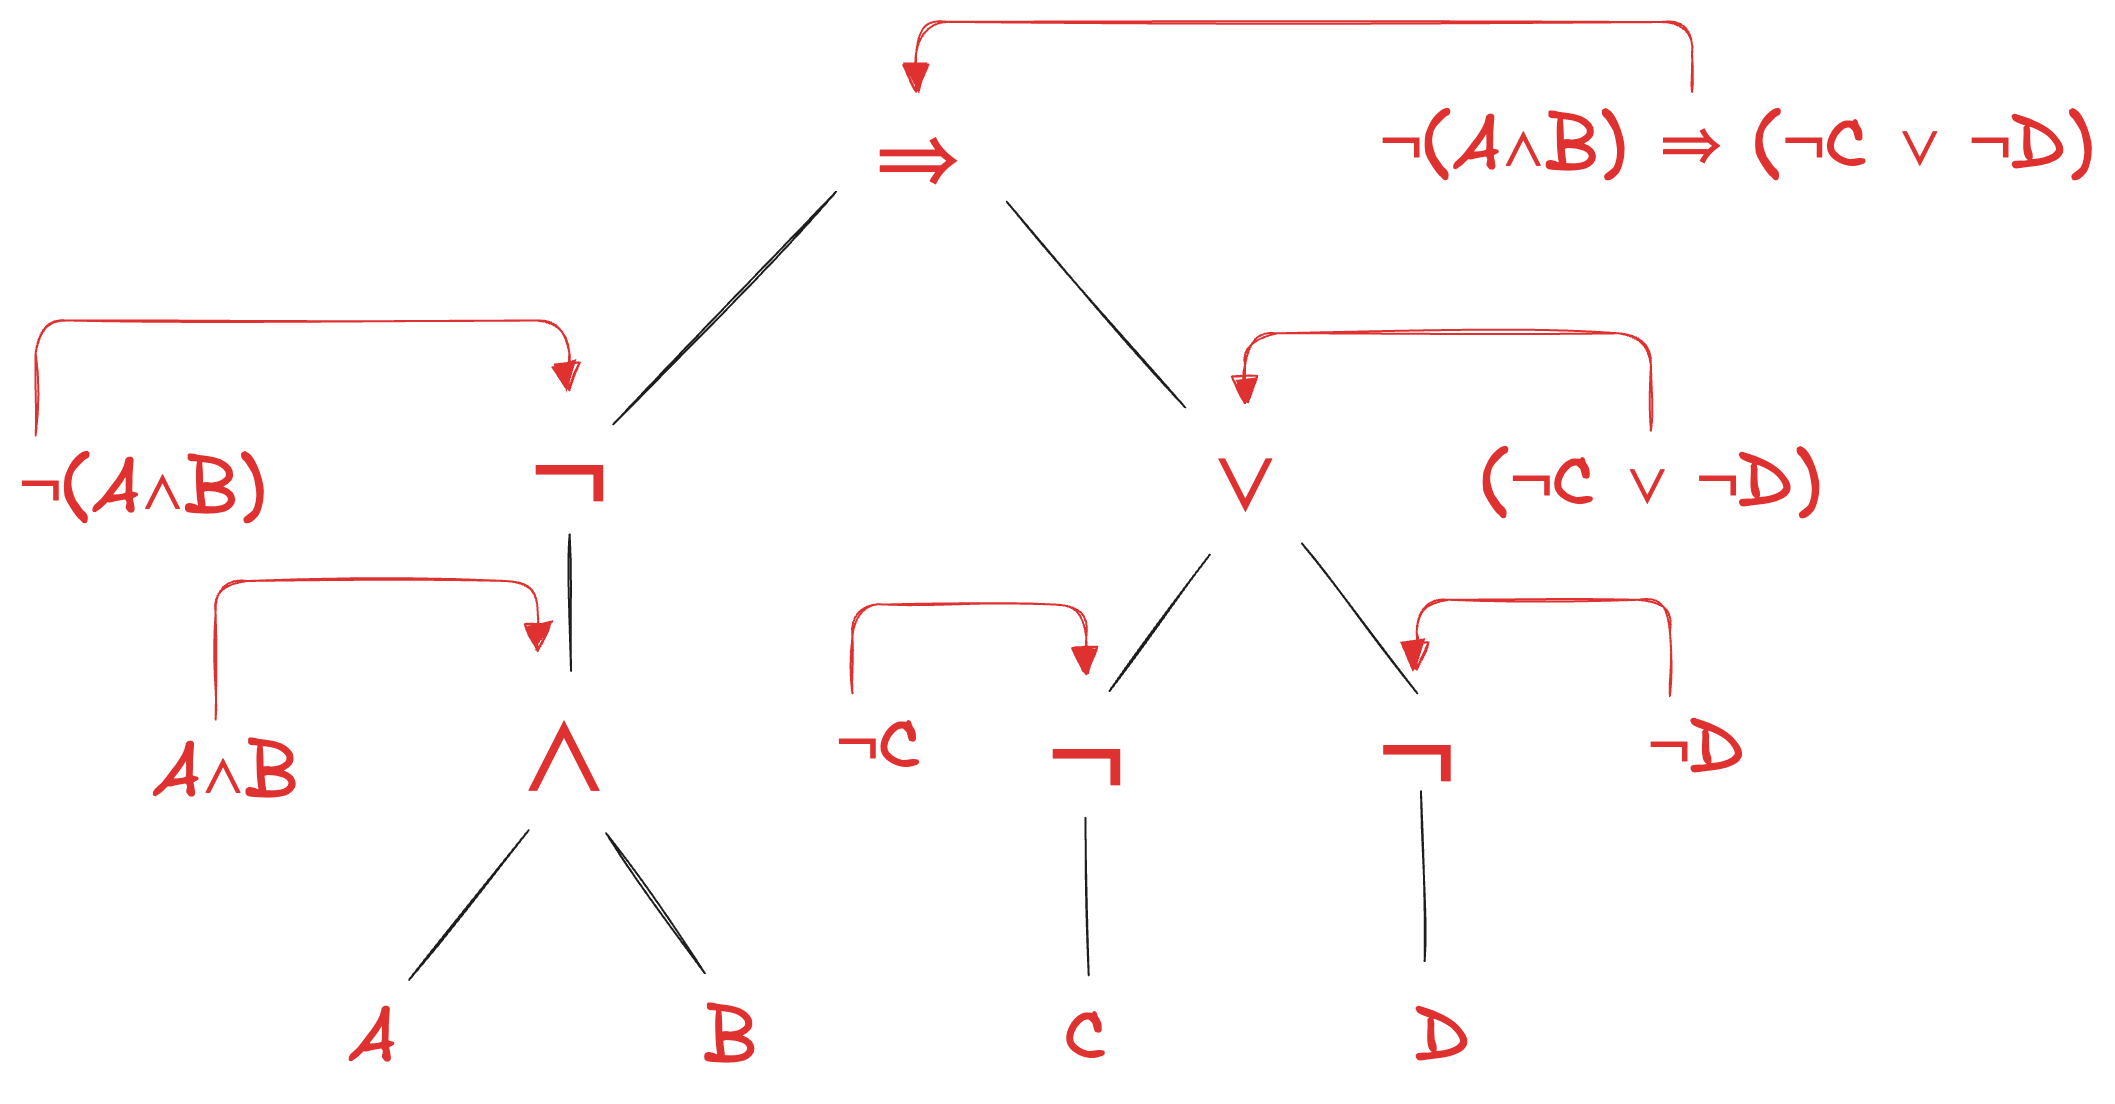

We can implement a class Expr to represent the expressions in propositional logic, where each expression is either an atomic sentence or a complex sentence formed by combining other expressions with logical operators:

In [502]:
class PL_Expr:
    def __init__(self, op, *args):
        # Initialize an expression with an operator and its arguments
        self.op = op
        self.args = args

    # String representation of the expression
    def __repr__(self):
        
        # NOT
        if self.op == 'NOT': 
            return f"¬{self.args[0]}"
        
        # AND
        elif self.op == 'AND': 
            return f"({f' & '.join(map(str, self.args))})"
        
        # OR
        elif self.op == 'OR': 
            return f"({f' | '.join(map(str, self.args))})"

        # IMPLIES
        elif self.op == 'IMPLIES':
            return f"({self.args[0]} -> {self.args[1]})" 

        # BICONDITIONAL
        elif self.op == 'IFF': 
            return f"({self.args[0]} <-> {self.args[1]})"
        
        # Atomic symbol
        else: 
            return self.op  
    
    # Hash method for using Expr in sets or as dictionary keys
    def __hash__(self):
        return hash((self.op, self.args))

    # Check if the expression is atomic (no arguments)
    def is_atomic(self):
        return not self.args

    # Check if the expression is a literal (atomic or negation of an atomic)
    def is_literal(self):
        return self.is_atomic() or (self.op == 'NOT' and self.args[0].is_atomic())

    # Overloading operator & for logical and expression
    def __and__(self, other):
        if self.op == 'AND':
            if other.op == 'AND':
                return PL_Expr('AND', *(self.args + other.args))
            else:
                return PL_Expr('AND', *(self.args + (other,)))
        else:
            if other.op == 'AND':
                return PL_Expr('AND', *(other.args + (self,)))
            else:
                return PL_Expr('AND', self, other)

    # Overloading operator | for logical or expression
    def __or__(self, other):
        if self.op == 'OR':
            if other.op == 'OR':
                return PL_Expr('OR', *(self.args + other.args))
            else:
                return PL_Expr('OR', *(self.args + (other,)))
        else:
            if other.op == 'OR':
                return PL_Expr('OR', *(other.args + (self,)))
            else:
                return PL_Expr('OR', self, other)

    # Overloading operator ~ for logical negation expression
    def __invert__(self): 
        return PL_Expr('NOT', self)
    
    # Overloading operator >> for logical implication expression
    def __rshift__(self, other):
        return PL_Expr('IMPLIES', self, other)
    
    # Overloading operator == for biconditional expression 
    def __eq__(self, other):
        return PL_Expr('IFF', self, other)

For example, we can write some sentences and check their correctness:

In [503]:
# Some atomic expressions
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')

# A AND B
sentence1 = A & B
print(sentence1)

# ¬A
sentence2 = ~A
print(sentence2)

# (A AND B) -> C
sentence3 = (A & B) >> (C)
print(sentence3)

# A <-> B
sentence4 = A == B
print(sentence4)

(A & B)
¬A
((A & B) -> C)
(A <-> B)


### Semantics

The semantics defines how the truth of a sentence is determined relative to a model. A model is a **complete assignment of truth values (true or false) to each atomic proposition symbol**. For example, if the sentences in the knowledge base make use of the proposition symbols: 

$\displaystyle A, B, C$ 

then one possible model is:

$\displaystyle m = \{A = \text{false}, B = \text{false}, C = \text{true}\}$

A model can be represented using a dictionary, where the keys are the proposition symbols and the values are their truth values:

In [504]:
model = {
    A: False,
    B: False,
    C: True
}

With three proposition symbols, there are 2^3=8 possible models, which can be enumerated. Notice that the models are **purely mathematical objects** with no necessary connection to a real worlds. A is just a symbol, it might mean "there is a pit in [1,2]" or "I’m in Paris today and tomorrow". Once a model is given, the truth of more complex sentences is evaluated recursively based on the meanings of the logical connectives:

- $\lnot$ A is true if and only if A is false
- A $\land$ B is true if and only if both A and B are true
- A $\lor$ B is true if and only if either A or B is true
- A $\Rightarrow$ B is true unless A is true and B is false
- A $\Leftrightarrow$ B is true if and only if A and B are both true or both false

The rules can be expressed with **truth tables** that specify the truth value of a complex sentence for each possible assignment of truth values to its components:

| A     | B     | $\lnot$ A    | A $\land$ B | A $\lor$ B | A $\Rightarrow$ B | A $\Leftrightarrow$ B |
|-------|-------|-------|-------|-------|-------|-------|
| false | false | true  | false | false | true  | true  |
| false | true  | true  | false | true  | true  | false |
| true  | false | false | false | true  | false | false |
| true  | true  | false | true  | true  | true  | true  |

From these tables, the truth value of a sentence can be computed with respect to a model by a simple recursive evaluation. For example, the sentence:

$\displaystyle \lnot A \lor (B \land C)$ 

evaluated in the model $m$, gives: 

$\displaystyle \text{true} \land (\text{false} \lor \text{true}) = \text{true} \land \text{true} = \text{true}$

The truth table entries for "and", "or", and "not" closely match intuition. Instead, the truth table for "implies" may not fit intuitive understanding. For one thing, propositional logic **does not require any relation of causation** between the two sentence. The sentence "5 is odd implies Tokyo is the capital of Japan" is a true sentence, even though it is bizarre. Another point of confusion is that **any implication is true whenever its antecedent is false**. For example, "5 is even implies Sam is smart" is true, regardless of whether Sam is smart. This seems strange, but it makes sense if we think of "A ⇒ B" as "if A is true, then I am claiming that B is true; otherwise I am making no claim". The only way for this sentence to be false is if A is true but B is false. The biconditional is true whenever both implies are true.

We can write an evaluate method to check the truth of a sentence in a model, where the model is a dictionary of symbols and their truth values. The method will recursively evaluate the sentence based on the logical connectives and the model provided:

In [505]:
def PL_evaluate(expr, model):

    # Handle base cases for evaluation
    if expr.op == "TRUE": return True
    if expr.op == "FALSE":return False
    if expr.is_atomic(): return model[expr]

    # Extract the arguments of the expression
    args = expr.args

    # Handle not operator: 
    # evaluate the argument and negate the result
    if expr.op == "NOT":
        return not PL_evaluate(args[0], model)
    
    # Handle the and operator:
    # evaluate all arguments and return True if all are True
    elif expr.op == "AND":
        return all(PL_evaluate(arg, model) for arg in args)
    
    # Handle the or operator:
    # evaluate all arguments and return True if at least one is True
    elif expr.op == "OR":
        return any(PL_evaluate(arg, model) for arg in args)
    
    # Handle implication operator:
    # evaluate the first argument, if False return True, 
    # else evaluate the second argument
    elif expr.op == "IMPLIES":
        return (not PL_evaluate(args[0], model)) or PL_evaluate(args[1], model)
    
    # Handle biconditional operator:
    # evaluate both arguments and return True if they are equal
    elif expr.op == "IFF":
        return PL_evaluate(args[0], model) == PL_evaluate(args[1], model)
    
    # Handle unknown operator:
    raise ValueError(f"Unknown operator: {expr.op}")

We can evaluate the example sentence in the given model:

In [506]:
sentence = ~A | (B & C)
result = PL_evaluate(sentence, model)
print(f"Evaluation of {sentence} with model {model} is {result}")

Evaluation of (¬A | (B & C)) with model {A: False, B: False, C: True} is True


We can write a function to **calculate the truth table** for a sentence, which is the evaluatoin of the sentence in all possible models. First of all we need a function to extract all the symbols from the sentence. We can do this by recursively traversing the sentence and collecting all the symbols: 

In [507]:
def get_symbols(sentence):

    # Create a set to hold the symbols
    symbols = set()
    
    # If the expression is atomic, add it to the set
    if sentence.is_atomic():
        symbols.add(sentence)
    
    # Else recursively get symbols from the arguments
    else:
        for arg in sentence.args:
            symbols.update(get_symbols(arg))
    
    # Return the set of symbols
    return symbols

Then we can generate all possible models by creating all combinations of truth values for the symbols. Finally, we can evaluate the sentence in each model and print the results in a table format:

In [508]:
import itertools

def PL_truth_table(sentence):

    # Extract all symbols from the expression
    symbols = sorted(get_symbols(sentence), key=lambda x: x.op)

    # Get the headers for the truth table
    headers = [s.op for s in symbols] + [str(sentence)]

    # Determine the width of each column
    col_widths = [max(len(h), 5) for h in headers]

    # Function to format a row of the truth table
    def format_row(values):
        return " | ".join(str(val).ljust(width) for val, width in zip(values, col_widths))

    # Print header
    print(format_row(headers))
    print("-" * (sum(col_widths) + 3 * (len(col_widths) - 1)))

    # Print rows
    for vals in itertools.product([False, True], repeat=len(symbols)):
        model = dict(zip(symbols, vals))
        result = PL_evaluate(sentence, model)
        row = list(vals) + [result]
        print(format_row(row))

We can make and example of the truth table for a simple sentence:

In [ ]:
# Define atomic propositions
P = PL_Expr('P')
Q = PL_Expr('Q')
R = PL_Expr('R')

# Example formula: (P ∧ ¬Q) -> R
formula = (P & ~Q) >> R

# Print the truth table
PL_truth_table(formula)

P     | Q     | R     | ((P & ¬Q) -> R)
---------------------------------------
False | False | False | True           
False | False | True  | True           
False | True  | False | True           
False | True  | True  | True           
True  | False | False | False          
True  | False | True  | True           
True  | True  | False | True           
True  | True  | True  | True           


### Equivalence, validity and satisfiability

In propositional logic, we can define several important relationships between sentences. The first is **logical equivalence**. Two sentences are logically equivalent if **they are true in the same set of models**, alternativelly we can say that the two sentences are equivalent **if and only if each of them entails the other**:

$\displaystyle A \equiv B \; \Leftrightarrow \;  A \models B, \; B \models A$

For example, we can easily show (using truth tables) that A∧B and B∧A are logically equivalent: 

In [510]:
# Define atomic propositions
A = PL_Expr("A")
B = PL_Expr("B")

# First sentence: A AND B
A_AND_B = A & B

# Second sentence: B AND A
B_AND_A = B & A

# Check equivalence from the truth tables
print("A AND B:")
PL_truth_table(A_AND_B)

print("\nB AND A:")
PL_truth_table(B_AND_A)

A AND B:
A     | B     | (A & B)
-----------------------
False | False | False  
False | True  | False  
True  | False | False  
True  | True  | True   

B AND A:
A     | B     | (B & A)
-----------------------
False | False | False  
False | True  | False  
True  | False | False  
True  | True  | True   


Other equivalences are: 

- $(A \land B) \equiv (B \land A)$ **commutativity** of $\land$   
- $(A \lor B) \equiv (B \lor A)$ **commutativity** of $\lor$  
- $((A \land B) \land C) \equiv (A \land (B \land C))$ **associativity** of $\land$    
- $((A \lor B) \lor C) \equiv (A \lor (B \lor C))$ **associativity** of $\lor$  
- $\lnot (\lnot A) \equiv A$ **double-negation elimination**  
- $(A \Rightarrow B) \equiv (\lnot B \Rightarrow \lnot A)$ **contraposition**  
- $(A \Rightarrow B) \equiv (\lnot A \lor B)$ **implication elimination**  
- $(A \Leftrightarrow B) \equiv ((A \Rightarrow B) \land (B \Rightarrow A))$ **biconditional elimination**    
- $\lnot (A \lor B) \equiv (\lnot A \land \lnot B)$ **De Morgan's law**   
- $\lnot (A \land B) \equiv (\lnot A \lor \lnot B)$ **De Morgan's law**   
- $(A \lor (B \land C)) \equiv ((A \lor B) \land (A \lor C))$ **distributivity** of $\lor$ over $\land$   
- $(A \land (B \lor C)) \equiv ((A \land B) \lor (A \land C))$ **distributivity** of $\land$ over - $\lor$  

All those equivalences can be proven using the truth table method, by evaluating both sides of each equivalence under all possible truth assignments and verifying that they yield identical truth values in every case. They play the same role in logic as arithmetic identities do in ordinary mathematics.

The second concept is **validity**. A sentence is valid if it is **true in all models**. For example, the sentence (A $\lor$ $\lnot$ A) is valid. Valid sentences are also known as **tautologies**, they are necessarily true. We can wrote a method to check if a sentence is valid by checking if it is true in all models:

In [511]:
def is_valid(sentence):

    # Extract symbols from the sentence
    symbols = get_symbols(sentence)

    # Generate all combinations of truth assignments for the symbols
    for values in itertools.product([False, True], repeat=len(symbols)):
        
        # Create a model mapping symbols to their truth values
        model = dict(zip(symbols, values))

        # If the sentence evaluates to False in any model, it is not valid
        if not PL_evaluate(sentence, model):
            return False  
        
    # If the sentence is True for all models, it is valid
    return True

We can check the validity of a simple tautology, like (A $\lor$ $\lnot$ A):

In [512]:
# Define atomic proposition
A = PL_Expr("A")

# Construct the tautology: A OR (NOT A)
tautology = A | ~A

# Check validity
is_tautology_valid = is_valid(tautology)
print(f"The tautology {tautology} is valid: {is_tautology_valid}")

The tautology (A | ¬A) is valid: True


A sligtly more complex tautology is the **transitivity of implication**: if A implies B, and B implies C, then A must imply C. It is true under all possible truth assignments for A, B, and C, which makes it a tautology:

$\displaystyle \left((A \Rightarrow B) \land (B \Rightarrow C)\right) \Rightarrow (A \Rightarrow C)$

In [513]:
# Define atomic propositions
A = PL_Expr("A")
B = PL_Expr("B")
C = PL_Expr("C")

# Build the formula
implication_transitivity = ((A >> B) & (B >> C)) >> (A >> C)

# Check validity
is_implication_transitivity_valid = is_valid(implication_transitivity)
print(f"The formula {implication_transitivity} is valid: {is_implication_transitivity_valid}")

The formula (((A -> B) & (B -> C)) -> (A -> C)) is valid: True


The final concept is **satisfiability**. A sentence is satisfiable **if it is true in, or satisfied by, some model**. Satisfiability can be checked by enumerating the possible models until one is found that satisfies the sentence. 

In [514]:
def is_satisfiable(sentence):

    # Extract symbols from the sentence
    symbols = get_symbols(sentence)

    # Generate all combinations of truth assignments for the symbols
    for values in itertools.product([False, True], repeat=len(symbols)):

        # Create a model mapping symbols to their truth values
        model = dict(zip(symbols, values))

        # If the sentence evaluates to True in any model, it is satisfiable
        if PL_evaluate(sentence, model):
            return True 
        
    # If no model makes the sentence true, it is not satisfiable
    return False 

For example, the sentence (A $\lor$ B) is satisfiable because it is true in the models where A is true, or B is true, or both. In contrast, the sentence (A $\land$ $\lnot$ A) is unsatisfiable because there is no model where it can be true:

In [515]:
A = PL_Expr("A")
B = PL_Expr("B")

# Satisfiable example: A OR B
satisfiable_expr = A | B
is_satisfiable_result = is_satisfiable(satisfiable_expr)
print(f"The expression {satisfiable_expr} is satisfiable: {is_satisfiable_result}")

# Unsatisfiable example: A AND ¬A
unsatisfiable_expr = A & ~A
is_unsatisfiable_result = is_satisfiable(unsatisfiable_expr)
print(f"The expression {unsatisfiable_expr} is satisfiable: {is_unsatisfiable_result}")

The expression (A | B) is satisfiable: True
The expression (A & ¬A) is satisfiable: False


The problem of determining the satisfiability of sentences (**SAT problem**) was the first problem proved to be **NP-complete**. Many problems can be reduced to SAT, making it a central problem in computer science. For example, all the constraint satisfaction problems ask whether the constraints are satisfiable by some assignment.

### Deduction theorem

Considering the concepts of entailment, validity, and satisfiability, we can derive a powerful result known as the **deduction theorem**. This theorem connects the notions of entailment and validity in a profound way. Because a valid sentence is true in all models, **every valid sentence is equivalent to True**. From the definition of entailment, we can derive:  

*For any sentences A and B, (A $\models$ B) if and only if the sentence (A $\Rightarrow$ B) is valid*

We can determine whether A entails B by checking if the implication A $\Rightarrow$ B is true in every model. This is equivalent to **proving that the sentence A $\Rightarrow$ B is valid** (i.e., true in all possible worlds or models). Conversely, the deduction theorem states that if the implication A $\Rightarrow$ B is valid (i.e., true in all models), then B can be inferred from A; in other words, A $\models$ B.

A classic example can help illustrate and confirm the deduction theorem. Suppose we know that A is true and that A $\Rightarrow$ B holds (these are our **premises**). Then, according to the deduction theorem, we can deduce that B must also be true (**deduction**):

In [ ]:
# Define atomic propositions
A = PL_Expr("A")
B = PL_Expr("B")

# Premise: A ∧ (A -> B)
premise = A & (A >> B)

# Deduction: (A ∧ (A -> B)) -> B
deduction = premise >> B

# Check validity of the deduction
validity = is_valid(deduction)

# Show result
print("\nDeduction Theorem Test:")
print("Formula:", deduction)
print("Is it valid?", validity)


Deduction Theorem Test:
Formula: ((A & (A -> B)) -> B)
Is it valid? True


### Reductio ad absurdum

Validity and satisfiability are connected also in another fundamental way: a sentence is valid if it is true in every possible model, this is equivalent to saying that its negation is unsatisfiable (no model can make it true); conversely, if the negation is not valid (exists at least one model where it is false), then the sentence must be satisfiable (true in at least one model). This connection leads to a powerful logical reasoning tool, called the **reductio ad absurdum** (or proof by contradiction):

$\displaystyle A \models B \quad \Leftrightarrow \quad A \land \lnot B$ is unsatisfiable

So, to prove: 

A $\models$ B

we assume both the premise and the negation of the conclusion. If this combination leads to a **contradiction** (there is no model where both are true) then we’ve shown the original sentence. 

We can use this method to prove a classic statement, the **disjunction elimination rule**: if either A or B is true (disjunction), and we know A is not true, then B must be true:

$\displaystyle (A \lor B) \land \lnot A \models B$

In [517]:
# Define atomic propositions
A = PL_Expr("A")
B = PL_Expr("B")

# Step 1: Premises
premises = (A | B) & ~A

# Step 2: Assume ¬B (Reductio ad Absurdum)
assumption = ~B

# Step 3: Combine: (A ∨ B) ∧ ¬A ∧ ¬B
conjunction = premises & assumption

# Step 4: Check if it is satisfiable
satisfiable = is_satisfiable(conjunction)

# Show result
print("\nReductio ad Absurdum — Disjunction Elimination:")
print("Assumed formula:", conjunction)
print("Is it satisfiable?", satisfiable)
print("Therefore, B must be true:", not satisfiable)


Reductio ad Absurdum — Disjunction Elimination:
Assumed formula: ((A | B) & ¬A & ¬B)
Is it satisfiable? False
Therefore, B must be true: True


This method lies at the heart of many mathematical and logical proofs: we rule out all alternatives by showing they lead to inconsistency, leaving the original claim as the only possibility.

### Conjunctive Normal Form (CNF)

A central concept in propositional logic is the **Conjunctive Normal Form (CNF)**, where every sentence is rewritten as **a conjunction of clauses**. A **clause** is a **disjunction of literals**. CNF provides a standardized structure that is especially well-suited for automated reasoning techniques, which operate by manipulating clauses directly. in order to convert a sentence into CNF, we follow a series of steps:

**(1) Eliminate biconditionals**: 

$\displaystyle A \Leftrightarrow B \equiv (A \Rightarrow B) \land (B \Rightarrow A)$

In [518]:
def eliminate_iff(sentence):

    # Base case: atomic expressions (no subexpressions)
    if sentence.is_atomic():
        return sentence

    # Recursively process arguments
    new_args = tuple(eliminate_iff(arg) for arg in sentence.args)

    # Handle the biconditional operator
    if sentence.op == 'IFF':
        A, B = new_args
        return (A >> B) & (B >> A)

    # Handle other operators
    else:
        return PL_Expr(sentence.op, *new_args)

In [525]:
# Atomic propositions
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')

# Example 1 (A == B is equivalent to (A >> B) & (B >> A))
sentence = A == B
result = eliminate_iff(sentence)
print(sentence, " becomes ", result)

# Example 2 (A == (B | C) is equivalent to (A >> (B | C)) & ((B | C) >> A))
sentence = A == (B | C)
result = eliminate_iff(sentence)
print(sentence, " becomes ", result)

# Example 3 ((A & B) == C is equivalent to ((A & B) >> C) & (C >> (A & B)))
sentence = (A & B) == C
result = eliminate_iff(sentence)
print(sentence, " becomes ", result)

(A <-> B)  becomes  ((A -> B) & (B -> A))
(A <-> (B | C))  becomes  ((A -> (B | C)) & ((B | C) -> A))
((A & B) <-> C)  becomes  (((A & B) -> C) & (C -> (A & B)))


**(2) Eliminate implications**:

$\displaystyle A \Rightarrow B \equiv \lnot A \lor B$

In [526]:
def eliminate_implies(sentence):

    # Base case: atomic expressions (no subexpressions)
    if sentence.is_atomic():
        return sentence

    # Recursively process arguments
    new_args = tuple(eliminate_implies(arg) for arg in sentence.args)

    # Handle the implication operator
    if sentence.op == 'IMPLIES':
        A, B = new_args
        return ~A | B

    # Handle other operators
    else:
        return PL_Expr(sentence.op, *new_args)

In [527]:
# Atomic propositions
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')

# Example 1 (A >> B is equivalent to ~A | B)
sentence = A >> B
result = eliminate_implies(sentence)
print(sentence, " becomes ", result)

# Example 2 (A & (B >> C) is equivalent to A & (~B | C))
sentence = A & (B >> C)
result = eliminate_implies(sentence)
print(sentence, " becomes ", result)

# Example 3: ((A >> B) >> C) is equivalent to ~(~A | B) | C
sentence = (A >> B) >> C
result = eliminate_implies(sentence)
print(sentence, " becomes ", result)

(A -> B)  becomes  (¬A | B)
(A & (B -> C))  becomes  (A & (¬B | C))
((A -> B) -> C)  becomes  (¬(¬A | B) | C)


**(3) Move negations inward**

$\displaystyle \lnot (\lnot A) \equiv A$    
$\displaystyle \lnot (A \land B) \equiv \lnot A \lor \lnot B$   
$\displaystyle \lnot (A \lor B) \equiv \lnot A \land \lnot B$

In [ ]:
def move_not_inwards(sentence):

    # Base case: atomic expressions (no subexpressions)
    if sentence.is_atomic():
        return sentence

    # Recursively process arguments
    new_args = tuple(move_not_inwards(arg) for arg in sentence.args)

    # Handle the not operator
    if sentence.op == 'NOT':
        inner = new_args[0]

        # Double negation: ¬(¬A) -> A
        if inner.op == 'NOT':
            return move_not_inwards(inner.args[0])

        # De Morgan: ¬(A ∧ B) -> (¬A ∨ ¬B)
        elif inner.op == 'AND':
            return PL_Expr('OR', *[move_not_inwards(~arg) for arg in inner.args])

        # De Morgan: ¬(A ∨ B) -> (¬A ∧ ¬B)
        elif inner.op == 'OR':
            return PL_Expr('AND', *[move_not_inwards(~arg) for arg in inner.args])

        # Leave NOT in place for literals
        else:
            return ~inner

    else:
        return PL_Expr(sentence.op, *new_args)

In [392]:
# Atomic propositions
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')

# Example 1 (¬¬A becomes A)
sentence = ~(~A)
result = move_not_inwards(sentence)
print(sentence, " becomes ", result)

# Example 2 (¬(A & B) becomes (¬A ∨ ¬B))
sentence = ~(A & B)
result = move_not_inwards(sentence)
print(sentence, " becomes ", result)

# Example 3 (¬(A | B) becomes (¬A ∧ ¬B))
sentence = ~(A | B)
result = move_not_inwards(sentence)
print(sentence, " becomes ", result)

# Example 4 (¬(A & (B | C)) becomes (¬A ∨ (¬B ∧ ¬C))
sentence = ~(A & (B | C))
result = move_not_inwards(sentence)
print(sentence, " becomes ", result)

¬¬A  becomes  A
¬(A & B)  becomes  (¬A | ¬B)
¬(A | B)  becomes  (¬A & ¬B)
¬(A & (B | C))  becomes  (¬A | (¬B & ¬C))


**(4) Distribute disjunctions over conjunctions**:

$\displaystyle A \lor (B \land C) \equiv (A \lor B) \land (A \lor C)$

In [535]:
def distribute_or_over_and(sentence):
    if sentence.is_atomic() or sentence.op == 'NOT':
        return sentence

    # Recursively distribute within subexpressions
    args = [distribute_or_over_and(arg) for arg in sentence.args]

    if sentence.op == 'OR':
        # Find all conjunctive arguments (ANDs)
        ands = [arg for arg in args if arg.op == 'AND']
        others = [arg for arg in args if arg.op != 'AND']

        if ands:
            # Pick one AND to distribute over (e.g. first one)
            first_and = ands[0]
            rest = others + [arg for arg in args if arg != first_and]
            return PL_Expr('AND', *[
                distribute_or_over_and(PL_Expr('OR', *(rest + [conj])))
                for conj in first_and.args
            ])
        else:
            return PL_Expr('OR', *args)

    elif sentence.op == 'AND':
        return PL_Expr('AND', *args)

    else:
        return PL_Expr(sentence.op, *args)

In [536]:
# Atomic propositions
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')
D = PL_Expr('D')

# Example 1 (A | (B & C) becomes (A | B) & (A | C))
sentence = A | (B & C)
result = distribute_or_over_and(sentence)
print(sentence, " becomes ", result)

# Example 2 ((A & B) | C becomes (A | C) & (B | C))
sentence = (A & B) | C
result = distribute_or_over_and(sentence)
print(sentence, " becomes ", result)

# Example 3 (A | (B & C) | D becomes (A | B | D) & (A | C | D))
sentence = A | (B & C) | D
result = distribute_or_over_and(sentence)
print(sentence, " becomes ", result)


(A | (B & C))  becomes  ((A | B) & (A | C))
((A & B) | C)  becomes  ((C | A) & (C | B))
(A | (B & C) | D)  becomes  ((A | D | B) & (A | D | C))


**(5) Flatten the conjunctions**:

We add a final (optional) step to flatten the resulting conjunction into a list of clauses, where each clause is a disjunction of literals. This transformation is essential because it produces a standard clausal form, enabling algorithms to operate directly on individual clauses. Without flattening, nested conjunctions or disjunctions would complicate the application of algorithms which assume a CNF structure as a flat set of disjunctive clauses:


In [542]:
def flatten(sentence):

    if sentence.is_atomic() or sentence.op == "NOT":
        return sentence

    # First flatten subexpressions
    flattened_args = [flatten(arg) for arg in sentence.args]

    # If this is AND or OR, merge nested same-operator children
    if sentence.op in {"AND", "OR"}:
        flat = []
        for arg in flattened_args:
            if not arg.is_atomic() and arg.op == sentence.op:
                flat.extend(arg.args)  # Flatten same-op child
            else:
                flat.append(arg)
        return PL_Expr(sentence.op, *flat)

    # For other operators, just return the expression with flattened arguments
    return PL_Expr(sentence.op, *flattened_args)

In [544]:
# Atomic propositions
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')
D = PL_Expr('D')

# Example 1 (A & (B & C) becomes (A & B & C))
sentence = PL_Expr('AND', A, PL_Expr('AND', B, C))
result = flatten(sentence)
print(sentence, " becomes ", result)

# Example 2 (A | (B | C) becomes (A | B | C))
sentence = PL_Expr('OR', A, PL_Expr('OR', B, C))
result = flatten(sentence)
print(sentence, " becomes ", result)

(A & (B & C))  becomes  (A & B & C)
(A | (B | C))  becomes  (A | B | C)


Putting it all together, we can write a function to convert a sentence to CNF. For example, we can apply the CNF conversion to the sentence:

$\displaystyle B_{1,1} \Leftrightarrow (P_{1,2} \lor P_{2,1})$

- Eliminate biconditionals: $\displaystyle (B_{1,1} \Rightarrow (P_{1,2} \lor P_{2,1})) \land ((P_{1,2} \lor P_{2,1})\Rightarrow B_{1,1})$

- Eliminte implications: $\displaystyle (\lnot B_{1,1} \lor P_{1,2} \lor P_{2,1}) \land (\lnot (P_{1,2} \land P_{2,1}) \lor B_{1,1})$

- Move negations inward: $\displaystyle (\lnot B_{1,1} \lor P_{1,2} \lor P_{2,1}) \land ((\lnot P_{1,2} \lor \lnot P_{2,1}) \lor B_{1,1})$

- Apply distribution: $\displaystyle (\lnot B_{1,1} \lor P_{1,2} \lor P_{2,1}) \land (\lnot P_{1,2} \lor B_{1,1}) \land (\lnot P_{2,1} \lor B_{1,1})$

In [545]:
# Define atomic propositions
B11 = PL_Expr("B11")
P12 = PL_Expr("P12")
P21 = PL_Expr("P21")

# Example sentence
original = PL_Expr("IFF", B11, (P12 | P21))

print("Original:", original)

# Step 1: eliminate biconditional
step1 = eliminate_iff(original)
print("After eliminate_iff:", step1)

# Step 2: eliminate implication
step2 = eliminate_implies(step1)
print("After eliminate_implies:", step2)

# Step 3: move NOTs inward
step3 = move_not_inwards(step2)
print("After move_not_inwards:", step3)

# Step 4: distribute OR over AND
step4 = distribute_or_over_and(step3)
print("After distribute OR over AND:", step4)

# Step 5: flatten the CNF
cnf = flatten(step4)
print("Final CNF:", cnf)

Original: (B11 <-> (P12 | P21))
After eliminate_iff: ((B11 -> (P12 | P21)) & ((P12 | P21) -> B11))
After eliminate_implies: ((P12 | P21 | ¬B11) & (¬(P12 | P21) | B11))
After move_not_inwards: ((P12 | P21 | ¬B11) & ((¬P12 & ¬P21) | B11))
After distribute OR over AND: ((P12 | P21 | ¬B11) & ((B11 | ¬P12) & (B11 | ¬P21)))
Final CNF: ((P12 | P21 | ¬B11) & (B11 | ¬P12) & (B11 | ¬P21))


We can implement a function to convert a sentence to CNF, which will apply the steps outlined above. The function apply the necessary transformations until it reaches the CNF form:

In [546]:
def to_cnf(sentence):
    sentence = eliminate_iff(sentence)
    sentence = eliminate_implies(sentence)
    sentence = move_not_inwards(sentence)
    sentence = distribute_or_over_and(sentence)
    sentence = flatten(sentence)
    return sentence

In [547]:
cnf = to_cnf(original)
print("CNF sentence:", cnf)

CNF sentence: ((P12 | P21 | ¬B11) & (B11 | ¬P12) & (B11 | ¬P21))


The original sentence is now CNF, it is much harder to read, but it is a conjunction of clauses, each of which is a disjunction of literals and it can be used with several inference procedures.

## First-order Logic

Propositional logic is useful for illustrating the core ideas of logic, but it is **severely limited in expressive power**. For example, a simple generalization like "every square in a grid has 8 neighbors" cannot be stated directly, it requires writing a separate sentence for each individual square. To overcome these limitations, we can retain the foundational strengths of propositional logic (its declarative nature, compositional semantics context-independence, and lack of ambiguity) while developing a more expressive system which enhances expressiveness by adopting **representational features** inspired by natural language. 

Propositional logic operates under the assumption that the world consists solely of **facts**, statements that are either true or false. Each proposition symbol represents an entire fact, and each model assigns a truth value (true or false) to each symbol. **First-order logic** makes a richer set of assumptions about the world. It assumes that the world contains:

- **objects**, referred to by nouns and noun phrases in natural language (e.g., squares, pits, or Wumpuses)
- **relationships** between objects, expressed through verbs, adjectives, and prepositions in natural language (e.g., “is breezy,” “is adjacent to,” “shoots”)

Let's consider a simple example: 

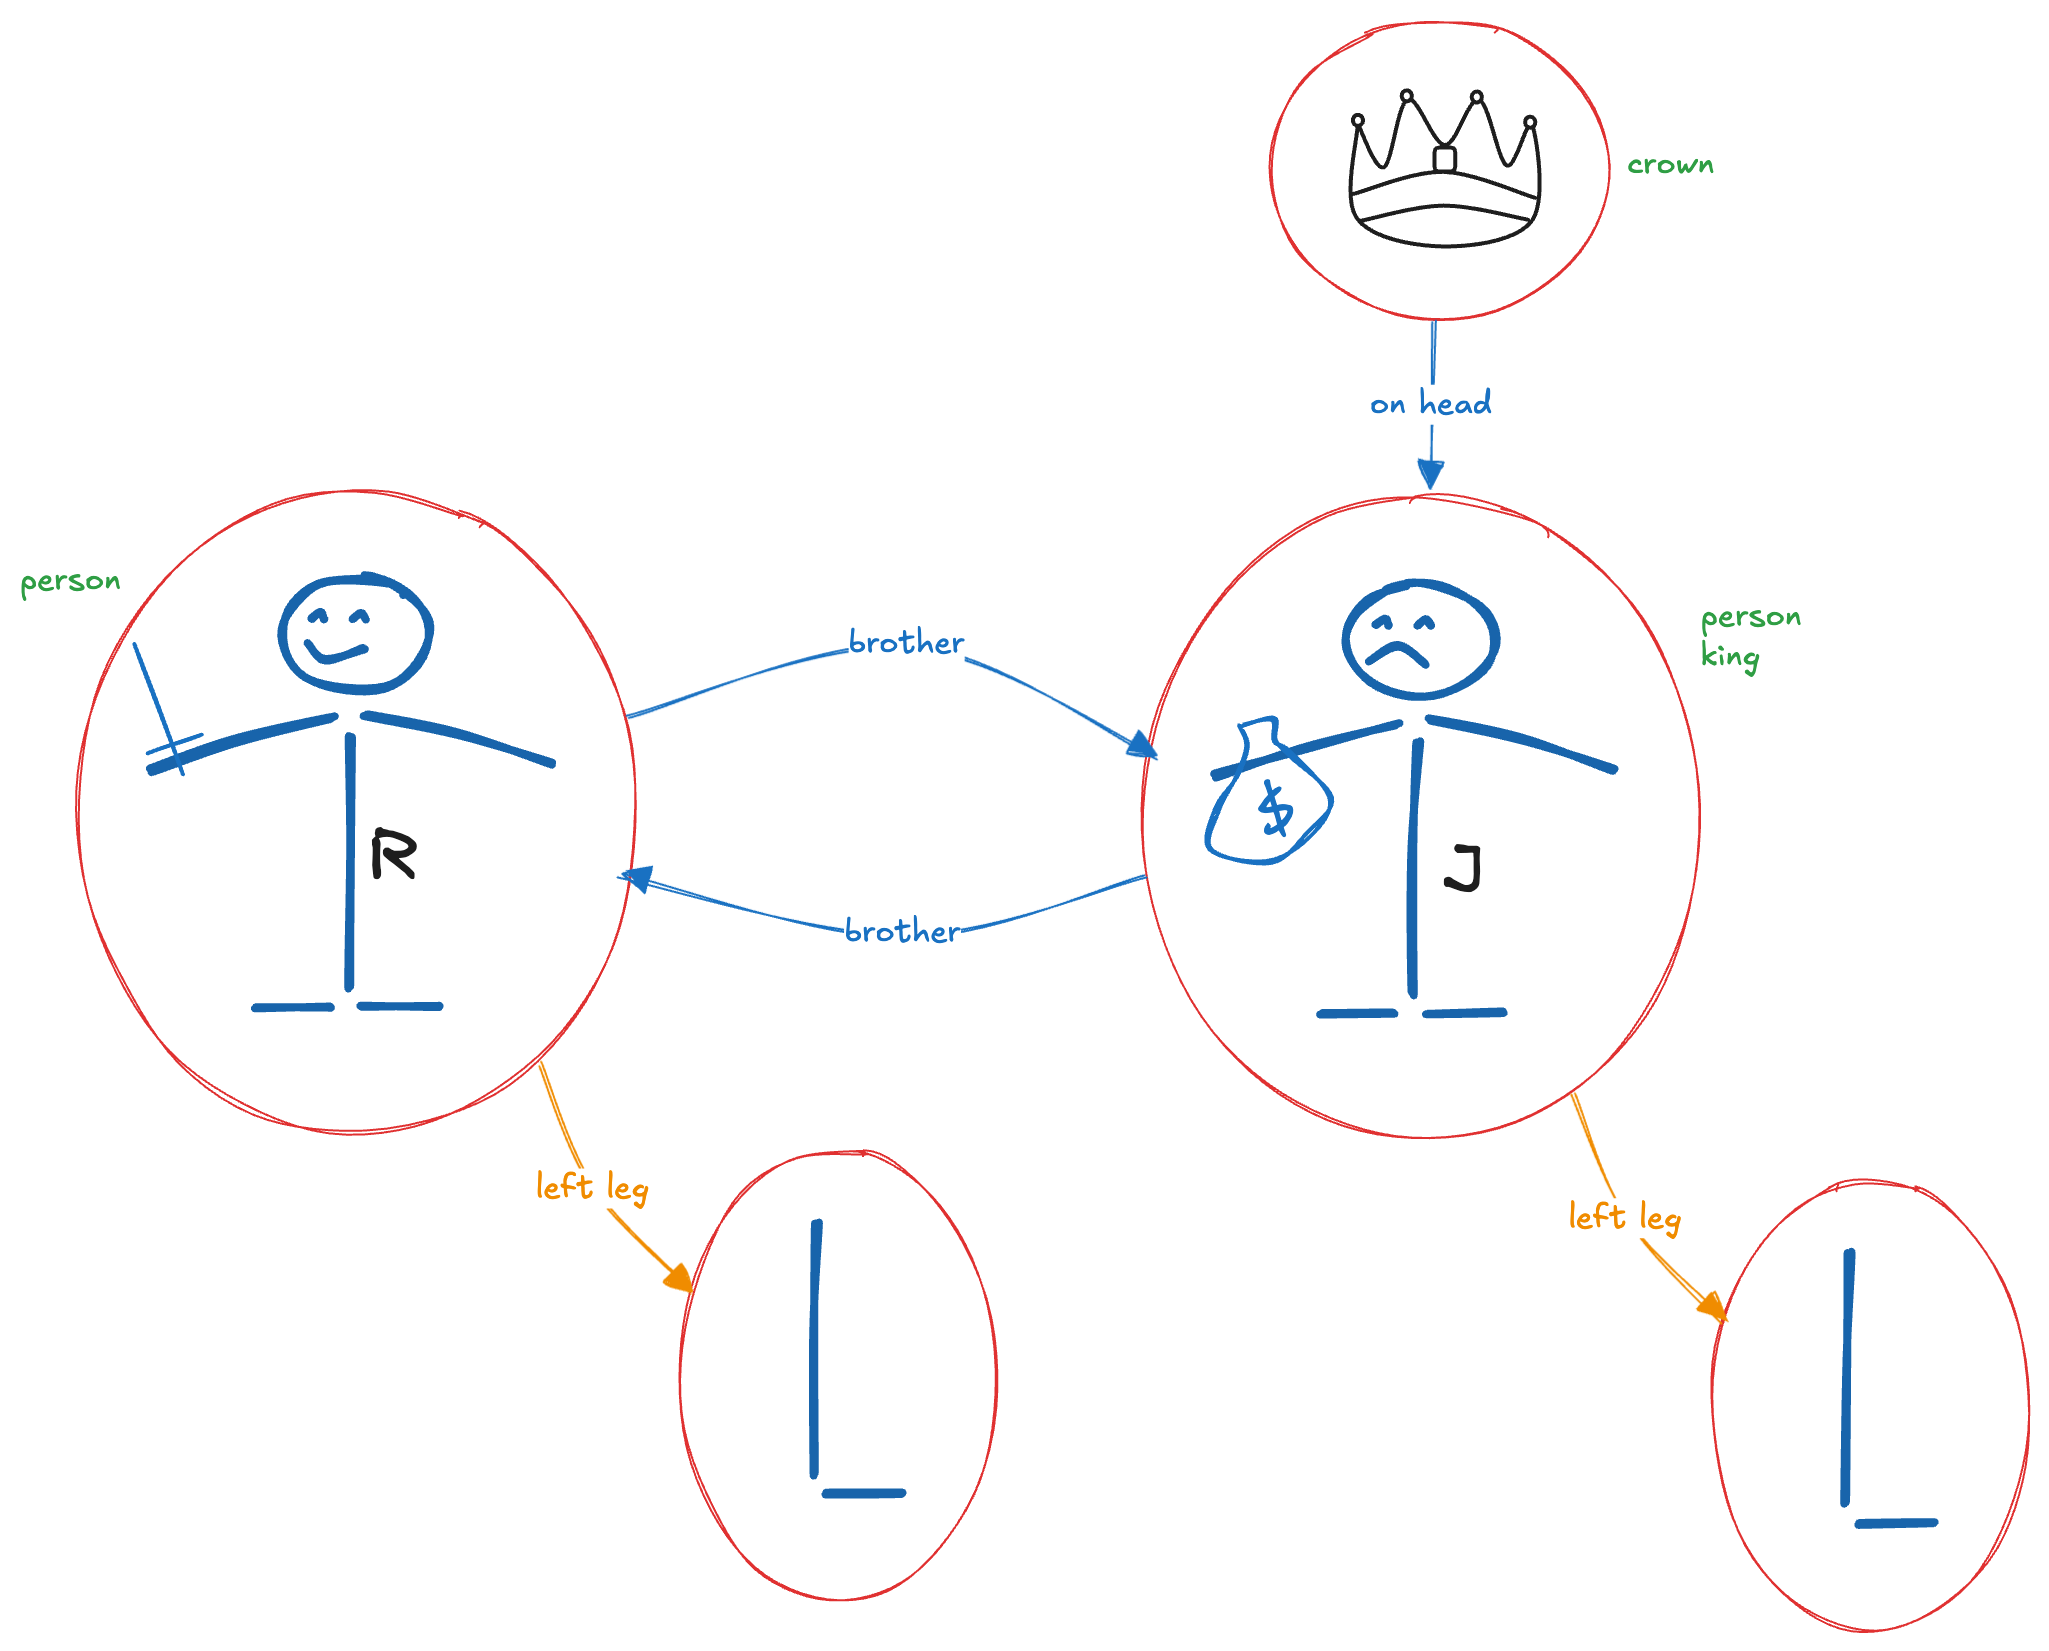

We have five objects: Richard the Lionheart, his younger brother the evil John, the left leg of Richard, the left leg of John, and a crown. The objects are related in various ways. Richard and John are brothers, the crown is owned by John and Richard and John have left legs. First-order logic formalizes this linguistic structure, allowing for much more expressive representations. It enables us to state general rules that apply across different objects and situations, and to perform more powerful and flexible reasoning about the world.

### Syntax

The syntax of first-order logic defines the valid ways to construct sentences that describe objects and their relationships. The basic syntactic elements are the symbols that stand for: 

- **constants**, which represent specific objects, like "Alice", "Bob", "2", etc.
- **predicates**, which state properties of objects or relations among objects, like "Human", "Loves", "Adjacent", etc. These are applied to objects and yield true or false values.
- **function**, which map objects to other objects, like "Mother", "Father", "LeftOf", etc. Functions can take one or more arguments and return a single object. 

In general a **term** is a logical expression that refers to an object. Simple term are directly an object (constant symbol), like "Alice". However, it is not always convenient to have a distinct symbol to name every object. In natural language we use expressions like "Alice left leg", rather than giving a name to her leg. This is what function symbols are for: instead of using a constant symbol, we use LeftLeg(Alice). In general, complex terms sre formed by a function symbol followed by a list of terms as arguments. 

Now that we have terms for referring to objects and predicate symbols for referring to relations, we can combine them to make **atomic sentences** that state facts, such as:

$\displaystyle \text{Brother}(\text{Filippo}, \text{Alice})$

that states that Filippo is the brother of Alice. Atomic sentences can have complex terms as arguments. Thus,

$\displaystyle \text{Married}(\text{Father}(\text{Filippo}), \text{Mother}(\text{Alice}))$

states that Filippo's father is married to Alice's mother.

We can use logical connectives to construct **complex sentences**, with the same syntax as in propositional logic. For example, we can express the fact that Filippo is Alice's brother and that Alice is a human:

$\displaystyle \text{Brother}(\text{Filippo}, \text{Alice}) \land Human(\text{Alice})$

We can also express implications, such as "If Filippo is Alice's brother then Alice is a human": 

$\displaystyle \text{Brother}(\text{Filippo}, \text{Alice}) \Rightarrow \text{Human}(\text{Alice})$

Once we have a logic that allows objects, it is natural to want to express **properties of entire collections of objects**, instead of enumerating the objects by name. **Quantifiers** let us do this: 

- **Universal quantification** ($\forall$) states that a property holds for all objects
- **Existential quantification** ($\exists$) states that there exists at least one object for which a property holds

Recall the difficulty we had with the **expression of general rules** in propositional logic. Rules such as "All parents are persons" can be expressed as:

$\displaystyle \forall x \; (\text{Parent}(x) \Rightarrow \text{Person}(x))$

The symbol x is called a **variable**, it is a term and can serve as the argument of a function.

Roughly speaking, universal quantification is equivalent to the conjunction of
instantiations of the property using all the objects:

$\displaystyle \text{Parent}(\text{Riccardo}) \Rightarrow \text{Person}(\text{Riccardo}) \land$  
$\displaystyle \text{Parent}(\text{Graziella}) \Rightarrow \text{Person}(\text{Graziella}) \land$   
$\displaystyle ...$      

Pay attention that the typical connective with the universal quantifier is the implication, not the conjunction. This is because we are stating a rule that applies to all objects, not just a conjunction of facts. Using the conjunction:

$\displaystyle \forall x \; (\text{Parent}(x) \land \text{Person}(x))$

would mean that every object is both a parent and a person, which is not the intended meaning.

Similarly, we can make a **statement about some object** without naming it, by using the existential quantifier and variables. To say, for example, that "exists a person who is parent of Alice", we write:

$\displaystyle \exists x \; (\text{Parent}(x, \text{Alice}) \land \text{Person}(x))$

Intuitively, the sentence that something is true for at least one object.

Roughly speaking, existential quantification is equivalent to the disjunction of
instantiations of the properties using all the objects:

$\displaystyle \text{Parent}(\text{Filippo}, \text{Alice}) \land \text{Person}(\text{Filippo}) \lor$   
$\displaystyle \text{Parent}(\text{Riccardo}, \text{Alice}) \land \text{Person}(\text{Riccardo}) \lor$ 
$\displaystyle ...$ 

Another common mistake: typicalliy the main connective with the existential quantifier is the conjunction, not the disjunction. This is because we are stating that there exists at least one object that satisfies the property, not that all objects satisfy it. Using the disjunction:

$\displaystyle \exists x \; (\text{Parent}(x, \text{Alice}) \lor \text{Person}(x))$

would mean that there exists an object that is either a parent of Alice or a person, which is not the intended meaning.

We will often want to express more complex sentences using **multiple quantifiers**. The simplest case is where the quantifiers are of the same type. For example, the sentence "every parent of every child is a person” can be written as:

$\displaystyle \forall x,y \; (\text{Parent}(x,y) \Rightarrow \text{Person}(x))$

In other cases we will have **mixtures**. "Everybody loves somebody" means that for every person, there is someone that person loves:

$\displaystyle \forall x \; \exists y \; \text{Loves}(x,y)$

On the other hand, to say "There is someone who is loved by everyone", we write:

$\displaystyle \exists y \; \forall x \; \text{Loves}(x,y)$

The **order of quantification is important**. It becomes clearer if we insert parentheses.

The two quantifiers are actually **intimately connected** with each other, through negation. Asserting that everyone dislikes parsnips is the same as ass

Asserting that everyone dislikes "broccoli" is the same as asserting there does not exist someone who likes them, and vice versa:

$\displaystyle \forall x \; \lnot \text{Likes}(x,  \text{Broccoli}) \equiv \lnot \exists x \; \text{Likes}(x, \text{Broccoli})$

And asserting that "Everyone likes ice cream" means that there is no one who does not like ice cream:

$\displaystyle \forall x \; \text{Likes}(x, IceCream) \equiv \lnot \exists x \; \lnot \text{Likes}(x, \text{IceCream})$

Because $\forall$ is a conjunction over all objects and $\exists$ is a disjunction, it should not be surprising that they obey De Morgan’s rules: 

- $\displaystyle \lnot \exists x \; P \equiv \forall x \; \lnot P$
- $\displaystyle \lnot \forall x \; P \equiv \exists x \; \lnot P$
- $\displaystyle \forall x \; P \equiv \lnot \exists x \; \lnot P$
- $\displaystyle \exists x \; P \equiv \lnot \forall x \; \lnot P$

Finally, we can use the **equality symbol** to signify that **two terms
refer to the same object**. For example:

$\displaystyle \text{Father}(\text{John}) = \text{Henry}$

says that the object referred to by Father(John) and the object referred to by Henry are the same. The equality symbol can also be used with negation to insist that **two terms are not the same object**. For example, suppose that we want to express that Richard has two brothers, John and Geoffrey, we could write:

$\displaystyle \exists x,y \; (\text{Brother}(x, \text{Richard}) \land \text{Brother}(y, \text{Richard}) \land  \lnot (x = y))$

the final negation is necessary to ensure that the two brothers are distinct objects.

In summary, the syntax of first-order logic allows us to express sentences that refer to objects, their properties, and relationships between them, and we can express it usign the Backus–Naur form:

- Sentence -> AtomicSentence | ComplexSentence   
- AtomicSentence -> Predicate | Predicate(Term,...) | Term = Term
- ComplexSentence -> 
    - $\lnot$ Sentence  
    - | Sentence $\land$ Sentence   
    - | Sentence $\lor$ Sentence    
    - | Sentence $\Rightarrow$ Sentence 
    - | Sentence $\Leftrightarrow$ Sentence 
    - ! Quantifier Variable,... Sentence
- Term -> 
    - Function(Term,...)
    - Constant
    - Variable
- Quantifier -> $\forall$ | $\exists$
- Constant -> A | X1 | John | ...
- Variable -> x | y | z | ...
- Predicate -> Loves | Running | After | ...
- Function -> Mother | Father | LeftOf | ...
- Operator precedence (from highest to lowest): 
    - $\lnot$,  
    - $\land$,  
    - $\lor$,   
    - $\Rightarrow$,    
    - $\Leftrightarrow$ 

First-order logic sentences can be represented as trees, similar to propositional logic, where each node represents a logical operator or quantifier, and its children represent the operands or terms. We can extend the Expr class to represent terms, functions, predicates, and quantifiers, which are not part of propositional logic:

In [400]:
class FOL_Expr:
    def __init__(self, op, *args):
        self.op = op
        self.args = args

    def __repr__(self):

        # Adding support for the universal quantifier
        if self.op == 'FORALL':
            return f"∀{self.args[0]} {self.args[1]}"
        
        # Adding support for the existential quantifier
        elif self.op == 'EXISTS':
            return f"∃{self.args[0]} {self.args[1]}"
        
        # Adding support for equlity
        elif self.op == 'EQUALS':
            return f"({f' = '.join(map(str, self.args))})"

        elif self.op == 'NOT':
            return f"¬{self.args[0]}"

        elif self.op in {'AND', 'OR'}:
            return f"({f' {self.op} '.join(map(str, self.args))})"

        elif self.op in {'IMPLIES', 'IFF'}:
            return f"({self.args[0]} {self.op} {self.args[1]})"

        # Adding support for predicates and functions
        elif self.args:
            return f"{self.op}({', '.join(map(str, self.args))})"

        else:
            return self.op

    def __eq__(self, other):
        return isinstance(other, FOL_Expr) and self.op == other.op and self.args == other.args

    def __hash__(self):
        return hash((self.op, self.args))

    def is_atomic(self):
        return not self.args

    def is_literal(self):
        return self.is_atomic() or (self.op == 'NOT' and self.args[0].is_atomic())

    # Overloading operators
    def __and__(self, other):
        return FOL_Expr('AND', self, other)

    def __or__(self, other):
        return FOL_Expr('OR', self, other)

    def __invert__(self):
        return FOL_Expr('NOT', self)

    def __rshift__(self, other):
        return FOL_Expr('IMPLIES', self, other)

    def iff(self, other):
        return FOL_Expr('IFF', self, other)
    

We can represent the last example:

$\displaystyle \exists x,y \; (\text{Brother}(x, \text{Richard}) \land \text{Brother}(y, \text{Richard}) \land  \lnot (x = y))$

In [401]:
# Variables
x = FOL_Expr('x')
y = FOL_Expr('y')

# Constant
richard = FOL_Expr('Richard')

# Predicates
bro_x = FOL_Expr('Brother', x, richard)
bro_y = FOL_Expr('Brother', y, richard)

# Equality and its negation
x_eq_y = FOL_Expr('EQUALS', x, y)
not_eq = ~x_eq_y

# Conjunction
conj = bro_x & bro_y & not_eq

# Quantified expression
exists_y = FOL_Expr('EXISTS', y, conj)
exists_x_y = FOL_Expr('EXISTS', x, exists_y)

# Output
print(exists_x_y)

∃x ∃y ((Brother(x, Richard) AND Brother(y, Richard)) AND ¬(x = y))


We define some shorthand helper function for readability:

In [402]:
# To create varibles
def Var(name): return FOL_Expr(name)

# To create constants
def Const(name): return FOL_Expr(name)

# To create functions
def Func(name, *args): return FOL_Expr(name, *args)

# to create predicates
def Pred(name, *args): return FOL_Expr(name, *args)

### Semantics

In propositional logic, a model is a formal structure representing a possible world. It assigns truth values to proposition symbols, allowing us to determine whether a sentence is true in that world. In first-order logic (FOL), models are much richer. They don’t just assign truth values, they refer to objects, relations, and functions. This makes them more expressive and powerful. A **model** for first-order logic consists of:

- A **domain** D: a **non-empty set of objects the model refers to**. This is the **universe of discourse**, the collection of entities we’re reasoning about. For example, if we are reasoning about people, the domain might be the set of all people; if we are modeling a chess game, it might include pieces and board squares.

- An **interpretation function** I, which is a **mapping that assigns meanings to symbols**. 
    - Constant symbols are mapped to objects in D.
    - Predicate symbols are mapped to relations over D.
    - Function symbols are mapped to functions from D^n to D.

We write a model as:

$\displaystyle \mathcal{M} = (D, I)$

For example, let’s revisit the concrete example involving English royalty:
- Domain D = {Richard, John, LeftLeg(Richard), LeftLeg(John), Crown}
- Interpretation I:
    - Constants:
	    - Richard -> Richard the Lionheart
        - John -> King John
        - LeftLeg(Richard) -> Richard’s left leg
        - LeftLeg(John) -> John’s left leg
        - Crown -> The crown of England
    - Predicates:
        - Brother -> { (Richard, John), (John, Richard) }
        - OnHead -> { (Crown, John) }
        - Person -> {Richard, John}
        - King -> {John}
        - rown -> {Crown}
    - Functions:
        - LeftLeg -> { (Richard -> LeftLeg(Richard)), (John -> LeftLeg(John)) }

We can implement the model using a dictionary to represent the domain and the interpretation function. The keys of the dictionary are the symbols, and the values are their meanings:

In [403]:
model = {
    'domain': {"Richard", "John", "Crown", "LeftLeg(Richard)", "LeftLeg(John)"},
    
    'constants': {
        'Richard': "Richard",
        'John': "John",
        'Crown': "Crown",
        'LeftLeg(Richard)': "LeftLeg(Richard)",
        'LeftLeg(John)': "LeftLeg(John)"
    },
    
    'functions': {
        'LeftLeg': lambda x: f"LeftLeg({x})"
    },
    
    'predicates': {
        'Brother': {("Richard", "John"), ("John", "Richard")},
        'Person': {("Richard",), ("John",)},         
        'King': {("John",)},                         
        'OnHead': {("Crown", "John")},               
        'Crown': {("Crown",)}                        
    }
}

This interpretation provides a complete mapping from the vocabulary to the model’s domain. Notice that **multiple interpretations are possible**. For instance, the constant symbol Richard could refer to the crown instead of John. Some objects in the domain may remain unnamed in a given interpretation. Additionally, a symbol can refer to different objects in different interpretations, and different symbols can refer to the same object. Every interpretation is valid from the logical perspective, it is responsbility of the knowledge base to eliminate those interpretations that are **inconsistent** with our knowledge. To get a sense of what the set of all possible models looks like, consider some members of the set of all models for a language with two constant symbols, A and B, and one binary relation symbol: 

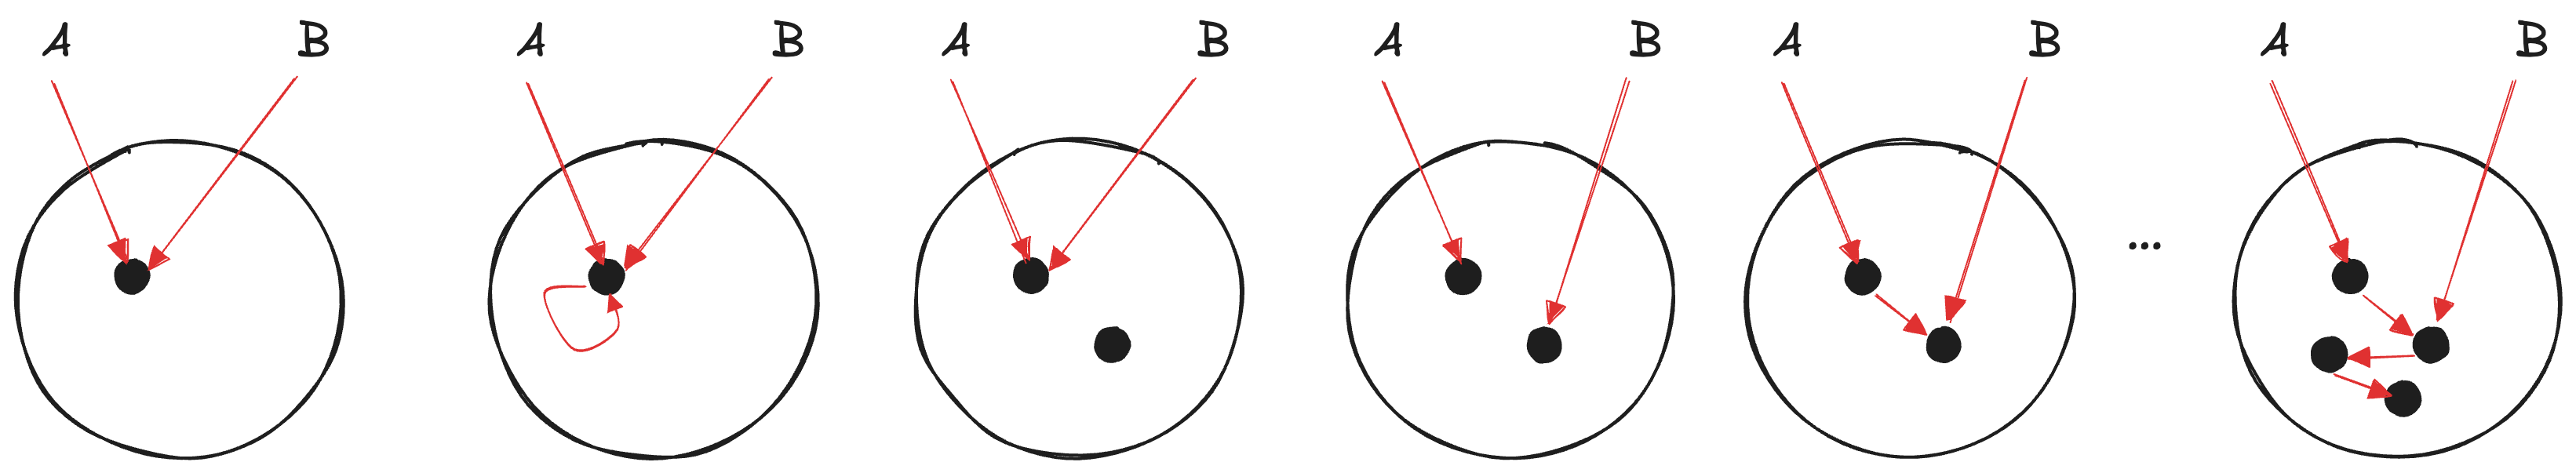

This illustrates that models can differ both in the number of objects they include (ranging from just one to infinitely many) and in how constant symbols are mapped to those objects. Unlike propositional logic, where entailment can be checked by enumerating all models, this approach is not feasible here because the number of possible models is **unbounded**. Even when the domain is limited to a fixed number of objects, **the number of interpretations can still be extremely large**.

The **truth of a sentence** is always **evaluated with respect to a model**. For an atomic sentence like 

$\displaystyle \text{King}(\text{John})$

the model determines whether the object assigned to John belongs to the set of objects assigned to the predicate King. More complex sentences are evaluated recursively: logical connectives like AND, OR, and NOT follow their usual truth-functional meanings, while quantified sentences depend on whether the formula holds for all or some elements in the domain. For example, the universal sentence:

$\displaystyle \forall x \; \text{Person}(x)$

is true in a model if every object in the domain is assigned to the predicate Person, while the existential sentence:

$\displaystyle  \exists x \; \text{King}(x)$

is true if at least one object in the domain is assigned to King. Thus, a sentence is true in a model if it holds under the interpretation and structure provided by that model. 

We can extend the evaluate method to check the truth of first-order logic sentences in a model. The method will recursively evaluate the sentence based on the logical connectives, quantifiers, and the model provided. We need also a way to keeps track of which object in the domain is temporarily assigned to a variable during evaluation, this i the role of the env dictionary:

In [404]:
def FOL_evaluate(sentence, model, env={}):

    # A funciton to evaluate terms
    def eval_term(term, model, env):
        # Variable
        if isinstance(term.op, str) and term.op in env:
            return env[term.op]

        # Constant
        if not term.args:  # No arguments = constant
            return model['constants'][term.op]

        # Function
        arg_values = [eval_term(arg, model, env) for arg in term.args]
        return model['functions'][term.op](*arg_values)

    # Handle TRUE / FALSE
    if sentence.op == "TRUE":
        return True
    if sentence.op == "FALSE":
        return False

    # Handle EQUALS
    if sentence.op == "EQUALS":
        left = eval_term(sentence.args[0], model, env)
        right = eval_term(sentence.args[1], model, env)
        return left == right

    # Handle atomic predicate
    if sentence.op not in {"NOT", "AND", "OR", "IMPLIES", "IFF", "FORALL", "EXISTS"}:
        args = [eval_term(arg, model, env) for arg in sentence.args]
        return tuple(args) in model['predicates'][sentence.op]

    # Handle NOT
    if sentence.op == "NOT":
        return not FOL_evaluate(sentence.args[0], model, env)

    # Handle AND
    if sentence.op == "AND":
        return all(FOL_evaluate(arg, model, env) for arg in sentence.args)

    # Handle OR
    if sentence.op == "OR":
        return any(FOL_evaluate(arg, model, env) for arg in sentence.args)

    # Handle IMPLIES
    if sentence.op == "IMPLIES":
        return (not FOL_evaluate(sentence.args[0], model, env)) or FOL_evaluate(sentence.args[1], model, env)

    # Handle IFF
    if sentence.op == "IFF":
        return FOL_evaluate(sentence.args[0], model, env) == FOL_evaluate(sentence.args[1], model, env)

    # Handle FORALL
    if sentence.op == "FORALL":
        var, subexpr = sentence.args
        for obj in model['domain']:
            extended_env = env.copy()
            extended_env[var.op] = obj
            if not FOL_evaluate(subexpr, model, extended_env):
                return False
        return True

    # Handle EXISTS
    if sentence.op == "EXISTS":
        var, subexpr = sentence.args
        for obj in model['domain']:
            extended_env = env.copy()
            extended_env[var.op] = obj
            if FOL_evaluate(subexpr, model, extended_env):
                return True
        return False

    raise ValueError(f"Unknown operator: {sentence.op}")

Let's consider some examples to illustrate the evaluation of first-order logic sentences in a model. 

Example 1: **Atomic Predicate**     
Sentence: "John is a person"        
Formula: $\displaystyle \text{Person}(\text{John})$

In [405]:
sentence = Pred("Person", Const("John"))
FOL_evaluate(sentence, model)

True

Example 2: **Function Term in Predicate**       
Sentence: "The left leg of Richard is LeftLeg(Richard)"     
Formula: $\displaystyle \text{LeftLeg}(\text{Richard}) = \text{LeftLeg}(\text{Richard})$

In [406]:
left_leg = Func("LeftLeg", Const("Richard"))
sentence = FOL_Expr("EQUALS", left_leg, Const("LeftLeg(Richard)"))
FOL_evaluate(sentence, model)

True

Example 3: **Implication (Material Conditional)**       
Sentence: "If John is a king, then he is a person"            
Formula: $\displaystyle \text{King}(\text{John}) \Rightarrow \text{Person}(\text{John})$

In [407]:
sentence = Pred("King", Const("John")) >> Pred("Person", Const("John"))
FOL_evaluate(sentence, model)

True

Example 4: **Universal Quantifier**     
Sentence: "All persons are persons (tautology for illustration)"        
Formula: $\displaystyle \forall x \; \text{Person}(x) \Rightarrow \text{Person}(x)$

In [408]:
x = Var("x")
sentence = FOL_Expr("FORALL", x, Pred("Person", x) >> Pred("Person", x))
FOL_evaluate(sentence, model)

True

Example 5: **Existential Quantifier**       
Sentence: "There exists a king"     
Formula: $\displaystyle \exists x \; \text{King}(x)$        

In [409]:
x = Var("x")
sentence = FOL_Expr("EXISTS", x, Pred("King", x))
FOL_evaluate(sentence, model) 

True

Example 6: **False sentece**        
Sentence: "Richard is not John’s brother"       
Formula: $\displaystyle \lnot \text{Brother}(\text{Richard}, \text{John})$      


In [410]:
sentence = ~Pred("Brother", Const("Richard"), Const("John"))
FOL_evaluate(sentence, model)

False

Example 7: **Chained Reasoning**        
Sentence: "If Richard is John’s brother and John is a king, then Richard is a person"       
Formula: $\displaystyle (\text{Brother}(\text{Richard}, \text{John}) \land \text{King}(\text{John})) \Rightarrow \text{Person}(\text{Richard})$         


In [411]:
sentence = (Pred("Brother", Const("Richard"), Const("John")) & Pred("King", Const("John"))) >> Pred("Person", Const("Richard"))
FOL_evaluate(sentence, model)

True

Example 8: **Complex Sentence with Quantifiers**        
Sentence: "There exists a king who has the crown on their head"     
Formula: $\displaystyle \exists x \; (\text{King}(x) \land \text{OnHead}(\text{Crown}, x))$    

In [412]:
x = Var("x")

sentence = FOL_Expr("EXISTS", x, 
            FOL_Expr("AND", 
             Pred("King", x), 
             Pred("OnHead", Const("Crown"), x)
         )
)

FOL_evaluate(sentence, model)

True


### Database Semantics

Often, a concept expressed in first-order logic turns out to be **significantly more complex** than its corresponding sentence in natural language. Consider, for example, the statement "Richard has two brothers, John and Geoffrey". A first attempt to translate this into logic might be:

$\displaystyle \text{Brother}(\text{John}, \text{Richard}) \land \text{Brother}(\text{Geoffrey}, \text{Richard})$

However, this sentence is incomplete. First, it does not assert that John and Geoffrey are distinct individuals (it would still be true in a model where John and Geoffrey refer to the same object). Second, it does not exclude the possibility that Richard has other brothers beyond John and Geoffrey. To fully capture the meaning of the original English sentence, we need the following logical expression:

$\displaystyle \text{Brother}(\text{John}, \text{Richard}) \land \text{Brother}(\text{Geoffrey}, \text{Richard}) \land \lnot (\text{John} = \text{Geoffrey}) \land \forall x \; (\text{Brother}(x, \text{Richard}) \Rightarrow (x = \text{John} \lor x = \text{Geoffrey}))$

This formalization is far more elaborate than the simple English statement. Yet, without this level of precision, a logical reasoning system could draw incorrect conclusions. This raises the question: can we adopt a semantics that allows simpler logical sentences without sacrificing accuracy? One approach is to **restrict the expressivity of the language**, following what’s known as the **database semantics**, which includes the following assumptions:
- The **unique-names assumption**: every constant symbol refers to a distinct object.
- The **closed-world assumption**: any atomic sentence not known to be true is assumed to be false.
- The **domain closure assumption**: the domain contains only those objects named by the constant symbols in the knowledge base.

These constraints allow us to simplify logical representations while still supporting correct inference within well-defined limits. For example, we can consider the previous example under these assumptions:

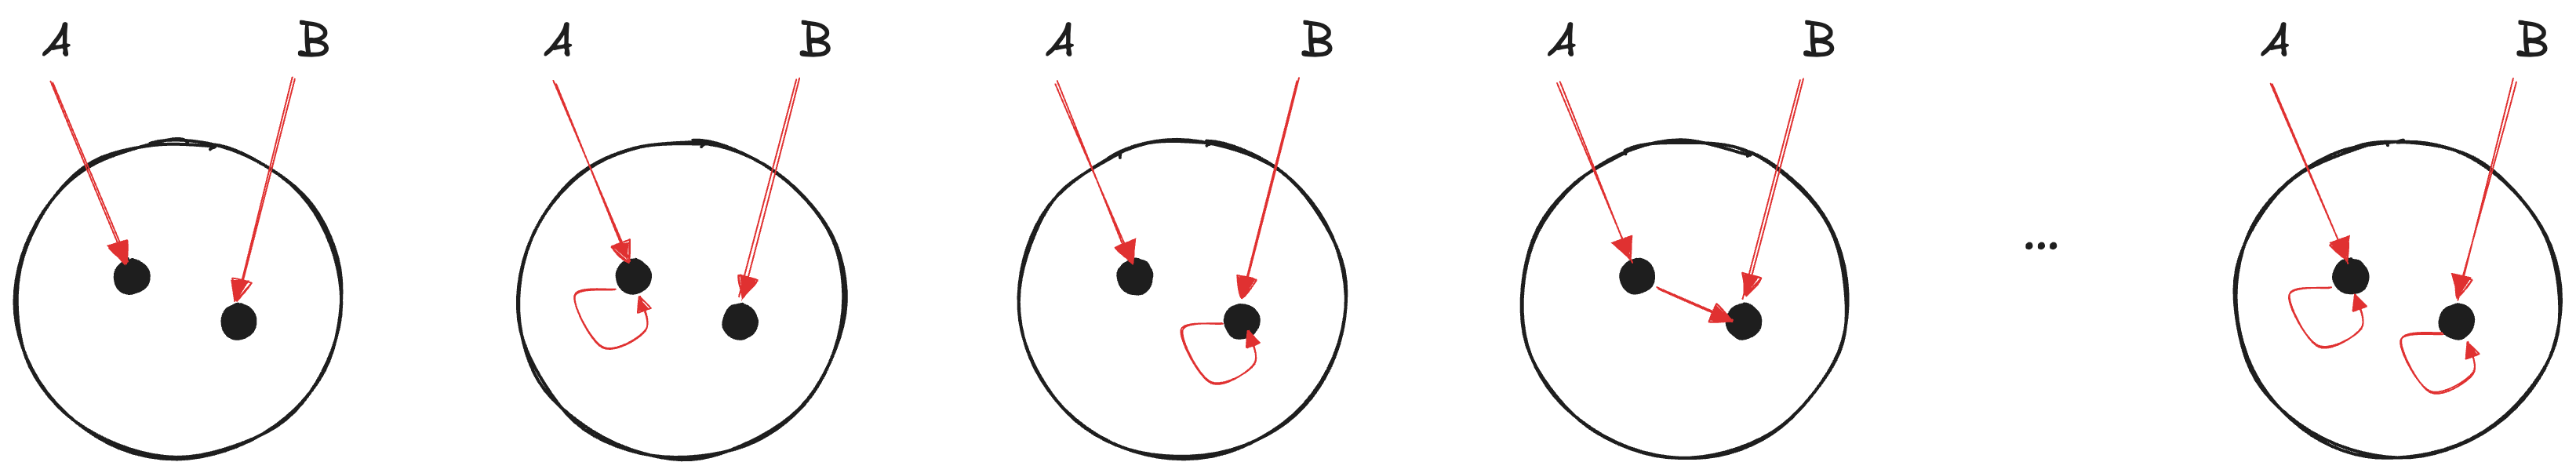

With two distinct objects in the domain, there are four possible two-element tuples, leading to 2^4 = 16 different subsets that can satisfy the relation. Consequently, there are only 16 possible models under database semantics, significantly fewer than the infinitely many models allowed by standard first-order semantics.

However, database semantics assumes **complete knowledge of the domain**: we must know exactly which objects exist and what facts are true or false about them. This example highlights a key insight: there is no single "correct" semantics for logic. The usefulness of a given semantic framework depends on how concisely and intuitively it allows us to express the knowledge we care about, and how naturally and effectively it supports inference.

Database semantics is particularly valuable in contexts where the domain is fully known, all relevant facts are explicitly stated, and each object has a unique identity (conditions typical of structured databases9. In other contexts, however, especially those involving uncertainty or incomplete information, it can be overly rigid.

### Comparison

Let's consider a simple example to illustrate the differences between propositional logic and first-order logic. Consider the following sentences to be represented in a knowledge base:

A1. Those who like opera, like both music and theatre   
A2. Alice likes music, but she does not like theatre    
A3. Bob likes exactly the same things that Alice likes  
A4. Bob does not like opera 

We can represent these sentences in first-order logic as follows:

A1 -> $\displaystyle \forall x \; (\text{Likes}(x, \text{Opera}) \Rightarrow (\text{Likes}(x, \text{Music}) \land \text{Likes}(x, \text{Theatre})))$        
A2 -> $\displaystyle \text{Likes}(\text{Alice}, \text{Music}) \land \lnot \text{Likes}(\text{Alice}, \text{Theatre})$       
A3 -> $\displaystyle \forall x \; (\text{Likes}(Bob, x) \Leftrightarrow \text{Likes}(\text{Alice}, x))$     
A4 -> $\displaystyle \lnot \text{Likes}(\text{Bob}, \text{Opera})$ 

The translation in proposition logic is possible when the domain of discourse contains only a finite number of objects, as in this case, where we have five constants:

$\displaystyle \text{Alice}, \text{Bob}, \text{Music}, \text{Theatre}, \text{Opera}$

Then we need to systematically replace all variables with the available
constants:

$\displaystyle \forall x P(x)$ becomes $\displaystyle P(\text{Alice}) \lor P(\text{Bob}) \lor P(\text{Music}) \lor P(\text{Theatre}) \lor P(\text{Opera})$       
$\displaystyle \exists x P(x)$ becomes $\displaystyle P(\text{Alice}) \lor P(\text{Bob}) \lor P(\text{Music}) \lor P(\text{Theatre}) \lor P(\text{Opera})$   

The second step is to replace atomic sentences by propositional symbols:

$\displaystyle \text{Likes}(\text{Alice}, \text{Music}) \equiv LAM$  
$\displaystyle \text{Likes}(\text{Alice}, \text{Theatre}) \equiv LAT$   
$\displaystyle \text{Likes}(\text{Alice}, \text{Opera}) \equiv LAP$         
$\displaystyle \text{Likes}(\text{Bob}, \text{Music}) \equiv LBM$   
$...$   

The number of propositional symbols can be limited by considering that some assignments of constant to variables are meaningless. In our case we can avoid
introducing propositional symbols for "Opera likes Alice", because this atomic sentence is meaningless in the current context. However, this is not always possible, and the number of propositional symbols can grow exponentially with the number of constants.

The final step is to rewrite the sentences in propositional logic:

A1 -> $\displaystyle (LAO \Rightarrow (LAM \land LAT)) \lor (LBO \Rightarrow (LBM \land LBT))$      
A2 -> $\displaystyle LAM \land \lnot LAT$       
A3 -> $\displaystyle (LBM \Leftrightarrow LAM) \land (LBT \Leftrightarrow LAT) \land (LBO \Leftrightarrow LAO)$     
A4 -> $\displaystyle \lnot LBO$     

## Inference procedures

In a knowledge-based system, we do not merely store facts and rules, we want to **reason with them**. This is the purpose of **inference**: the process of deriving new conclusions from existing information. While logic provides a formal language for representing knowledge, inference procedures define **how that knowledge can be manipulated and extended**. We introduce the core methods that allow intelligent agents to draw conclusions from what they know. These procedures are essential for answering queries, proving theorems, detecting inconsistencies, and making decisions based on logical representations of the world. We adopt propositional logic, where inference is simpler and often decidable, and we will explore two approaches:

- **Model Checking**: verifies entailment by evaluating whether a sentence is true in all models where the knowledge base is true, directly applying the semantic definition of entailment.
- **Theorem Proving**: establishes entailment by deriving the sentence from the knowledge base using a set of formal inference rules, thus constructing a formal proof of the sentence.

### Model Checking

Model checking **directly follows the definition of entailment** by systematically examining all possible models to determine whether a sentence is true in every model where the knowledge base is true. While conceptually simple, this approach can become **computationally expensive** as the size of the KB or the complexity of the sentences increases. Two core algorithms for propositional reasoning are:

- **Truth table enumeration**, which tests entailment by exhaustively evaluating all possible models
- **Satisfiability-based inference**, which checks whether the negation of the query leads to a contradiction.

#### Reasoning by truth tables

A simple and direct method for checking entailment is to use truth tables. Consider the entailment in propositional logic:

$\displaystyle A \models B$

a model is an assignment of truth values to each symbol that appears in either A, B, or both. For each model (row), we can compute the truth value of both A and B, by evaluating them. Then we can show that the entailment holds if and only if every model in which A is true also makes B true. This approach can be used  when A is a knowledge base (KB) and B is a query sentence:

$\displaystyle KB = A_1 \land A_2 \land A_3 \land \dots$

$\displaystyle KB \models q$

We can write a function to enumerate all possible truth assignments for the symbols involved. It builds the full truth table, evaluating the knowledge base and the query in each model. If the KB is true in a model but the query is false, it identifies a **counterexample** and concludes that the entailment does not hold. Otherwise, it confirms the entailment and prints a row-by-row explanation of the reasoning process:

In [548]:
def truth_table_inference(kb, query):

    # Check if the knowledge base is empty
    if not kb.sentences:
        return False

    # Manually build conjunction of all KB sentences
    kb_sentence = kb.sentences[0]
    for s in kb.sentences[1:]:
        kb_sentence = PL_Expr("AND", kb_sentence, s)

    # Extract all symbols from KB and query
    symbols = list(get_symbols(kb_sentence) | get_symbols(query))

    # Print header
    header = " | ".join(f"{str(sym):^6}" for sym in symbols)
    print(f"{header} ||  KB   | Query | Result")
    print("-" * (len(header) + 26))

    # Track entailment status
    entailed = True

    # Enumerate all possible truth assignments
    for values in itertools.product([False, True], repeat=len(symbols)):

        # Create a model mapping symbols to their truth values
        model = dict(zip(symbols, values))

        # Evaluate KB and query
        kb_val = PL_evaluate(kb_sentence, model)
        query_val = PL_evaluate(query, model)

        # Check entailment: if KB is true, query must also be true
        if kb_val and not query_val:
            entailed = False

        # Format row
        row = " | ".join(f"{'T' if model[sym] else 'F':^6}" for sym in symbols)
        row += f" ||   {'T' if kb_val else 'F'}   |   {'T' if query_val else 'F'}   "

        # print row, marking the entailment status 
        if kb_val and not query_val:
            row += " | X"
        else:
            row += " | OK"
        print(row)

    # Return whether the query is entailed by the KB
    return entailed

Let's consider a simple reasoning example:

-(a) "When it rains and it is windy, Alice wears a raincoat"        
-(b) "It rains, but Alice does not wear a raincoat"     
-(c) "Threfore, it is not windy"        

We can represent these sentences in propositional logic as follows:

-(a) $R \land W \Rightarrow A_{RC}$        
-(b) $R \land \lnot A_{RC}$        
-(c) $\lnot W$

We want to prove that {a, b} (our KB) entails c (our conclusion):

$\displaystyle {a, b} \models c$

In [549]:
# Define atoms
R = PL_Expr("R")
W = PL_Expr("W")
ARC = PL_Expr("A_RC")

# Define sentences
sentence_a = (R & W) >> ARC
sentence_b = R & ~ARC
sentence_c = ~W

# Create and populate KB
kb = KB()
kb.tell(sentence_a)
kb.tell(sentence_b)

# Create the query
query = sentence_c

# Perform inference
result = truth_table_inference(kb, query)
print(f"\nIs the query {query} entailed by the KB? {'Yes' if result else 'No'}")

  W    |  A_RC  |   R    ||  KB   | Query | Result
--------------------------------------------------
  F    |   F    |   F    ||   F   |   T    | OK
  F    |   F    |   T    ||   T   |   T    | OK
  F    |   T    |   F    ||   F   |   T    | OK
  F    |   T    |   T    ||   F   |   T    | OK
  T    |   F    |   F    ||   F   |   F    | OK
  T    |   F    |   T    ||   F   |   F    | OK
  T    |   T    |   F    ||   F   |   F    | OK
  T    |   T    |   T    ||   F   |   F    | OK

Is the query ¬W entailed by the KB? Yes


We can use the method to show some example of inference. First we consider a **simple logical consequence**, like P $\Rightarrow$ Q, P $\models$ Q?:

In [ ]:
# Define atomic propositions
P = PL_Expr("P")
Q = PL_Expr("Q")

# Build knowledge base: P -> Q, P
kb = KB()
kb.tell(P >> Q)
kb.tell(P)       

# Query: Q
query = Q

# Perform inference
result = truth_table_inference(kb, query)
print(f"\nIs the query {query} entailed by the KB? {'Yes' if result else 'No'}")

  P    |   Q    ||  KB   | Query | Result
-----------------------------------------
  F    |   F    ||   F   |   F    | OK
  F    |   T    ||   F   |   T    | OK
  T    |   F    ||   F   |   F    | OK
  T    |   T    ||   T   |   T    | OK

Is the query Q entailed by the KB? Yes


A non trivial case, with multiple premises: (P $\Rightarrow$ Q) $\land$ (Q $\Rightarrow$ R), P $\models$ R? Here, the chain of implications is: if P then Q, and if Q then R, and we know P, then R must be true:

In [551]:
# Define atomic propositions
P = PL_Expr("P")
Q = PL_Expr("Q")
R = PL_Expr("R")

# Build knowledge base:
kb = KB()
kb.tell(P >> Q)       
kb.tell(Q >> R)       
kb.tell(P)            

# Query: R
query = R

# Perform inference
result = truth_table_inference(kb, query)
print(f"\nIs the query {query} entailed by the KB? {'Yes' if result else 'No'}") 

  P    |   Q    |   R    ||  KB   | Query | Result
--------------------------------------------------
  F    |   F    |   F    ||   F   |   F    | OK
  F    |   F    |   T    ||   F   |   T    | OK
  F    |   T    |   F    ||   F   |   F    | OK
  F    |   T    |   T    ||   F   |   T    | OK
  T    |   F    |   F    ||   F   |   F    | OK
  T    |   F    |   T    ||   F   |   T    | OK
  T    |   T    |   F    ||   F   |   F    | OK
  T    |   T    |   T    ||   T   |   T    | OK

Is the query R entailed by the KB? Yes


We can consider a situation where the inference is false: P $\models$ Q, no knowledge about P, and we query about Q. In that case, we know that "P implies Q", but we don't know if P is true, so we cannot conclude anything about Q:

In [552]:
# Define atomic propositions
P = PL_Expr("P")
Q = PL_Expr("Q")

# Build knowledge base:
kb = KB()
kb.tell(P >> Q) 

# Define the query: is Q entailed?
query = Q

# Perform inference
result = truth_table_inference(kb, query)
print(f"\nIs the query {query} entailed by the KB? {'Yes' if result else 'No'}") 

  P    |   Q    ||  KB   | Query | Result
-----------------------------------------
  F    |   F    ||   T   |   F    | X
  F    |   T    ||   T   |   T    | OK
  T    |   F    ||   F   |   F    | OK
  T    |   T    ||   T   |   T    | OK

Is the query Q entailed by the KB? No


Notice that if the knowledge base answers false to a query, **this does not necessarily mean that the statement itself is false in the real world**. It only means that, **based on the current information, the statement cannot be logically inferred as true**. A False answer from the KB means **not currently entailed**, not necessarily **definitely false**. New knowledge added later could allow the KB to infer the statement as true (or sometimes even false with certainty). This is because logical inference depends strictly on the information currently stored in the KB. 

We can have **contradictory sentences** in the KB, like P and $\lnot$ P. In this case, the KB is **inconsistent**, and **we can conclude anything from it**. There is no model where all the sentences are simultaneously true. This is known as the **principle of explosion**, which states that **from a contradiction, anything follows** (in an inconsistent world, everything is both true and false):

In [553]:
# Define atomic propositions
P = PL_Expr("P")

# Build an inconsistent knowledge base:
kb = KB()
kb.tell(P)
kb.tell(~P)  # Contradictory sentences

# Define the query: is Q entailed?
query = Q

# Perform inference
result = truth_table_inference(kb, query)
print(f"\nIs the query {query} entailed by the KB? {'Yes' if result else 'No'}")

# And not Q? ?
query = ~Q

# Perform inference
result = truth_table_inference(kb, query)
print(f"\nIs the query {query} entailed by the KB? {'Yes' if result else 'No'}")

  P    |   Q    ||  KB   | Query | Result
-----------------------------------------
  F    |   F    ||   F   |   F    | OK
  F    |   T    ||   F   |   T    | OK
  T    |   F    ||   F   |   F    | OK
  T    |   T    ||   F   |   T    | OK

Is the query Q entailed by the KB? Yes
  P    |   Q    ||  KB   | Query | Result
-----------------------------------------
  F    |   F    ||   F   |   T    | OK
  F    |   T    ||   F   |   F    | OK
  T    |   F    ||   F   |   T    | OK
  T    |   T    ||   F   |   F    | OK

Is the query ¬Q entailed by the KB? Yes


This is because once the KB is logically false in all models, the implication is vacuously true for any question.

The algorithm is **sound** because it directly implements the definition of logical entailment, and **complete** because it works for any knowledge base and query, always terminating (there are only finitely many models to examine). However, "finite" does not mean "efficient": with n propositional symbols, the algorithm must evaluate 2^n possible models. As a result, its time complexity is O(2^n). Since propositional entailment is **NP-complete**, all known inference algorithms have exponential time complexity.

Additionally, reasoning via truth tables is **unnatural from a cognitive perspective**. The process bears little resemblance to the way humans typically reason. This can be a limitation in applications where an artificial agent must **explain or justify** its conclusions in a way that is understandable and convincing to humans.

#### Propositional satisfiability

The **satisfiability problem** (SAT) asks whether exists an assignment of truth values to variables that makes a given sentence true. The **inference can be reduced to a SAT problem** by the **reduction ad absurdum**: if we want to check whether a knowledge base KB entails a query q, we can check whether the negation of the query is unsatisfiable when added to the knowledge base:

$\displaystyle KB \models q \Leftrightarrow \lnot (KB \land \lnot q) \text{ is unsatisfiable}$

So a way to check entailment is to check whether the negation of the query is satisfiable when added to the knowledge base. If it is not satisfiable, then the query is entailed by the knowledge base. Considering the previous reasoning example:

-(a) $R \land W \Rightarrow A_{RC}$        
-(b) $R \land \lnot A_{RC}$        
-(c) $\lnot W$

To prove that:

$\displaystyle {a, b} \models c$

We can check whether the folllwoing sentence is unsatisfiable:

$\displaystyle (R \land W \Rightarrow A_{RC}) \land (R \land \lnot A_{RC}) \land W$


In [554]:
# Define atoms
R = PL_Expr("R")
W = PL_Expr("W")
ARC = PL_Expr("A_RC")

# Define sentences
sentence_a = (R & W) >> ARC
sentence_b = R & ~ARC
sentence_c = ~W

# Create the query
query = sentence_c

# Create the sentence
sentence = sentence_a & sentence_b & ~query

# Check if the sentence is satisfiable
result = is_satisfiable(sentence)
print(f"\nIs the sentence {sentence} satisfiable? {'Yes' if result else 'No'}")



Is the sentence (R & ¬A_RC & ((R & W) -> A_RC) & ¬¬W) satisfiable? No


Since the sentence is unsatisfiable, we can conclude that the knowledge base entails the query. However, this approach is essentially a reformulation of the truth table method and does not offer any performance improvements. A more efficient alternative is the [DPLL algorithm](./papers/(1961)%20-%20A%20Computing%20Procedure%20for%20Quantification%20Theory.pdf)(named after its authors Davis, Putnam, Logemann, and Loveland).
The key idea behind DPLL is to incrementally construct a model (a complete assignment of truth values to the symbols) starting from an empty assignment. If a satisfying model is found, the formula is satisfiable; otherwise, if the search exhausts all possibilities without success, the formula is unsatisfiable. To facilitate this process, the formula is first transformed into CNF form, to have a structure that aligns naturally with clause-level recursive search. In CNF form, the sentence is a conjunction of clauses, where each clause is a disjunction of literals:

$\displaystyle (A_1 \lor A_2 \lor \dots) \land (B_1 \lor B_2 \lor \dots) \land (C_1 \lor C_2 \lor \dots)$

The algorithm works **recursively by selecting a literal** from the first clause, assigning it a truth value, and then checking whether the remaining clauses can be satisfied under that partial assignment. If a contradiction is encountered, **the algorithm backtracks** and tries the opposite assignment for the literal. The CNF structure is crucial because it enables the algorithm to prune large portions of the search space through **early termination** conditions:
- a clause (a disjunction of literals) is satisfied if at least one of its literals is true, regardless of the others. This means that a sentence can be determined satisfiable even before the model is fully specified;
- conversely, the sentence is unsatisfiable if any clause is false (that is, if all its literals are false under the current partial assignment)

We now define a function to evaluate a CNF sentence under a partial model and detect such early termination conditions. It returns true if all clauses are already satisfied, false if any clause is definitively false under current assignments, and none if the satisfiability is still undecided:

In [555]:
def early_termination_check(sentence, partial_model):

    # Get the clauses from the sentence
    clauses = sentence.args if sentence.op == 'AND' else [sentence]

    # Flag to track if all clauses are satisfied
    all_satisfied = True

    # Iterate through each clause
    for clause in clauses:

        # Flag to track if the clause is satisfied
        clause_satisfied = False

        # Count undecided literals in the clause
        undecided_literals = 0

        # Get the literals in the clause
        literals = clause.args if clause.op == 'OR' else [clause]

        # Iterate through each literal in the clause
        for literal in literals:

            if literal.op == 'NOT':
                sym = literal.args[0]
                val = partial_model.get(sym)
                if val is None:
                    undecided_literals += 1
                elif val is False:    
                    clause_satisfied = True
                    break
            
            else:
                sym = literal
                val = partial_model.get(sym)
                if val is None:
                    undecided_literals += 1
                elif val is True:           #  p è soddisfatta se p è True
                    clause_satisfied = True
                    break

        # If the clause is satisfied, we continue to the next clause
        if clause_satisfied:
            continue

        # If all literals are assigned, the clause is false
        elif undecided_literals == 0:   
            return False
        
        # Otherwise, we have an undecided clause
        else:                               
            all_satisfied = False

    # Return True if all clauses are satisfied or None 
    return True if all_satisfied else None

We can make some simple examples:

In [557]:
# Define atomic propositions
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')
D = PL_Expr('D')

# Example 1 ((A | B) & (~C | D) is satisfiable with A=True, C=False)
sentence = (A | B) & (~C | D)
partial_model = {A: True, C: False}
result = early_termination_check(sentence, partial_model)
print(sentence, " with model ", partial_model, " early termination:", result)

# Example 2: ((A | B) & C) is satisfiable with A=False, B=False, C=False
sentence = (A | B) & C
partial_model = {A: False, B: False, C: False}
result = early_termination_check(sentence, partial_model)
print(sentence, " with model ", partial_model, " early termination:", result)

# Example 3: (A | B) & C is undecided with A=False
sentence = (A | B) & C
partial_model = {A: False}
result = early_termination_check(sentence, partial_model)
print(sentence, " with model ", partial_model, " early termination:", result)


((A | B) & (¬C | D))  with model  {A: True, C: False}  early termination: True
((A | B) & C)  with model  {A: False, B: False, C: False}  early termination: False
((A | B) & C)  with model  {A: False}  early termination: None


To improve efficiency, the DPLL algorithm applies **two key heuristics** to simplify the sentence during the search. The first is the **pure literal heuristic**. A pure literal is a symbol that appears in the formula **only with one polarity**, either always positive or always negated, but never both. The heuristic relies on the observation that if a formula is satisfiable, then it remains satisfiable when each pure literal is assigned a value that makes it true. This assignment cannot make any clause false, since the opposite polarity does not occur. DPLL uses this heuristic by scanning for such literals and assigning them accordingly, thereby simplifying the formula and reducing the number of recursive calls. Next, we define a function that identifies a pure literal not yet assigned in the current partial model:

In [558]:
def find_pure_literal(sentence, partial_model):

    # Initialize sets for positive and negative literals
    positive = set()
    negative = set()

    # Extract clauses from the CNF sentence
    clauses = [sentence] if sentence.op != 'AND' else sentence.args

    # Iterate through each clause
    for clause in clauses:

        # Extract literals from the clause
        literals = clause.args if clause.op == 'OR' else [clause]

        # Iterate through each literal in the clause
        for lit in literals:
            if lit.op == 'NOT':
                sym = lit.args[0]
                if sym not in partial_model:
                    negative.add(sym)
            else:
                sym = lit
                if sym not in partial_model:
                    positive.add(sym)

    # Check for positive pure literals
    for sym in positive:
        if sym not in negative:
            return sym

    # Check for negative pure literals
    for sym in negative:
        if sym not in positive:
            return ~sym

    # If no pure literal is found, return None
    return None 

We can write some simple examples to illustrate the pure literal heuristic:

In [559]:
# Symbols
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')
D = PL_Expr('D')

# Example 1: (A | B) & (A | C) model {B: True, C: True} provides pure literal A
sentence = (A | B) & (A | C)
partial_model = {B: True, C: True}
result = find_pure_literal(sentence, partial_model)
print(sentence, " with model ", partial_model, " provides ", result)

# Example 2: (~C | B) & (~C | D) model {B: False, D: False} provides pure literal ~C
sentence = (~C | B) & (~C | D)
partial_model = {B: False, D: False}
result = find_pure_literal(sentence, partial_model)
print(sentence, " with model ", partial_model, " provides ", result)

# Example 3: (A | B) & ~A model {B: True} does not provide a pure literal
sentence = (A | B) & ~A
partial_model = {B: True}
result = find_pure_literal(sentence, partial_model)
print(sentence, " with model ", partial_model, " provides ", result)

((A | B) & (A | C))  with model  {B: True, C: True}  provides  A
((¬C | B) & (¬C | D))  with model  {B: False, D: False}  provides  ¬C
((A | B) & ¬A)  with model  {B: True}  provides  None


The second heuristic is the **unit clause heuristic**. A unit clause is a clause **not yet satisfied by the current partial model** and that contains **exactly one unassigned literal**, while all other literals (if present) are already falsified under the current partial model. In such cases, the truth value of the remaining literal is not a matter of choice, it must be assigned a specific value to satisfy the clause. However, if the sentence is already satisfied by the current partial model, the value of the remaining literal does not matter, and it can be assigned arbitrarily. When a unit clause appears, it means that there is only one way to satisfy it, and thus the algorithm can immediately assign the required value to that literal. This assignment can create new unit clauses in other parts of the formula, causing the propagation to continue recursively. This leads to unit propagation, a process in which the algorithm immediately assigns the required value to satisfy any unit clause as soon as it appears. Crucially, this assignment can create new unit clauses in other parts of the formula, causing the propagation to continue recursively. This significantly reduces the search space by removing the need to explore assignments for variables whose values are logically determined by the current state of the formula. Moreover, it enables **early detection of contradictions**: if a unit clause cannot be satisfied, the algorithm can immediately backtrack without further exploration. To implement this heuristic, we define a function that identify a unit clauses in the current sentence and returns it:

In [560]:
def find_unit_clause(sentence, partial_model):

    # Extract clauses from the sentence
    clauses = [sentence] if sentence.op != 'AND' else sentence.args

    # Iterate through each clause
    for clause in clauses:

        # Extract literals from the clause
        literals = clause.args if clause.op == 'OR' else [clause]

        # Collect unassigned literals
        unassigned = []

        # Flag to track if the clause is satisfied
        clause_satisfied = False

        # Iterate through each literal in the clause
        for lit in literals:

            if lit.op == 'NOT':
                sym = lit.args[0]
                val = partial_model.get(sym)
                if val is None:
                    unassigned.append(lit)
                elif val is False:
                    clause_satisfied = True
                    break
            else:
                sym = lit
                val = partial_model.get(sym)
                if val is None:
                    unassigned.append(lit)
                elif val is True:
                    clause_satisfied = True
                    break

        # If there is exactly one unassigned literal, return it
        # and the clause is not satisfied 
        if not clause_satisfied and len(unassigned) == 1:
            return unassigned[0]

    # If no unit clause is found, return None
    return None

Here some simple example to illustrate the unit clause heuristic:

In [ ]:
# Symbols
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')
D = PL_Expr('D')

# Example 1: A | B with model {B: False} provides unit clause A
sentence = A | B
partial_model = {B: False}
result = find_unit_clause(sentence, partial_model)
print(sentence, " with model ", partial_model, " provides ", result)

# Example 2: (A | B) & (C | D) with model {} provides unit clause None
sentence = (A | B) & (C | D)
partial_model = {}
result = find_unit_clause(sentence, partial_model)
print(sentence, " with model ", partial_model, " provides ", result)

# Example 3: (A | B) & (C | D) with model {C: False} provides unit clause D
sentence = (A | B) & (C | D)
partial_model = {C: False}
result = find_unit_clause(sentence, partial_model)
print(sentence, " with model ", partial_model, " provides ", result)

(¬A | B)  with model  {B: False}  provides  ¬A
((A | B) & (C | D))  with model  {}  provides  None
((A | B) & (C | D))  with model  {C: False}  provides  D


Now we bring all the components together into the complete DPLL algorithm, which integrates CNF conversion, recursive search, early termination checks, and the use of both the pure literal and unit clause heuristics:

In [682]:
def dpll_entail(kb, query, verbose=True):

    # Combine KB into a single sentence:
    kb_sentence = PL_Expr('AND', *kb.sentences) if len(kb.sentences) > 1 else kb.sentences[0]

    # Add ¬query
    negated_query = PL_Expr('NOT', query)
    full_sentence = PL_Expr('AND', kb_sentence, negated_query)

    # Convert to CNF
    cnf = to_cnf(full_sentence)

    if verbose: print("CNF for DPLL:", cnf)

    # Extract symbols from the CNF
    symbols = get_symbols(cnf)

    # Run DPLL recursion with an empty partial model
    return not dpll(cnf, symbols, partial_model={}, verbose=verbose)

In [683]:
def dpll(sentence, symbols, partial_model, verbose=True):

    # Check the early termination conditions
    check = early_termination_check(sentence, partial_model)
    
    if verbose:
        print("Current model:", partial_model)
        print("Early termination check:", check)

    if check is True: return True
    if check is False: return False

    # Unit clause heuristic
    unit = find_unit_clause(sentence, partial_model)

    if verbose: print("Unit clause found:", unit)
    
    if unit:
        if unit.op == 'NOT':
            sym = unit.args[0]
            val = False
        else:
            sym = unit
            val = True

        new_model = partial_model.copy()
        new_model[sym] = val
        new_symbols = [s for s in symbols if repr(s) != repr(sym)]

        return dpll(sentence, new_symbols, new_model, verbose=verbose)

    # Pure literal heuristic
    pure = find_pure_literal(sentence, partial_model)

    if verbose: print("Pure literal found:", pure)
    
    if pure:
        if pure.op == 'NOT':
            sym = pure.args[0]
            val = False
        else:
            sym = pure
            val = True
        new_model = partial_model.copy()
        new_model[sym] = val
        new_symbols = [s for s in symbols if repr(s) != repr(sym)]
        
        return dpll(sentence, new_symbols, new_model, verbose=verbose)

    # Choose the first remaining symbol
    sym = symbols[0]
    rest = symbols[1:]

    new_model_true = partial_model.copy()
    new_model_true[sym] = True

    if dpll(sentence, rest, new_model_true):
        return True

    new_model_false = partial_model.copy()
    new_model_false[sym] = False
    
    return dpll(sentence, rest, new_model_false, verbose=verbose)

Now we can consider the already mentioned reasoning example:

Knowledge base:
- $(R \land W) \Rightarrow A_{RC}$        
- $R \land \lnot A_{RC}$    

Query:
- $\lnot W$

We want to prove that our KB entails the query using the DPLL algorithm:

$\displaystyle ((R \land W) \Rightarrow A_{RC}) \land (R \land \lnot A_{RC}) \land W$

First of all we need the CNF form:

$\displaystyle (\lnot R \lor \lnot W \lor A_{RC}) \land R \land \lnot A_{RC}) \land W$

Now we can apply the algorithm and its heuristics:

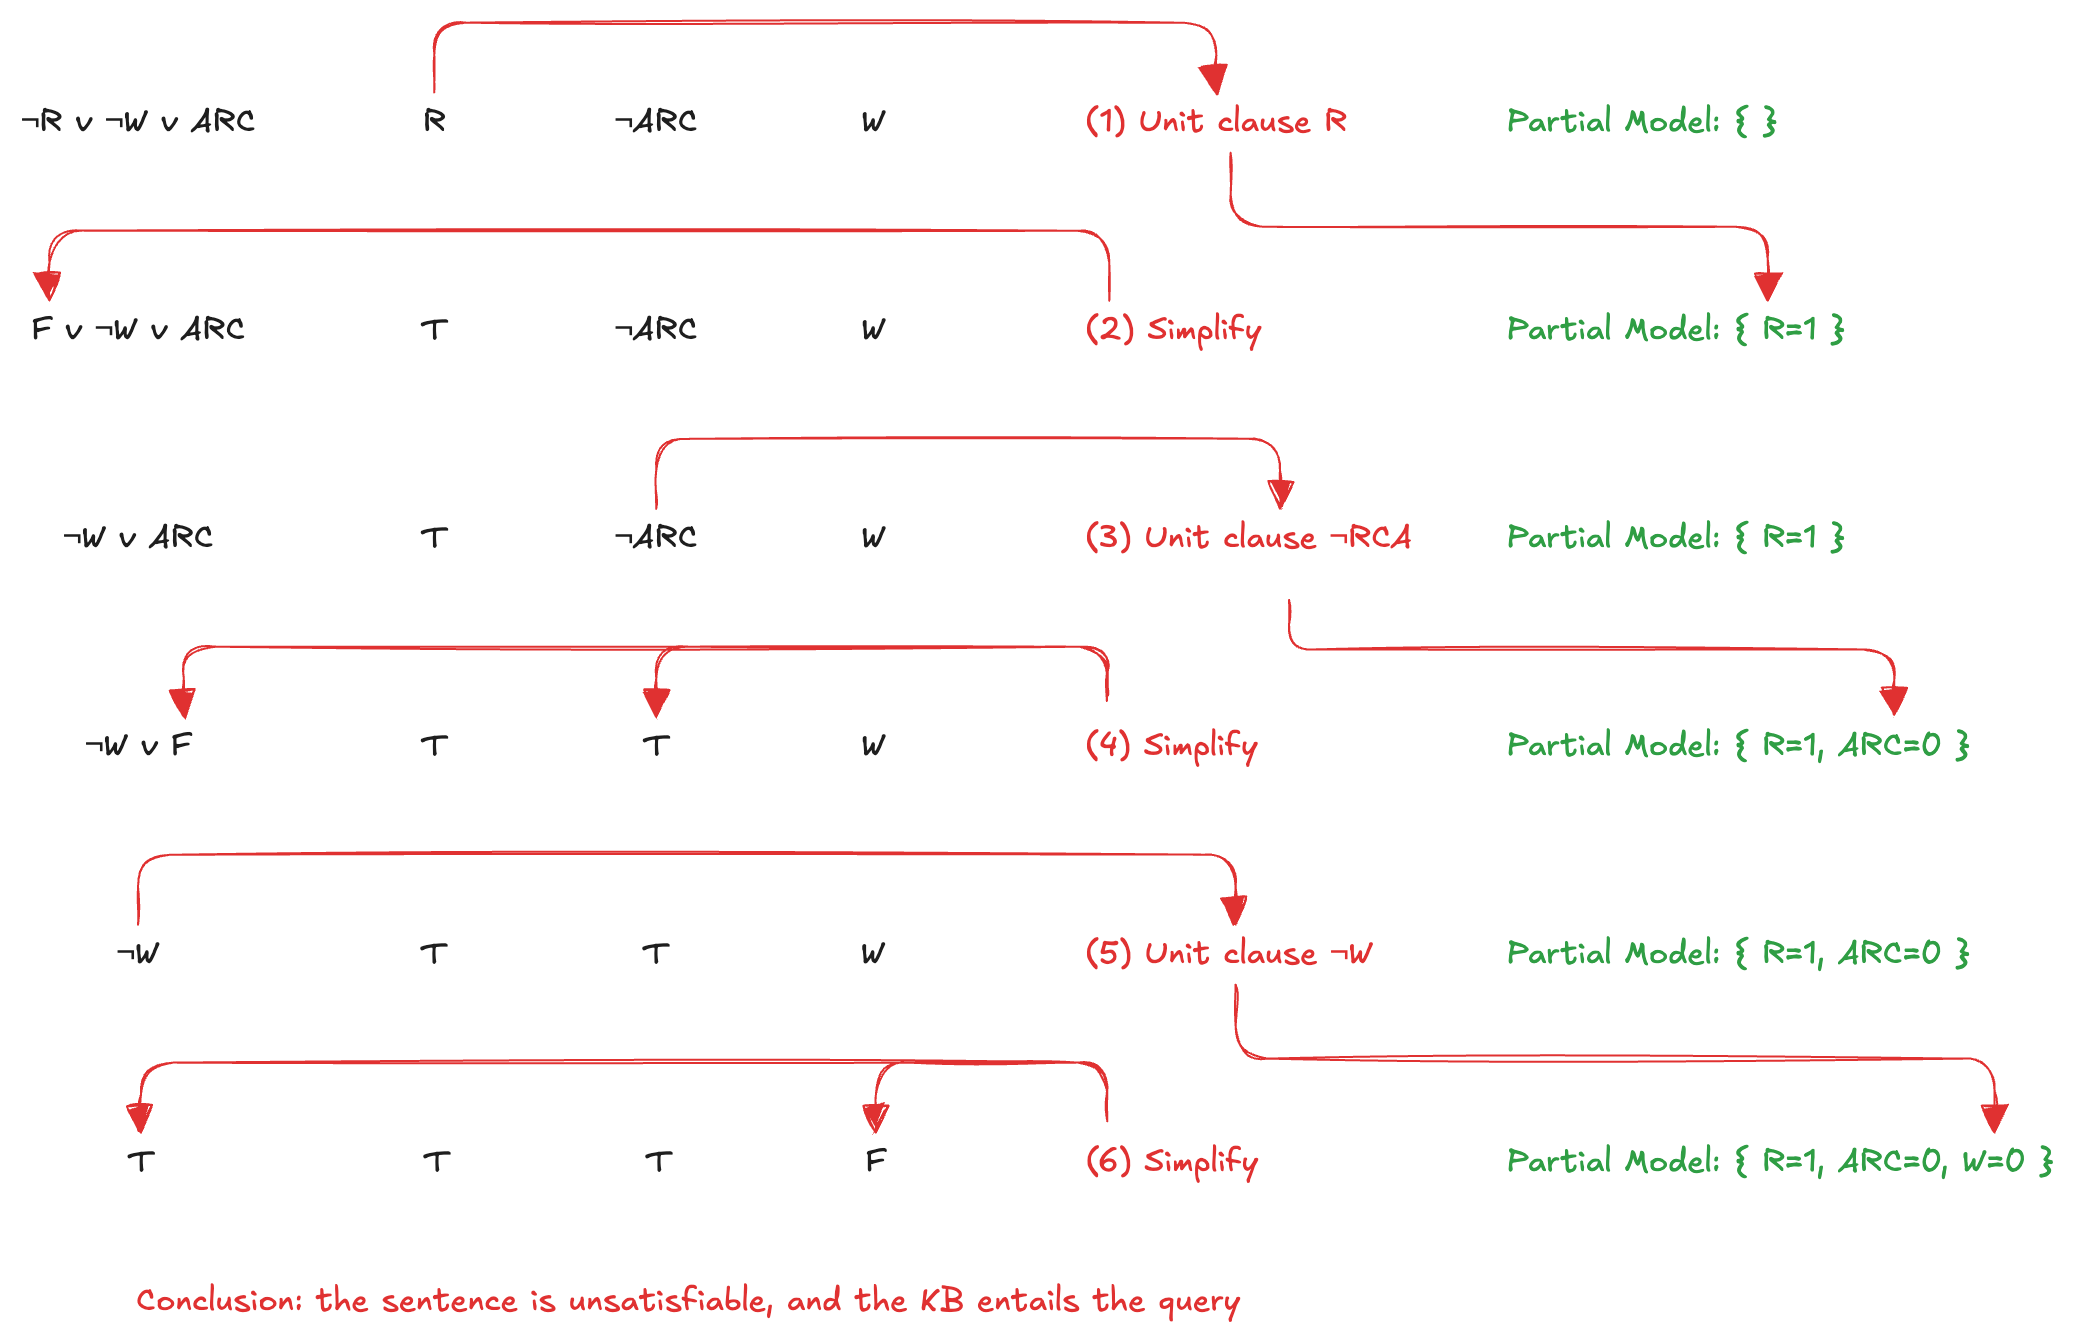

In [684]:
kb = KB()
kb.tell((R & W) >> ARC)
kb.tell(R & ~ARC)

query = ~W

result = dpll_entail(kb, query)

print("KB entails ~W? result:", result)

CNF for DPLL: ((¬R | ¬W | A_RC) & R & ¬A_RC & W)
Current model: {}
Early termination check: None
Unit clause found: R
Current model: {R: True}
Early termination check: None
Unit clause found: ¬A_RC
Current model: {R: True, A_RC: False}
Early termination check: None
Unit clause found: ¬W
Current model: {R: True, A_RC: False, W: False}
Early termination check: False
KB entails ~W? result: True


Let’s consider another classic example. Given the following sentence, we are required to prove that the unicorn is mythical, magical, or horned.

- If the unicorn is mythical, then it is immortal, but if it is not mythical,then it is a mortal mammal
- If the unicorn is either immortal or a mammal, then it is horned
- The unicorn is magical if it is horned

Propositional symbols:
- MY: "The unicorn is mythical
- MR: "The unicorn is mortal"
- MG: "The unicorn is magical"
- MM: "The unicorn is a mammal"
- HR: "The unicorn is horned"

Premises:
- $\displaystyle MY \Rightarrow \lnot MR$
- $\displaystyle \lnot MY \Rightarrow MR \land MM$
- $\displaystyle \lnot MR \lor MM \Rightarrow HR$
- $\displaystyle HR \Rightarrow MG$

First conclusion to prove:
$\displaystyle MY$

We convert each premise into CNF form:
- $\displaystyle \lnot MY \lor \lnot MR$
- $\displaystyle (MY \lor MR) \land (MY \lor MM)$
- $\displaystyle (MR \lor HR) \land (\lnot MM \lor HR)$
- $\displaystyle \lnot HR \lor MG$

Then we create a single sentence by conjoining all premises and the negation of the conclusion:

$\displaystyle (\lnot MY \lor \lnot MR) \land (MY \lor MR) \land (MY \lor MM) \land (MR \lor HR) \land (\lnot MM \lor HR) \land (\lnot HR \lor MG) \land \lnot MY$

We can now apply DPLL:

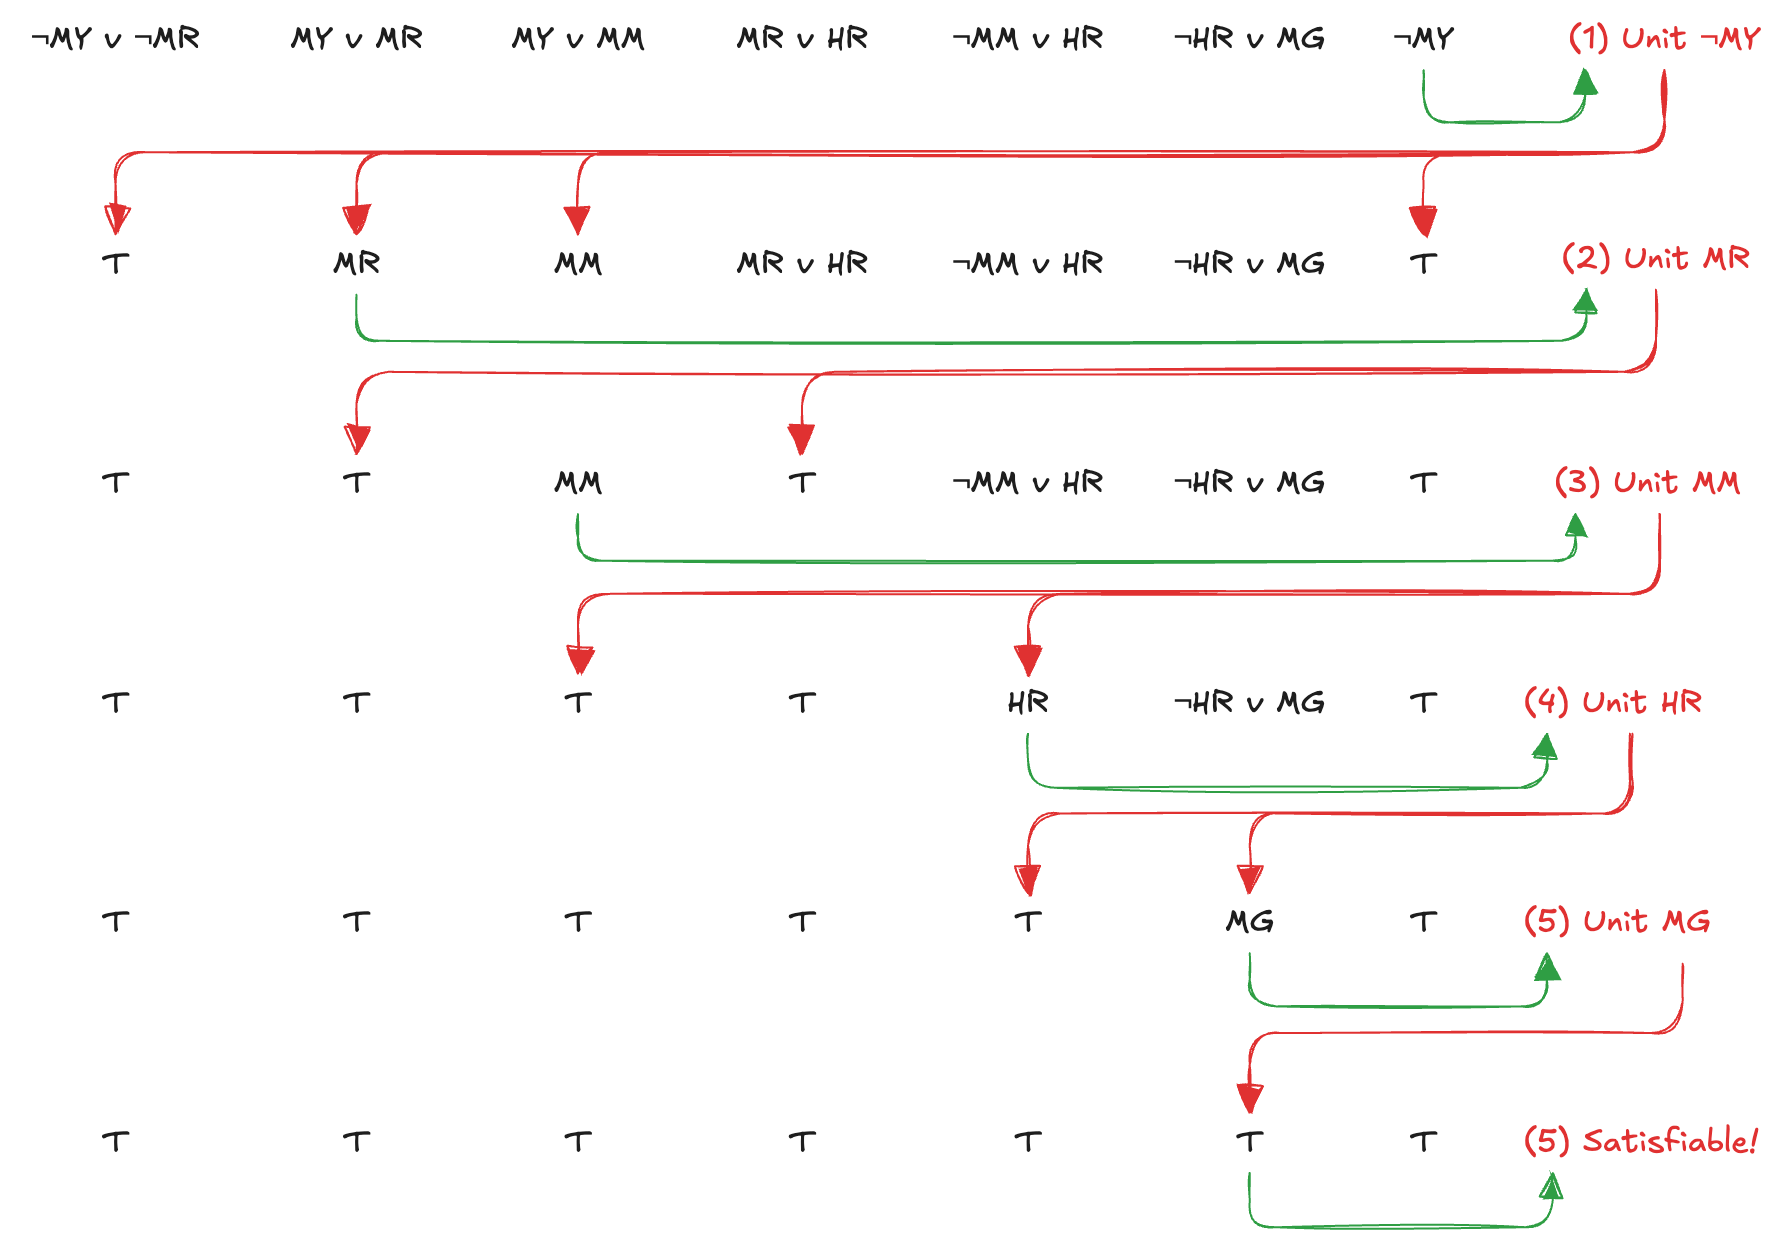

Since the sentence is satisfiable, we can conclude that the knowledge base does not entail that the unicorn is mythical.

In [685]:
# Define atomic propositions
MY = PL_Expr("MY")
MR = PL_Expr("MR")
MG = PL_Expr("MG")
MM = PL_Expr("MM")
HR = PL_Expr("HR")

# Create the knowledge base
kb = KB()
kb.tell(MY >> ~MR)
kb.tell(~MY >> (MR & MM))
kb.tell((~MR | MM) >> HR)
kb.tell(HR >> MG)

# First query: MY
query = MY

# Perform DPLL inference
result = dpll_entail(kb, query)
print(f"\nDoes the knowledge base entail {query}? {'Yes' if result else 'No'}")


CNF for DPLL: ((¬MY | ¬MR) & (MY | MR) & (MY | MM) & (HR | MR) & (HR | ¬MM) & (¬HR | MG) & ¬MY)
Current model: {}
Early termination check: None
Unit clause found: ¬MY
Current model: {MY: False}
Early termination check: None
Unit clause found: MR
Current model: {MY: False, MR: True}
Early termination check: None
Unit clause found: MM
Current model: {MY: False, MR: True, MM: True}
Early termination check: None
Unit clause found: HR
Current model: {MY: False, MR: True, MM: True, HR: True}
Early termination check: None
Unit clause found: MG
Current model: {MY: False, MR: True, MM: True, HR: True, MG: True}
Early termination check: True

Does the knowledge base entail MY? No


Now we can try a  second conclusion:
$\displaystyle MG$

The single sentence is:

$\displaystyle (\lnot MY \lor \lnot MR) \land (MY \lor MR) \land (MY \lor MM) \land (MR \lor HR) \land (\lnot MM \lor HR) \land (\lnot HR \lor MG) \land \lnot MG$

And the applicaton of DPLL provides:

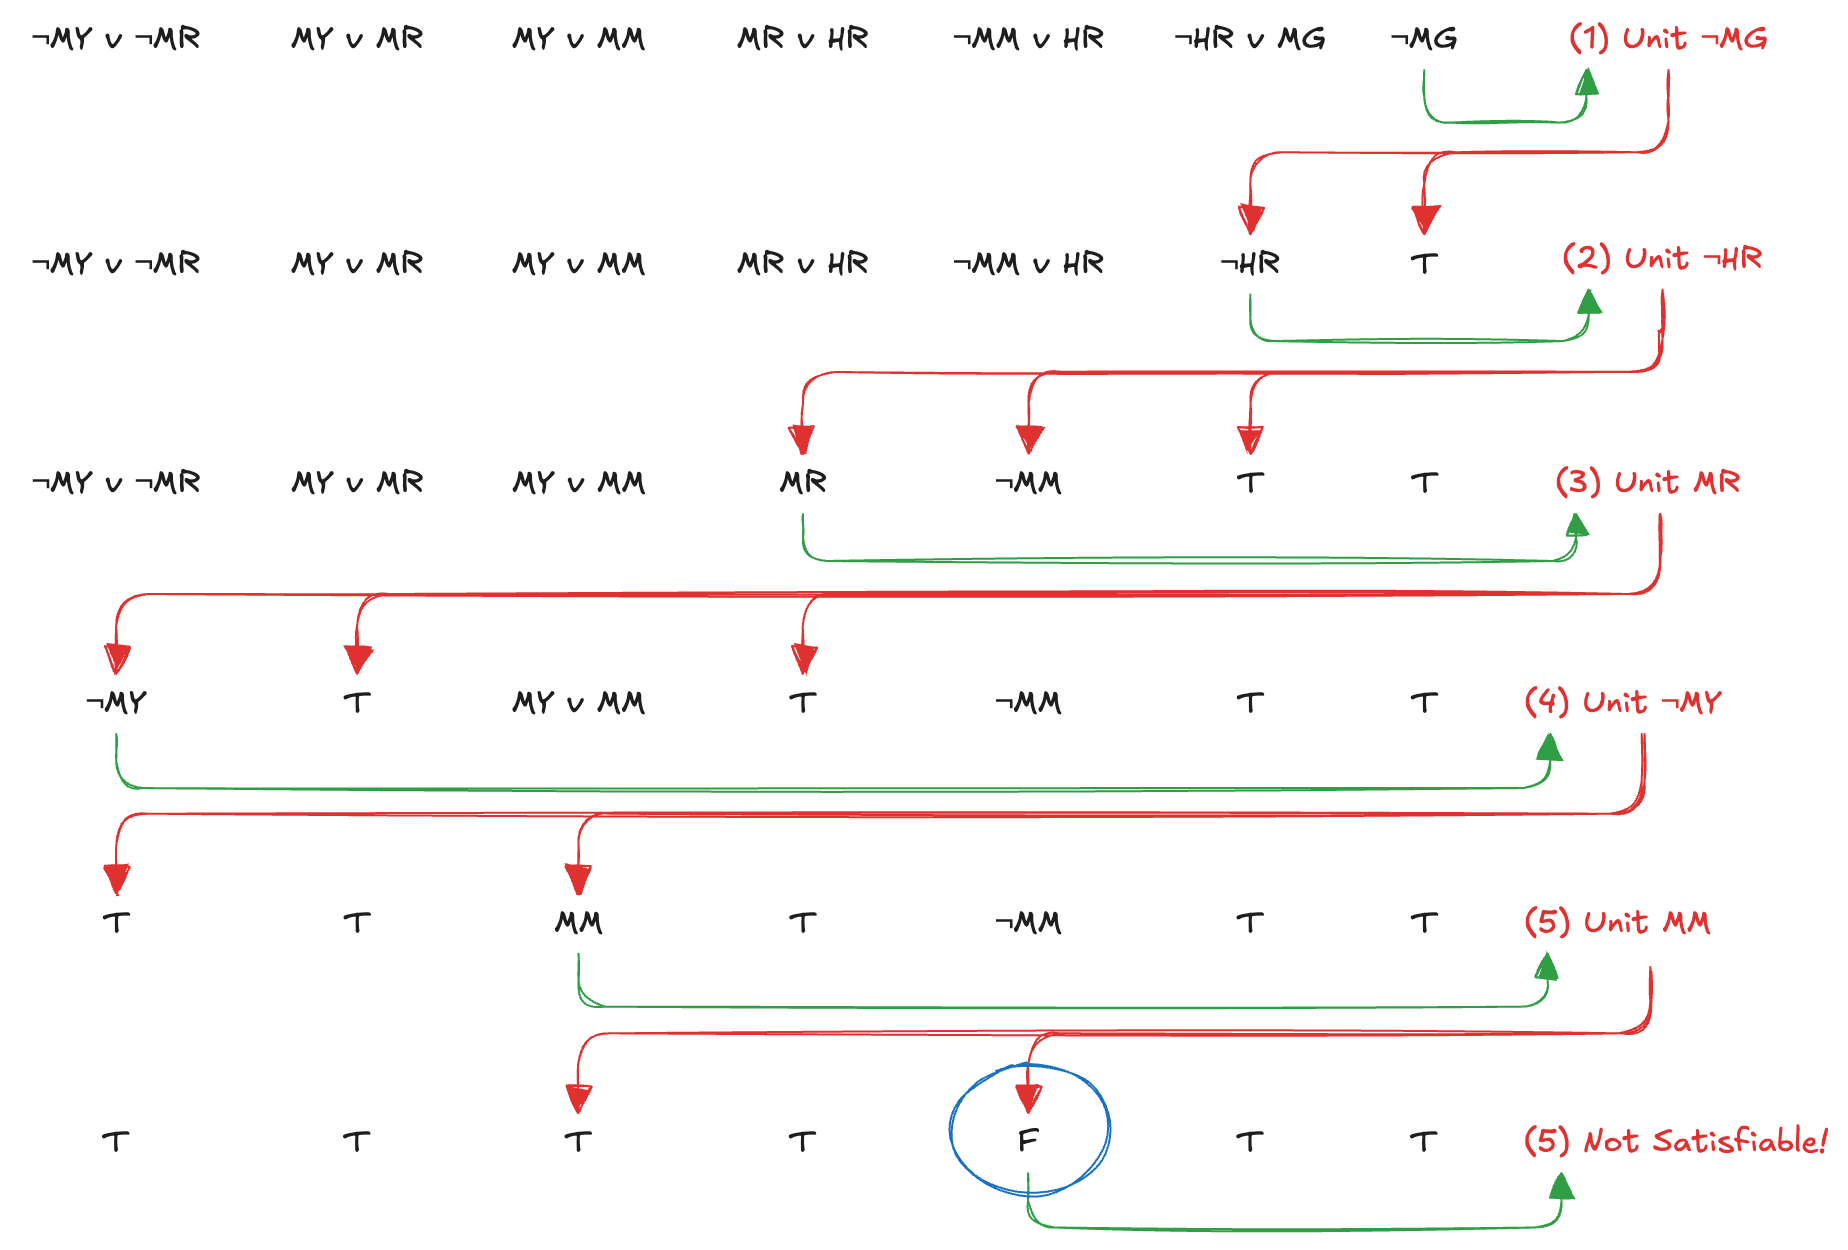

Since the sentence is not satisfiable, we can conclude that the unicorn is indeed magical, as entailed by the knowledge base.

In [686]:
# First query: MG
query = MG

# Perform DPLL inference
result = dpll_entail(kb, query)
print(f"\nDoes the knowledge base entail {query}? {'Yes' if result else 'No'}")

CNF for DPLL: ((¬MY | ¬MR) & (MY | MR) & (MY | MM) & (HR | MR) & (HR | ¬MM) & (¬HR | MG) & ¬MG)
Current model: {}
Early termination check: None
Unit clause found: ¬MG
Current model: {MG: False}
Early termination check: None
Unit clause found: ¬HR
Current model: {MG: False, HR: False}
Early termination check: None
Unit clause found: MR
Current model: {MG: False, HR: False, MR: True}
Early termination check: None
Unit clause found: ¬MY
Current model: {MG: False, HR: False, MR: True, MY: False}
Early termination check: None
Unit clause found: MM
Current model: {MG: False, HR: False, MR: True, MY: False, MM: True}
Early termination check: False

Does the knowledge base entail MG? Yes


Now we can try a third conclusion:
$\displaystyle HR$

The single sentence is:

$\displaystyle (\lnot MY \lor \lnot MR) \land (MY \lor MR) \land (MY \lor MM) \land (MR \lor HR) \land (\lnot MM \lor HR) \land (\lnot HR \lor MG) \land \lnot HR$

And the applicaton of DPLL provides:

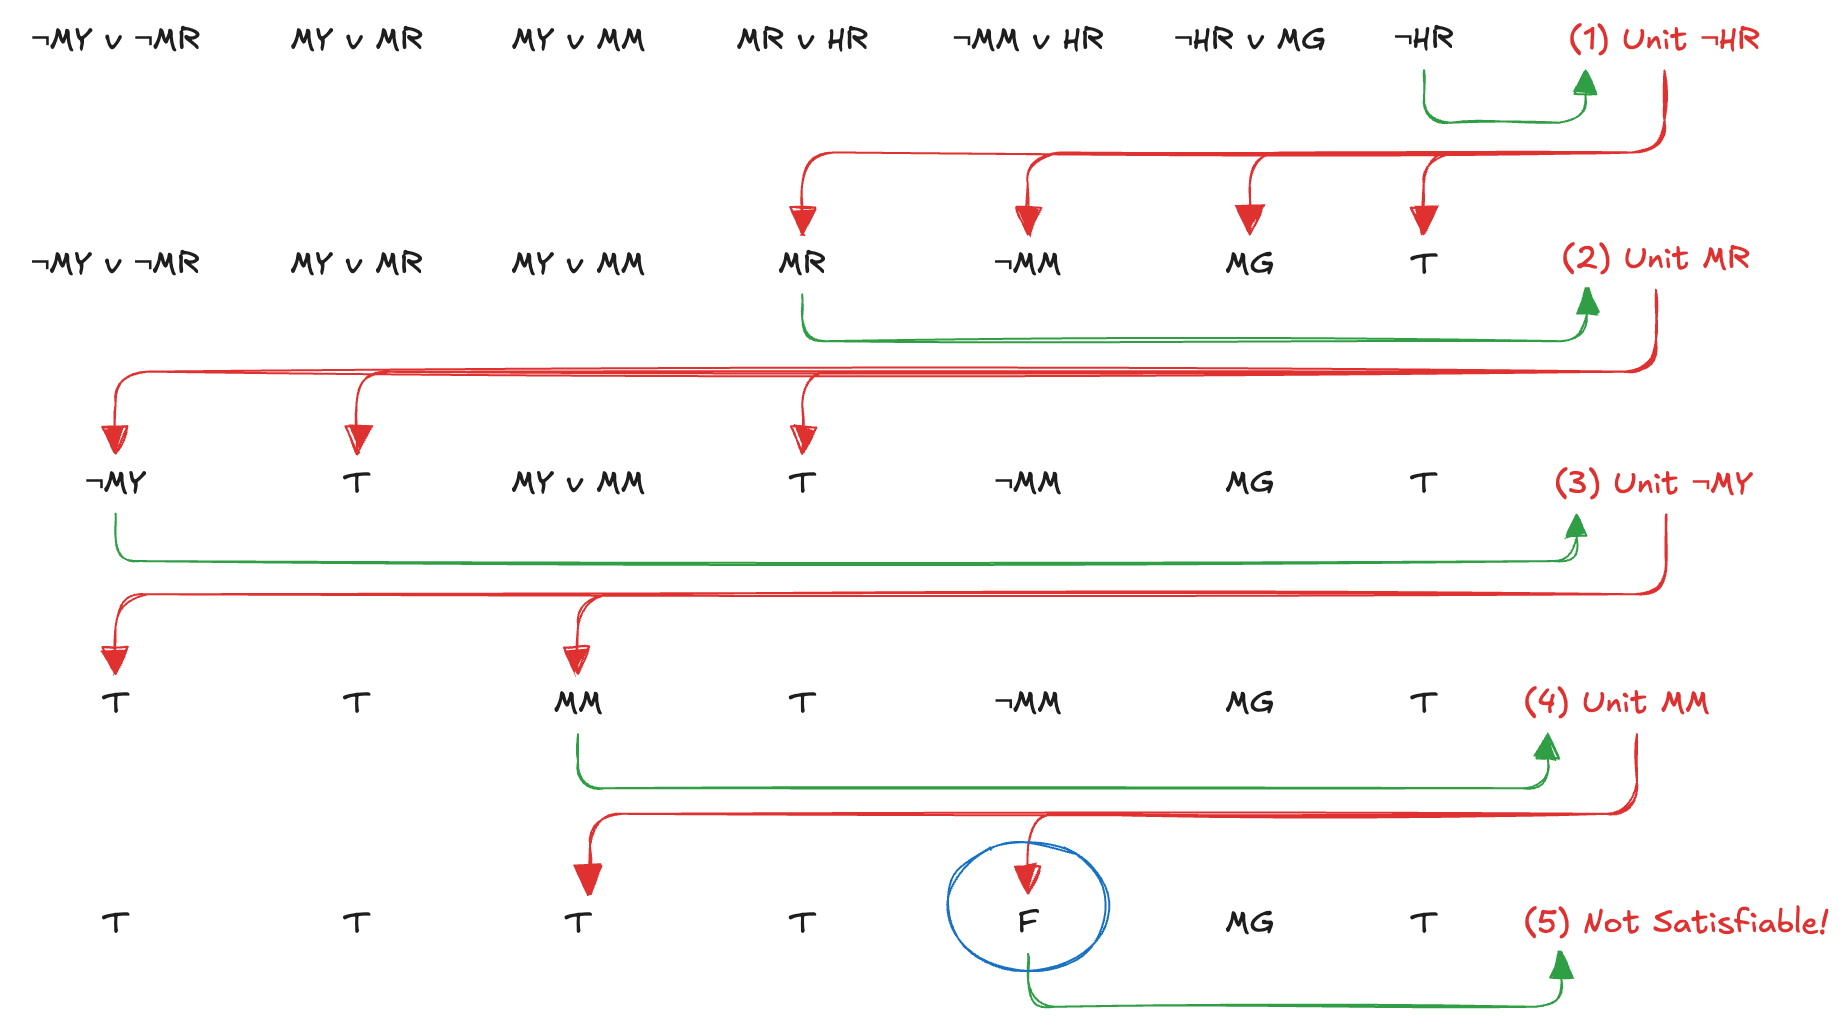

Since the sentence is not satisfiable, we can conclude that the unicorn is indeed horned, as entailed by the knowledge base.

In [687]:
# First query: HR
query = HR

# Perform DPLL inference
result = dpll_entail(kb, query)
print(f"\nDoes the knowledge base entail {query}? {'Yes' if result else 'No'}")

CNF for DPLL: ((¬MY | ¬MR) & (MY | MR) & (MY | MM) & (HR | MR) & (HR | ¬MM) & (¬HR | MG) & ¬HR)
Current model: {}
Early termination check: None
Unit clause found: ¬HR
Current model: {HR: False}
Early termination check: None
Unit clause found: MR
Current model: {HR: False, MR: True}
Early termination check: None
Unit clause found: ¬MY
Current model: {HR: False, MR: True, MY: False}
Early termination check: None
Unit clause found: MM
Current model: {HR: False, MR: True, MY: False, MM: True}
Early termination check: False

Does the knowledge base entail HR? Yes


The implementation of the DPLL provided is just a **basic and naive version** that can handle problems with up to around 100 variables before becoming computationally impractical. Several key improvements allow modern DPLL-based solvers to **scale** to problems involving millions of variables. These improvements include intelligent variable and value ordering strategies, divide-and-conquer techniques to decompose complex formulas, and clause learning mechanisms that cache unsatisfiable subcases as new constraints to avoid redundant work.

### Theorem Proving

Previously, we determined entailment using model checking, by enumerating all possible models and verifying that the sentence held in each one. We then made this process more efficient through a satisfiability-based approach guided by a set of heuristics. Now, we explore an alternative method known as **theorem proving**. This approach **applies rules of inference** directly to the sentences in the knowledge base **to construct a proof of the desired conclusion**, without explicitly considering individual models. When the number of models is large but a short proof exists, theorem proving can be **significantly more efficient** than model checking.

One of the most well-known and widely used inference rules is the **Modus Ponens**, which allows us to infer a conclusion from a conditional statement and its antecedent:

$\displaystyle \frac{A \Rightarrow B, A}{B}$

The notation means if we know that A implies B, and we also know that A is true, then we can conclude that B must be true. For example, "if it is raining, then the ground is wet" and someone tells us "it is raining", then we can safely conclude that "the ground is wet".

Another useful inference rule is the **And-Elimination**, which allows us to extract individual components from a conjunction:

$\displaystyle \frac{A \land B}{A}$

In other words, if we know that both A and B are true, we can safely conclude that A is true. Similarly, we could also conclude B from the same premise.

In general, **all the logical equivalences we’ve seen earlier can be used as inference rules**. When applied to appropriate expressions, they allow us to reason soundly and efficiently, without having to examine all possible models. For instance, the biconditional elimination equivalence:

$\displaystyle (A \Leftrightarrow B) \equiv ((A \Rightarrow B) \land (B \Rightarrow A))$

gives rise to two inference rules:

$\displaystyle \frac{A \Leftrightarrow B}{A \Rightarrow B \land B \Rightarrow A}$   

$\displaystyle \frac{A \Rightarrow B \land B \Rightarrow A}{A \Leftrightarrow B}$   

Let's consider a simple example from the Wumpus World, to illustrate how we can use inference rules to derive conclusions from a knowledge base. We can prove that there is no pit in cell [1,2], given that there is no breeze in cell [1,1]. The reasoning can be formalized as follows:

(1) According to the rules of the Wumpus World, there is a breeze in [1,1] if and only if there is a pit in [1,2] or in [2,1].

$\displaystyle B_{1,1} \Leftrightarrow P_{1,2} \lor P_{2,1}$

(2) By applying the Biconditional elimination rule, we can derive two implications:

$\displaystyle (B_{1,1} \Rightarrow P_{1,2} \lor P_{2,1}) \land (P_{1,2} \lor P_{2,1} \Rightarrow B_{1,1})$

(3) By applying the And-Elimination rule, we can extract the second implication:

$ P_{1,2} \lor P_{2,1} \Rightarrow B_{1,1}$

(4) By applying Contraposition rule:

$\displaystyle \lnot B_{1,1} \Rightarrow \lnot (P_{1,2} \lor P_{2,1})$

(5) By applying the Modus Ponens rule using the percept about the absence of breeze in [1,1]:

$\displaystyle \lnot (P_{1,2} \lor P_{2,1})$

(6) By applying De Morgan's law:

$\displaystyle \lnot P_{1,2} \land \lnot P_{2,1}$

(7) By applying And-Elimination rule, we can conclude:

$\displaystyle \lnot P_{1,2}$

Any **search algorithm** can be used to **find a sequence of inference steps** that form a valid proof. To do this, **we can frame the task as a search problem**, defined as follows:
- **Initial state**: the current knowledge base (set of known sentences)
- **Actions**: applying inference rules to any set of sentences that match the rule’s premises (i.e., the top half of the rule)
- **Result**: add the conclusion (i.e., the bottom half of the rule) to the knowledge base
- **Goal**: reach a state where the sentence we want to prove is present in the knowledge base

Searching for proofs offers an alternative to enumerating models, and in many practical cases, it can be far more efficient. Unlike model checking, which must consider all possible truth assignments (including those involving irrelevant propositions), proof-based reasoning can focus only on the relevant parts of the knowledge base. In our example, the proof makes no mention of certain propositions, such as the presence of a breeze in [2,1], because they are not needed to derive the conclusion. This **selective reasoning** would remain just as efficient even if we added a million more unrelated sentences to the knowledge base. In contrast, a **brute-force truth-table approach** would suffer from exponential growth in the number of models it must evaluate, quickly becoming infeasible.

We will consider three algorithms which implement this search for a proof idea to the propositional logic: **resolution**, **forward chaining** and **backward chaining**.

#### Resolution

We must consider whether the search algorithm is complete (can it always find a proof when the statement is logically entailed?) In general, search algorithms are complete in the sense that they will eventually find any reachable goal. However, **if the set of inference rules is not expressive enough, some valid conclusions may not be reachable at all**. For example, if we omit the rule for eliminating biconditionals, a proof that previously worked may now fail. This highlights a crucial distinction: even **a perfect search strategy cannot compensate for an incomplete set of inference rules**. To address this limitation, we can introduce **a single, powerful inference rule** known as **resolution**, which provides a **complete inference mechanism** for propositional logic. 

The core idea of resolution relies on the fact that any propositional sentence can be converted into CNF (a conjunction of clauses, each of which is a disjunction of literals). Within a clause, if we know that a particular literal is false, we can safely eliminate it. For example, consider the clause:

$\displaystyle A \lor B \lor C$

if we know that $\lnot$ B is true (that is, B is false) then the clause simplifies to:

$\displaystyle A \lor C$

This simplification is valid because B cannot contribute to the truth of the clause. Thus, the clause remains true if and only if at least one of the remaining literals (A or C) is true. We can generalize this with the **resolution rule**. Given two clauses:

$\displaystyle (l_1 \lor l_2 \lor ... \lor l_k)$ 

$\displaystyle  (m_1 \lor m_2 \lor ... \lor m_n)$

where one clause contains a literal $l_i$, and the other contains its **complement** $m_j$, the resolution rule allows us to infer a resolvent: a new clause formed by combining all the literals from both clauses except the complementary pair. The result is:

$\displaystyle l_1 \lor l_2 \lor ... \lor l_{i-1} \lor l_{i+1} \lor ... \lor l_k \lor m_1 \lor m_2 \lor ... \lor m_{j-1} \lor m_{j+1} \lor ... \lor m_n$

This new clause represents what must be true if both original clauses are to be satisfied, and it captures the logical consequence of the resolution step. For example:

$\displaystyle \frac{(A \lor B), \quad (\lnot A \lor \lnot C)}{B \lor \lnot C}$

We can write a function to check whether two literals are complementary, meaning one is the negation of the other:

In [603]:
def is_complementary(l1, l2):

    # Check if both are literals
    if not l1.is_literal() or not l2.is_literal():
        raise ValueError(f"Literals required, got: {l1}, {l2}")

    # Check if the first literal is the negation of the second
    if l1.op == 'NOT' and repr(l1.args[0]) == repr(l2):
        return True

    # Check if the second literal is the negation of the first
    if l2.op == 'NOT' and repr(l2.args[0]) == repr(l1):
        return True
    
    # If neither condition is met, they are not complementary
    return False

There is an important technical detail to consider: the resulting clause from a resolution step **should not contain duplicate literals**. For example, resolving the following two clauses:

$\displaystyle \frac{(A \lor B), \quad (A \lor \lnot B)}{A \lor A}$

yields the clause A $\lor$ A, which is logically equivalent to simply A. The process of removing duplicate literals from a clause is known as **factoring**. Although it is not part of the core resolution rule, it is commonly applied in practice to keep clauses concise, improve efficiency, and eliminate redundant information in the inference process. We write a function to apply the resolution rule to two clauses, producing a new clause that combines the remaining literals after resolving on a complementary pair. Notice that we are using frozenset to represent clauses to ensures order-independent comparison and efficient set operations, which are essential in the resolution algorithm for detecting duplicate clauses, eliminating redundancy, and checking for convergence. Since frozenset is immutable and hashable, it can be stored in sets and used as dictionary keys, making it ideal for tracking derived clauses and preventing infinite loops.

In [629]:
def resolve(clause1, clause2):

    # Extract literals from both clauses
    literals1 = list(clause1.args) if clause1.op == 'OR' else [clause1]
    literals2 = list(clause2.args) if clause2.op == 'OR' else [clause2]
    
    # Iterate through all pairs of literals
    for l1 in literals1:
        for l2 in literals2:

            # Check if the literals are complementary
            if is_complementary(l1, l2):

                # Remove the complementary literals and combine the rest
                filtered1 = [l for l in literals1 if repr(l) != repr(l1)]
                filtered2 = [l for l in literals2 if repr(l) != repr(l2)]
                remaining = frozenset(filtered1 + filtered2)

                # Check for tautology: a literal and its negation in the same clause
                for lit in remaining:
                    if lit.op == 'NOT':
                        if any(repr(lit.args[0]) == repr(other) for other in remaining if other.op != 'NOT'):
                            return None 
                    else:
                        if any(repr(PL_Expr('NOT', lit)) == repr(other) for other in remaining if other.op == 'NOT'):
                            return None
            
                # If no literals left, return contradiction
                if not remaining:
                    return False
                
                # If only one literal left, return it
                if len(remaining) == 1:
                    return next(iter(remaining))
                
                # Otherwise, return a new clause with the remaining literals
                return PL_Expr('OR', *remaining)

    # If no resolvable pair found, return None
    return None

In [631]:
# Define atomic literals
A = PL_Expr('A')
B = PL_Expr('B')
C = PL_Expr('C')
D = PL_Expr('D')

# Example 1 (A | B, ~B | C) resolves to (A | C)
sentence = (A | B, ~B | C)
result = resolve(*sentence)
print(sentence, " becomes ", result)

# Example 2 (A | B, ~A) resolves to (B)
sentence = (A | B, ~A)
result = resolve(*sentence)
print(sentence, " becomes ", result)

# Example 3 (A, ~A) resolves to False (contradiction)
sentence = (A, ~A)
result = resolve(*sentence)
print(sentence, " becomes ", result)

# Example 4 (A | B, C | D) resolves to None
sentence = (A | B, C | D)
result = resolve(*sentence)
print(sentence, " becomes ", result)

# Example 5 (A | ~B, B | C) resolves to (A | C)
sentence = (A | ~B, B | C)
result = resolve(*sentence)
print(sentence, " becomes ", result)

((A | B), (¬B | C))  becomes  (C | A)
((A | B), ¬A)  becomes  B
(A, ¬A)  becomes  False
((A | B), (C | D))  becomes  None
((A | ¬B), (B | C))  becomes  (C | A)


It’s important to note that we can apply resolution to **only one pair of complementary literals at a time**. Trying to resolve more than one pair of literals at once can produce logically invalid results. For example:

$\displaystyle (A \lor \lnot B \lor C) \quad (\lnot A \lor B \lor D)$

Here, we can resolve on the pair A and $\lnot$ A first (or on the pair B and $\lnot$ B):

$\displaystyle (\lnot B \lor C \lor B \lor D)$

Now notice: B $\lor$ $\lnot$ B is a tautology (always true), so this whole clause is logically equivalent to true (i.e., always satisfied). What if we try to resolve on both pairs at once? We would "cancel" both A and $\lnot$ A, and B and $\lnot$ B, leaving us with: 

$\displaystyle C \lor D$

But this is not a valid conclusion from the two original clauses! 

The resolution procedure is **sound** because it only derives conclusions that logically follow from the given premises. It works by identifying and eliminating contradictions (pairs of complementary literals) within clauses. In doing so, it simplifies the knowledge base without introducing any new information. Every step in the process preserves truth, so if the procedure concludes something, that conclusion must already be a consequence of the original statements.

The inference procedures based on resolution works by **using the principle of proof by contradiction**, like the satisfiability-based approach. To show that a knowledge base KB entails a sentence A, we negate A and combine it with KB. The goal is to derive a contradiction, which would imply that the original sentence A must be true in all models where KB is true. The resolution algorithm proceeds as follows:
- First, the sentence whose unsatisfiability we wish to prove is transformed into CNF;
- Next, the resolution rule is repeatedly applied to pairs of clauses that contain complementary literals. Each such pair generates a new clause, which is added to the set if it is not already present;
- This process continues until one of two outcomes occurs:
    - No new clauses can be generated, indicating that the knowledge base does not entail the target sentence.
    - The empty clause is derived, indicating a contradiction and proving that the knowledge base entails the sentence.

Let' consider again the example of Alice and the raincoat, in which we have:

Knowledge base:
- $(R \land W) \Rightarrow A_{RC}$
- $R \land \lnot A_{RC}$

Query:
- $\lnot W$

We convert the knowledge base and the query into CNF form:
- $\displaystyle \lnot R \lor \lnot W \lor A_{RC}$
- $\displaystyle R \land \lnot A_{RC}$
- $\displaystyle \lnot W$

We can now apply the resolution algorithm to prove that the knowledge base entails the query:

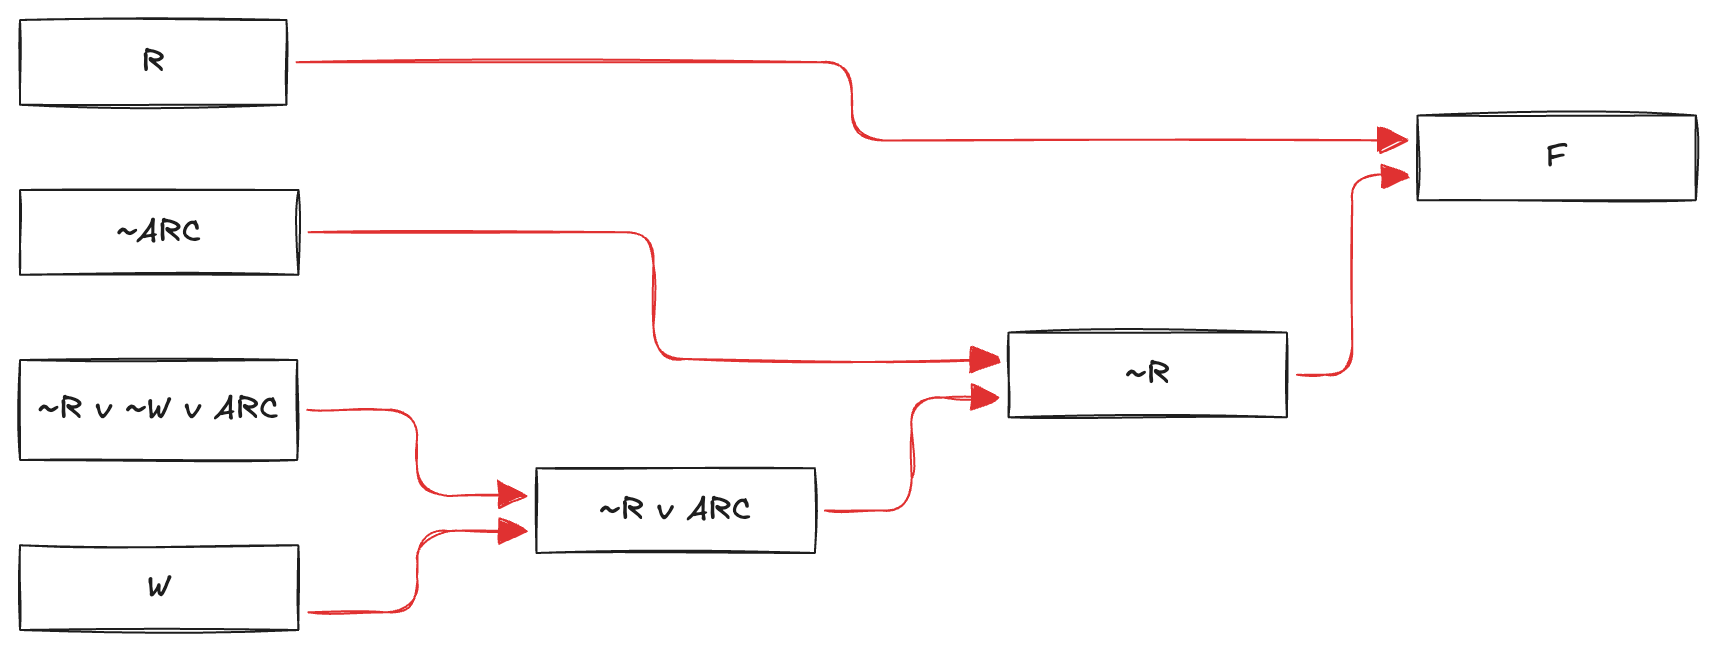

The sentence is unsatisfiable, so we can conclude that the knowledge base entails the query.

Now we can write the complete resolution resolution algorithm. It works by negating the query, combining it with the KB, converting the result to CNF form, and iteratively applying the resolution rule to derive new clauses. If it eventually derives the empty clause (i.e., a contradiction), then the entailment holds. If no new information can be derived and the empty clause is never produced, then the entailment does not hold:

In [632]:
def resolution_entail(kb, query, verbose=True):
    # Step 1: Build CNF for (KB ∧ ¬query)
    all_sentences = kb.sentences + [~query]
    combined = all_sentences[0]
    for s in all_sentences[1:]:
        combined = combined & s

    cnf = to_cnf(combined)

    # Extract initial clauses from CNF
    initial_clauses = list(cnf.args) if cnf.op == 'AND' else [cnf]
    clause_set = set()

    for clause in initial_clauses:
        literals = list(clause.args) if clause.op == 'OR' else [clause]
        clause_set.add(frozenset(literals))

    new = set()

    while True:
        pairs = [(ci, cj) for ci in clause_set for cj in clause_set if ci != cj]

        for (ci, cj) in pairs:
            # Convert frozenset back to PL_Expr for your resolve function
            expr1 = PL_Expr('OR', *ci) if len(ci) > 1 else next(iter(ci))
            expr2 = PL_Expr('OR', *cj) if len(cj) > 1 else next(iter(cj))

            resolvent = resolve(expr1, expr2)

            if resolvent is False:
                if verbose:
                    print(f"Derived empty clause by resolving {expr1} and {expr2}")
                return True

            if resolvent is not None:
                literals = list(resolvent.args) if resolvent.op == 'OR' else [resolvent]
                clause = frozenset(literals)

                if clause not in clause_set and clause not in new:
                    if verbose:
                        print(f"Derived clause: {resolvent}")
                    new.add(clause)

        if not new:
            return False

        clause_set |= new
        new.clear()

We can apply the resolution procedure to a very simple inference in the Wumpus world. When the agent is in [1,1], there is no breeze, so there can be no pits in neighboring squares.
The relevant knowledge base is:

$\displaystyle \text{KB} = (B_{1,1} \Leftrightarrow (P_{1,2} \lor P_{2,1})) \land \lnot B_{1,1}$

and we wish to prove that:

$\displaystyle \lnot P_{1,2}$

We create the conjunction of KB and the negation of the target sentence:

$\displaystyle ((B_{1,1} \Leftrightarrow (P_{1,2} \lor P_{2,1})) \land \lnot B_{1,1}) \land \lnot \lnot P_{1,2}$

We convert it to CNF:

$\displaystyle (\lnot B_{1,1} \lor P_{1,2} \lor P_{2,1}) \land (\lnot P_{1,2} \lor B_{1,1}) \land (\lnot P_{2,1} \lor B_{1,1}) \land \lnot B_{1,1} \land P_{1,2}$

We extract the clauses from the CNF sentence:

$\displaystyle \{(\lnot B_{1,1}, P_{1,2}, P_{2,1}), (\lnot P_{1,2}, B_{1,1}), (\lnot P_{2,1}, B_{1,1}), (\lnot B_{1,1}), (P_{1,2})\}$

We have now five clauses and the resolution algorithm can be applied to couple of them, we can visualize some possibilities:

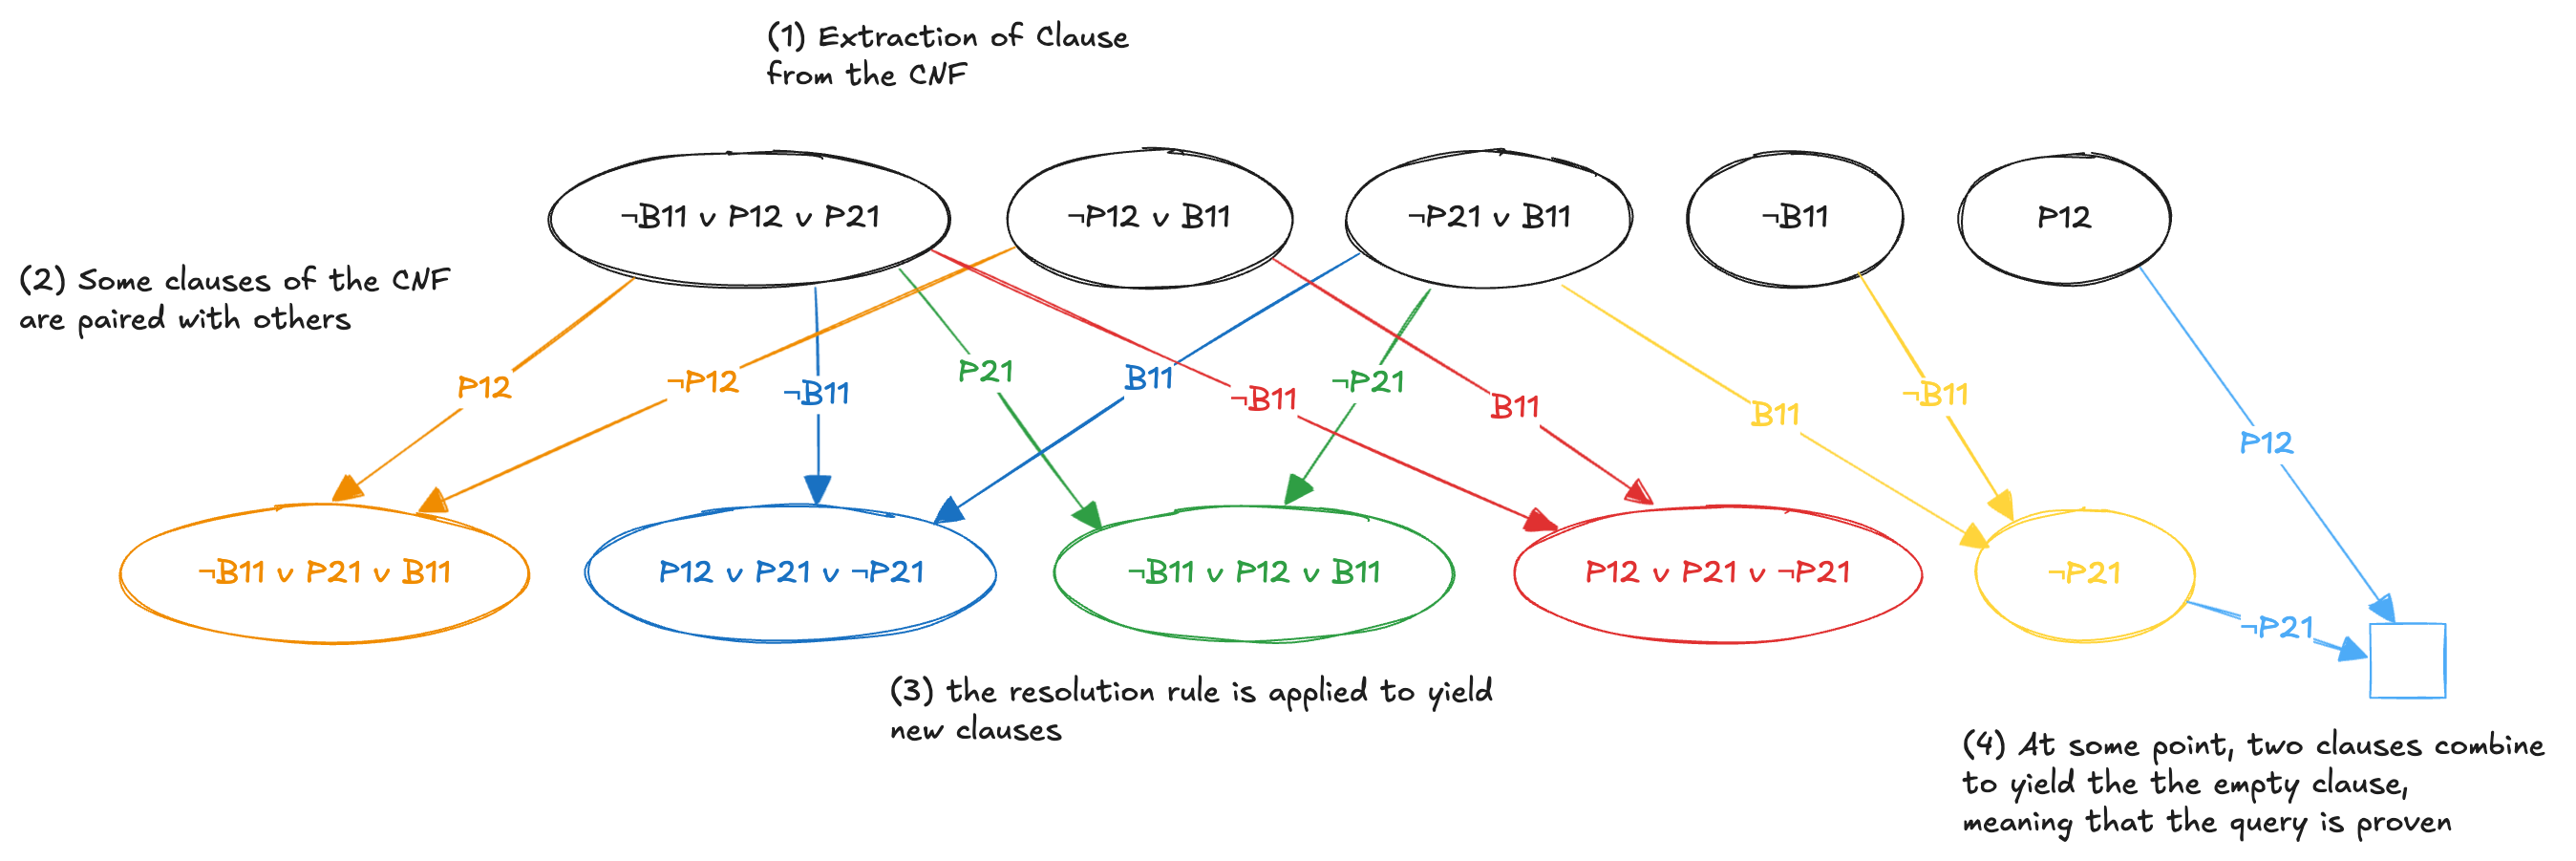

We can see this using the code:

In [634]:
# Define atoms
B11 = PL_Expr("B11")
P12 = PL_Expr("P12")
P21 = PL_Expr("P21")

# Create the knowledge base
kb = KB()
kb.tell(B11 == (P12 | P21))
kb.tell(~B11)

# Define the query
query = ~P12

# Run resolution algorithm
result = resolution_entail(kb, query)

# Print the result
print("Does the KB entail the query?", result)

Derived clause: B11
Derived clause: ¬P12
Derived clause: ¬P21
Derived empty clause by resolving B11 and ¬B11
Does the KB entail the query? True


The resolution inference procedure is **complete** for propositional logic. This means that if a sentence is logically entailed by a knowledge base, the resolution algorithm is guaranteed to derive a contradiction from the knowledge base combined with the negation of the query in a finite number of steps. This result is grounded in the resolution theorem, which states that if a set of clauses S is unsatisfiable, then its resolution closure (the set of all clauses derivable from S through repeated application of the resolution rule) must contain the empty clause. This confirms the completeness of resolution: if the knowledge base contradicts the negated query, resolution will eventually find that contradiction. To build some intuition: imagine we are solving a logic puzzle where some of the given facts are in conflict. By systematically applying the resolution rule (eliminating pairs of complementary literals) we simplify the facts step by step. If a contradiction exists among the original facts, this process will eventually reduce them to an empty clause, representing a logical falsehood. It is also important to note that the resolution closure is **finite**: because the set of symbols is finite and duplicate literals are eliminated through factoring, there are only finitely many distinct clauses that can be formed. Thus, the algorithm is guaranteed to terminate. 

#### Forward chaining

In many practical settings, the full generality of resolution is unnecessary. Real-world knowledge bases often adhere to **syntactic restrictions** that enable more efficient inference procedures. One such restriction is the **definite clause**, a **disjunction of literals with exactly one positive literal**. For example:

$\displaystyle \lnot L_{1,1} \lor \lnot \text{Breeze} \lor B_{1,1}$

is a definite clause, whereas

$\displaystyle \lnot B_{1,1} \lor P_{1,2} \lor P_{2,1}$

is not, because it contains two positive literals.

A broader category is the **Horn clause**, which is **a disjunction with at most one positive literal**. This includes both definite clauses and **goal clauses** (those with no positive literals). Horn clauses are **closed under resolution**, since resolving two Horn clauses (each with at most one positive literal) always produces a new clause with at most one positive literal, which satisfies the definition of a Horn clause. This property is crucial because it ensures that **resolution-based inference remains within the Horn class**, allowing for efficient and tractable reasoning (e.g., linear-time satisfiability checking for propositional Horn logic).

Horn clauses also have a **natural implicational form**: every definite clause can be rewritten as an implication where the body is a conjunction of positive literals and the head is a single positive literal. For instance:

$\displaystyle (L_{1,1} \land \text{Breeze}) \Rightarrow B_{1,1}$

This form makes definite clauses **intuitive and easier to manipulate**. A Horn clause with only a single positive literal and no body is called a **fact**.

The **forward-chaining algorithm** checks whether a single proposition symbol (the query) is entailed by a knowledge base composed of definite clauses. It **starts with the known facts** (positive literals explicitly stated in the knowledge base) and **repeatedly applies implications**: if all the premises of a rule are known, the conclusion is inferred and added to the set of known facts. For example, if 

$\displaystyle L_{1,1}$ and $\text{Breeze}$ are known 

and 

$\displaystyle (L_{1,1} \land \text{Breeze}) \Rightarrow B_{1,1}$ is in the KB

then

$\displaystyle B_{1,1}$ can be added. 

This process continues until the query q is added or until no further inferences can be made. 

We can write the algorithm, t uses a structure called the agenda, which holds facts whose consequences have not yet been processed. Each time a fact is removed from the agenda, the algorithm inspects all implications where that fact appears as a premise. To manage this efficiently, the algorithm maintains a count table that tracks how many premises of each rule are still unproven. When a fact is processed, the count is decremented for every rule where the fact appears in the body. If a rule’s count reaches zero, it means all its premises are satisfied, so its conclusion can be inferred and added to the agenda. To avoid redundant work and infinite loops (especially in the presence of circular rules like P -> Q and Q -> P), the algorithm also keeps an inferred list to ensure that each fact is processed only once. This process continues until either the query is derived, or the agenda becomes empty, indicating that no further inferences can be made:

In [643]:
def forward_chaining_entail(kb, query, verbose=True):
    
    # Set of already inferred facts
    inferred = set()

    # The list of facts to be considered
    agenda = []

    # The list of rules
    rules = []

    # The number of premises for each rule
    count = {}

    # Populate agenda and rules
    for clause in kb.sentences:

        # If the clause has an implication, it is a rule
        if clause.op == 'IMPLIES':
            head = clause.args[1]
            body = clause.args[0]
            if body.op == 'AND':
                premises = list(body.args)
            else:
                premises = [body]
            rules.append((head, premises))
            key = (head, tuple(premises))
            count[key] = len(premises)

        # Otherwise, it is a rule    
        else:
            inferred.add(clause)
            agenda.append(clause)

    if verbose: print("Rules:", rules)

    # Forward chaining loop
    while agenda:

        if verbose: print("Agenda:", agenda)
        if verbose: print("Inferred facts:", inferred)
        
        # Pop a fact from the agenda
        p = agenda.pop(0)

        if verbose: print("Considering fact:", p)

        # If we find the query, we can stop
        if repr(p) == repr(query):
            if verbose: print("Found the query in the inferred facts!")
            return True

        # Check if the fact is a premise of any rule
        for (head, premises) in rules:
            if any(repr(premise) == repr(p) for premise in premises):
                key = (head, tuple(premises))

                # Decrease the count of premises for this rule
                count[key] -= 1
                
                # If all premises are satisfied, we can infer a new fact
                # if it has not been inferred yet
                if count[key] == 0 and head not in inferred:
                    if verbose: print("Inferred new fact: ", head)
                    inferred.add(head)
                    agenda.append(head)
    
    # If we exhaust the agenda without finding the query, it is not entailed
    if verbose: print("Exhausted agenda without finding the query.")
    return False

To better understand the algorithm, we can represent the problem as an **AND–OR graph**. In this graph, arcs joining multiple edges represent conjunctions (AND), while individual edges without arcs represent disjunctions (OR). Let’s consider the following knowledge base of Horn clauses, which includes two initial facts:

$\displaystyle P \Rightarrow Q$      
$\displaystyle L \land M \Rightarrow P$     
$\displaystyle B \land L \Rightarrow M$     
$\displaystyle A \land P \Rightarrow L$      
$\displaystyle A \land B \Rightarrow L$     
$\displaystyle A$     
$\displaystyle B$       

And the query is: $\displaystyle Q$

It is easy to see how forward chaining works in the graph:

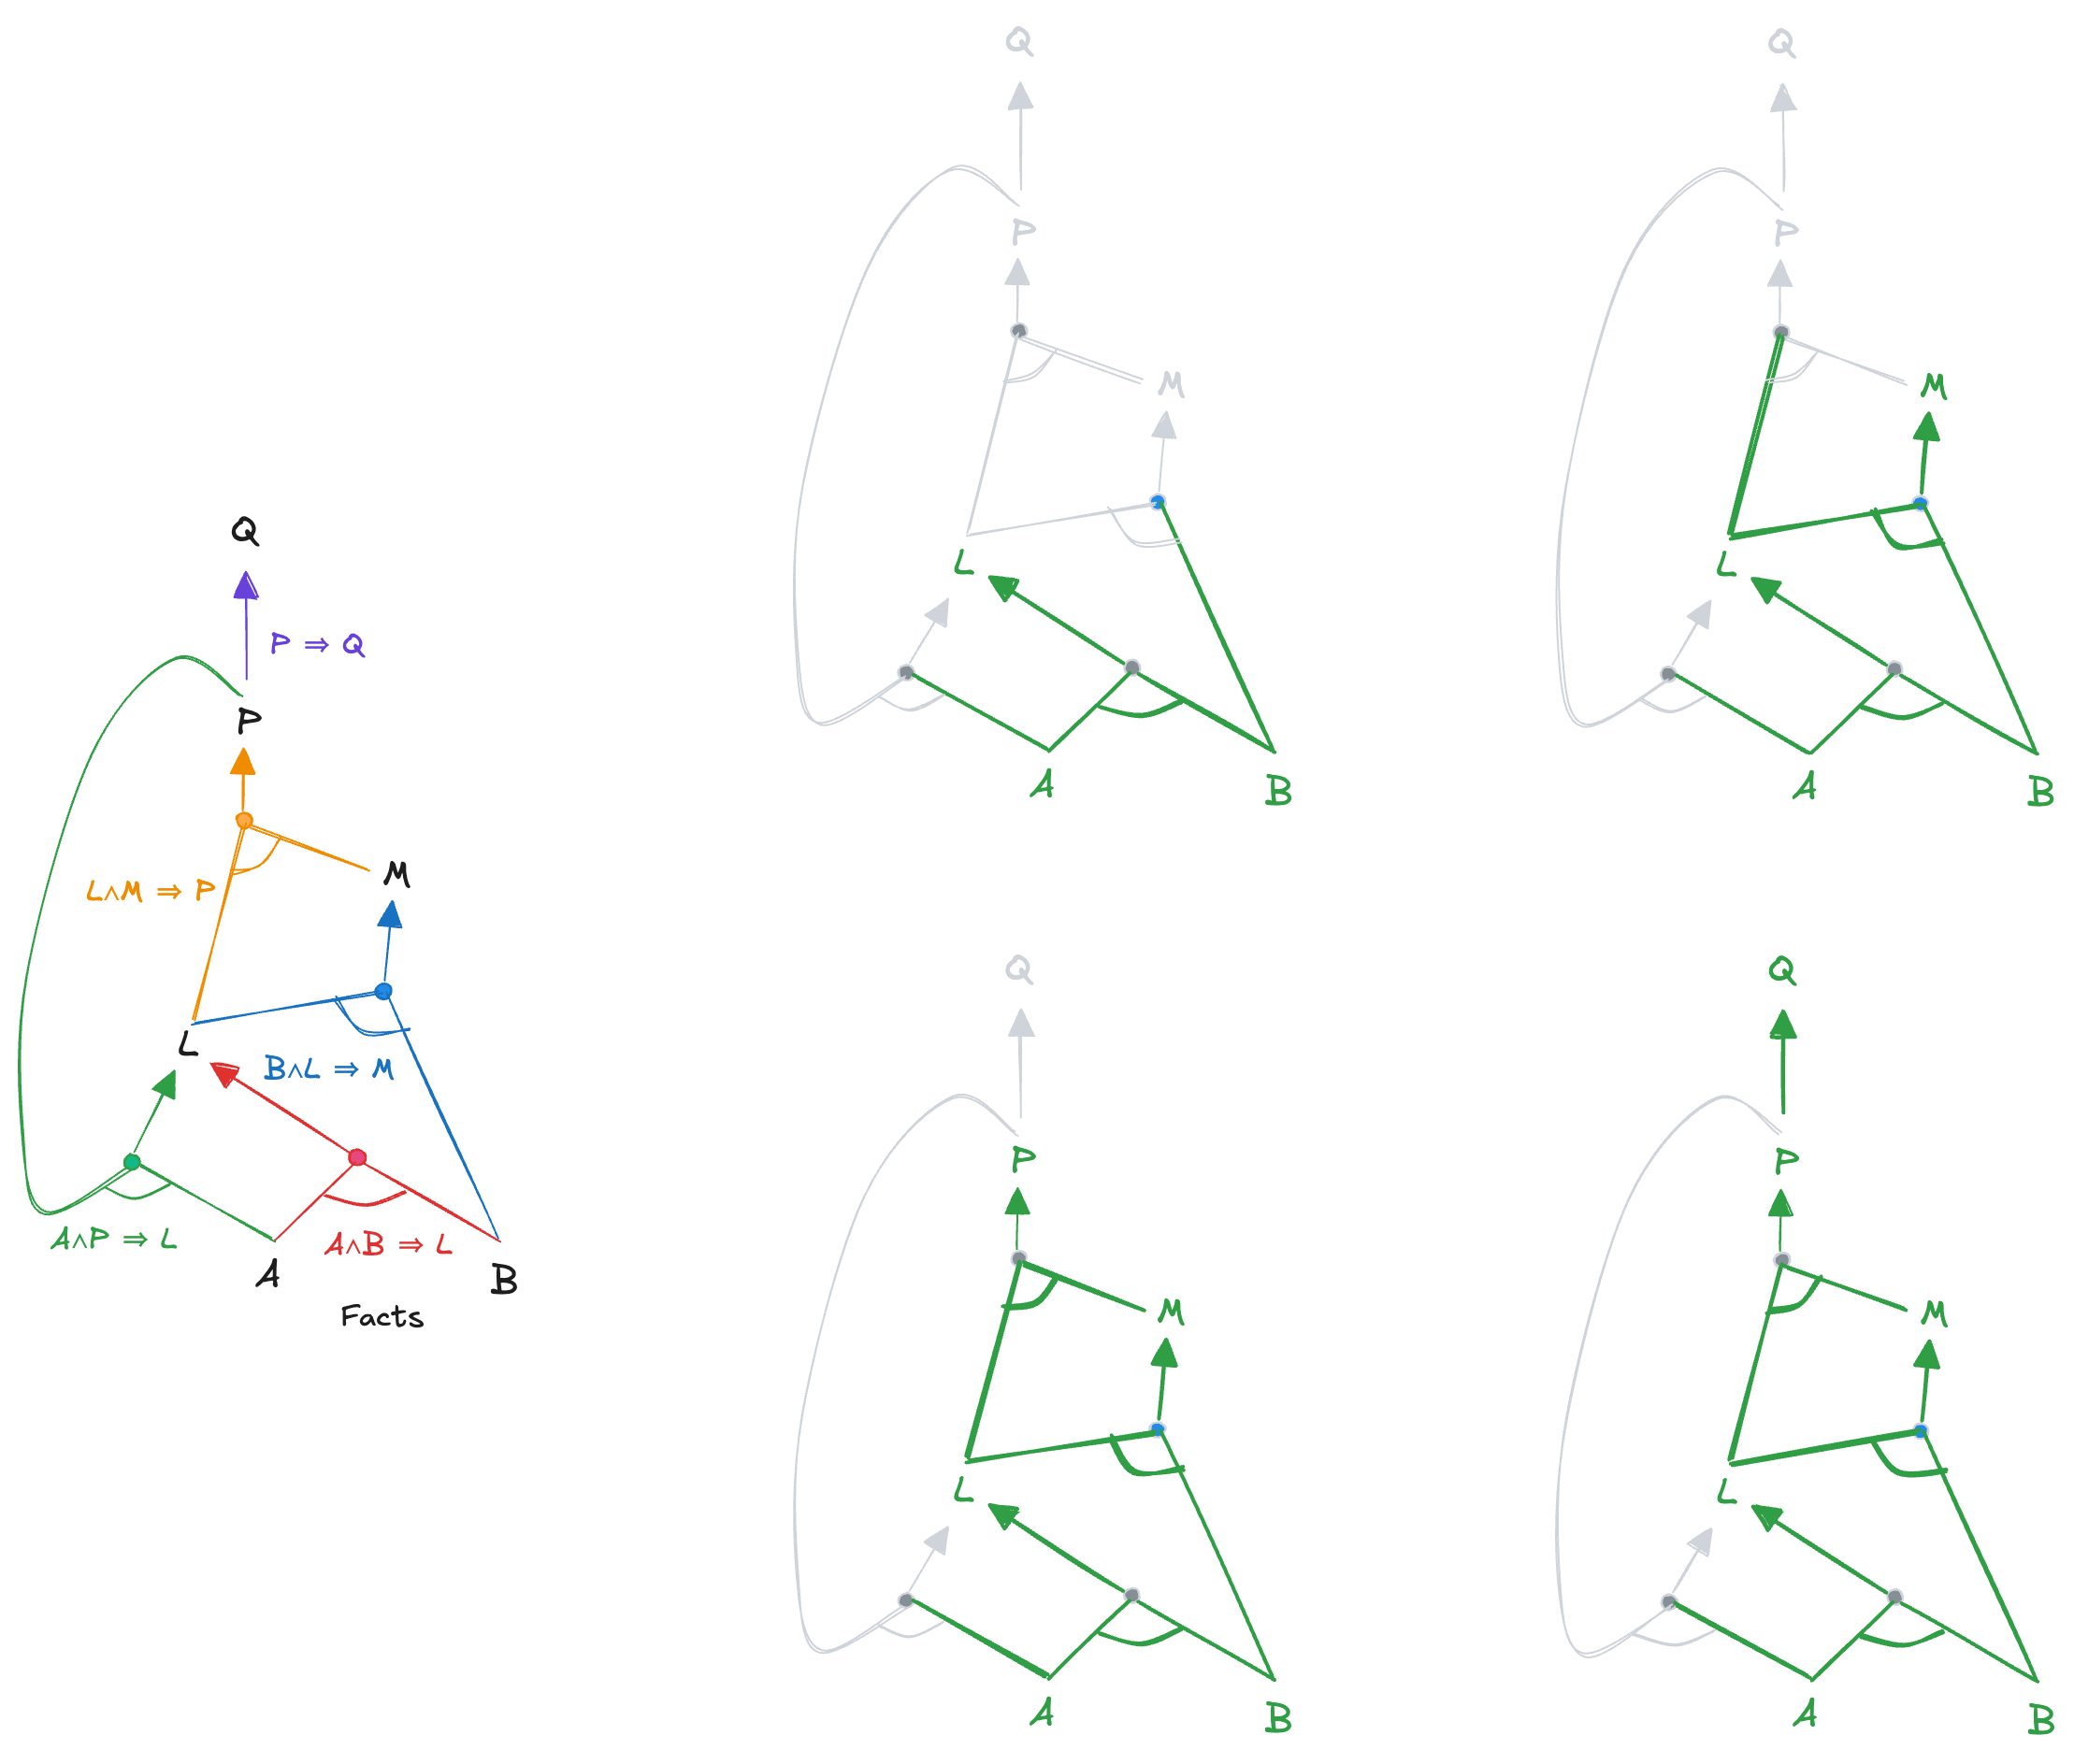

The known leaves (A and B) are set, and inference propagates up the graph as far as possible. Wherever a conjunction appears, the propagation waits until all the conjuncts are known before proceeding.

In [645]:
# Define atomic sentences
A = PL_Expr("A")
B = PL_Expr("B")
L = PL_Expr("L")
M = PL_Expr("M")
P = PL_Expr("P")
Q = PL_Expr("Q")

# Define the knowledge base
kb = KB()

# Add facts to the knowledge base
kb.tell(A)                          
kb.tell(B)

# Add rules to the knowledge base
kb.tell((A & P) >> L)               
kb.tell((A & B) >> L)               
kb.tell((B & L) >> M)               
kb.tell((L & M) >> P)               
kb.tell(P >> Q)      

# Perform forward chaining to check if P can be inferred
result = forward_chaining_entail(kb, Q)

print(f"Does the knowledge base entail {Q}? {'Yes' if result else 'No'}")

Rules: [(L, [A, P]), (L, [A, B]), (M, [B, L]), (P, [L, M]), (Q, [P])]
Agenda: [A, B]
Inferred facts: {B, A}
Considering fact: A
Agenda: [B]
Inferred facts: {B, A}
Considering fact: B
Inferred new fact:  L
Agenda: [L]
Inferred facts: {L, B, A}
Considering fact: L
Inferred new fact:  M
Agenda: [M]
Inferred facts: {L, B, M, A}
Considering fact: M
Inferred new fact:  P
Agenda: [P]
Inferred facts: {P, L, A, B, M}
Considering fact: P
Inferred new fact:  Q
Agenda: [Q]
Inferred facts: {P, Q, L, A, B, M}
Considering fact: Q
Found the query in the inferred facts!
Does the knowledge base entail Q? Yes


The forward-chaining algorithm is **sound** because **it only derives conclusions when all their premises are known to be true**. It is also **complete for definite clauses**, meaning that it will **derive every entailed conclusion by exhaustively applying all applicable rules**. If the query is logically implied by the knowledge base, there must exist a chain of rules leading to it, and the algorithm is guaranteed to eventually follow that chain and derive the conclusion. However, this guarantee of completeness **holds only for definite clauses** (rules with exactly one positive literal and no disjunctions or negated heads). For general propositional logic, where clauses may contain arbitrary combinations of literals, forward chaining is not complete.

Forward chaining illustrates the broader idea of **data-driven reasoning**, where **inference begins with the known facts and proceeds outward**. This is particularly effective in agents that must react to new percepts without a specific goal in mind. For example, in the Wumpus World, an agent might incrementally add percepts to its knowledge base and trigger new inferences through forward chaining as each new fact is introduced. **Humans also engage in this kind of reasoning**: if we hear rain while indoors, we may infer that the picnic is likely canceled. However, we would not conclude that the seventeenth petal of the largest rose in my neighbor’s garden is now wet. Like intelligent agents, humans **naturally limit forward chaining** to avoid being overwhelmed by **irrelevant inferences**.

#### Backward chaining

The **backward-chaining algorithm** works by **reasoning backward from the query**. If the query is already known to be true (i.e., it is a fact), no further inference is needed. Otherwise, the algorithm **searches the knowledge base for implications whose conclusion matches the query**. For each such implication, it attempts to prove all of its premises recursively using backward chaining. If it succeeds in proving the premises of any rule, then the query is considered true. This process continues recursively, working backward through the chain of implications, until it reaches known facts that serve as the foundation for a proof:

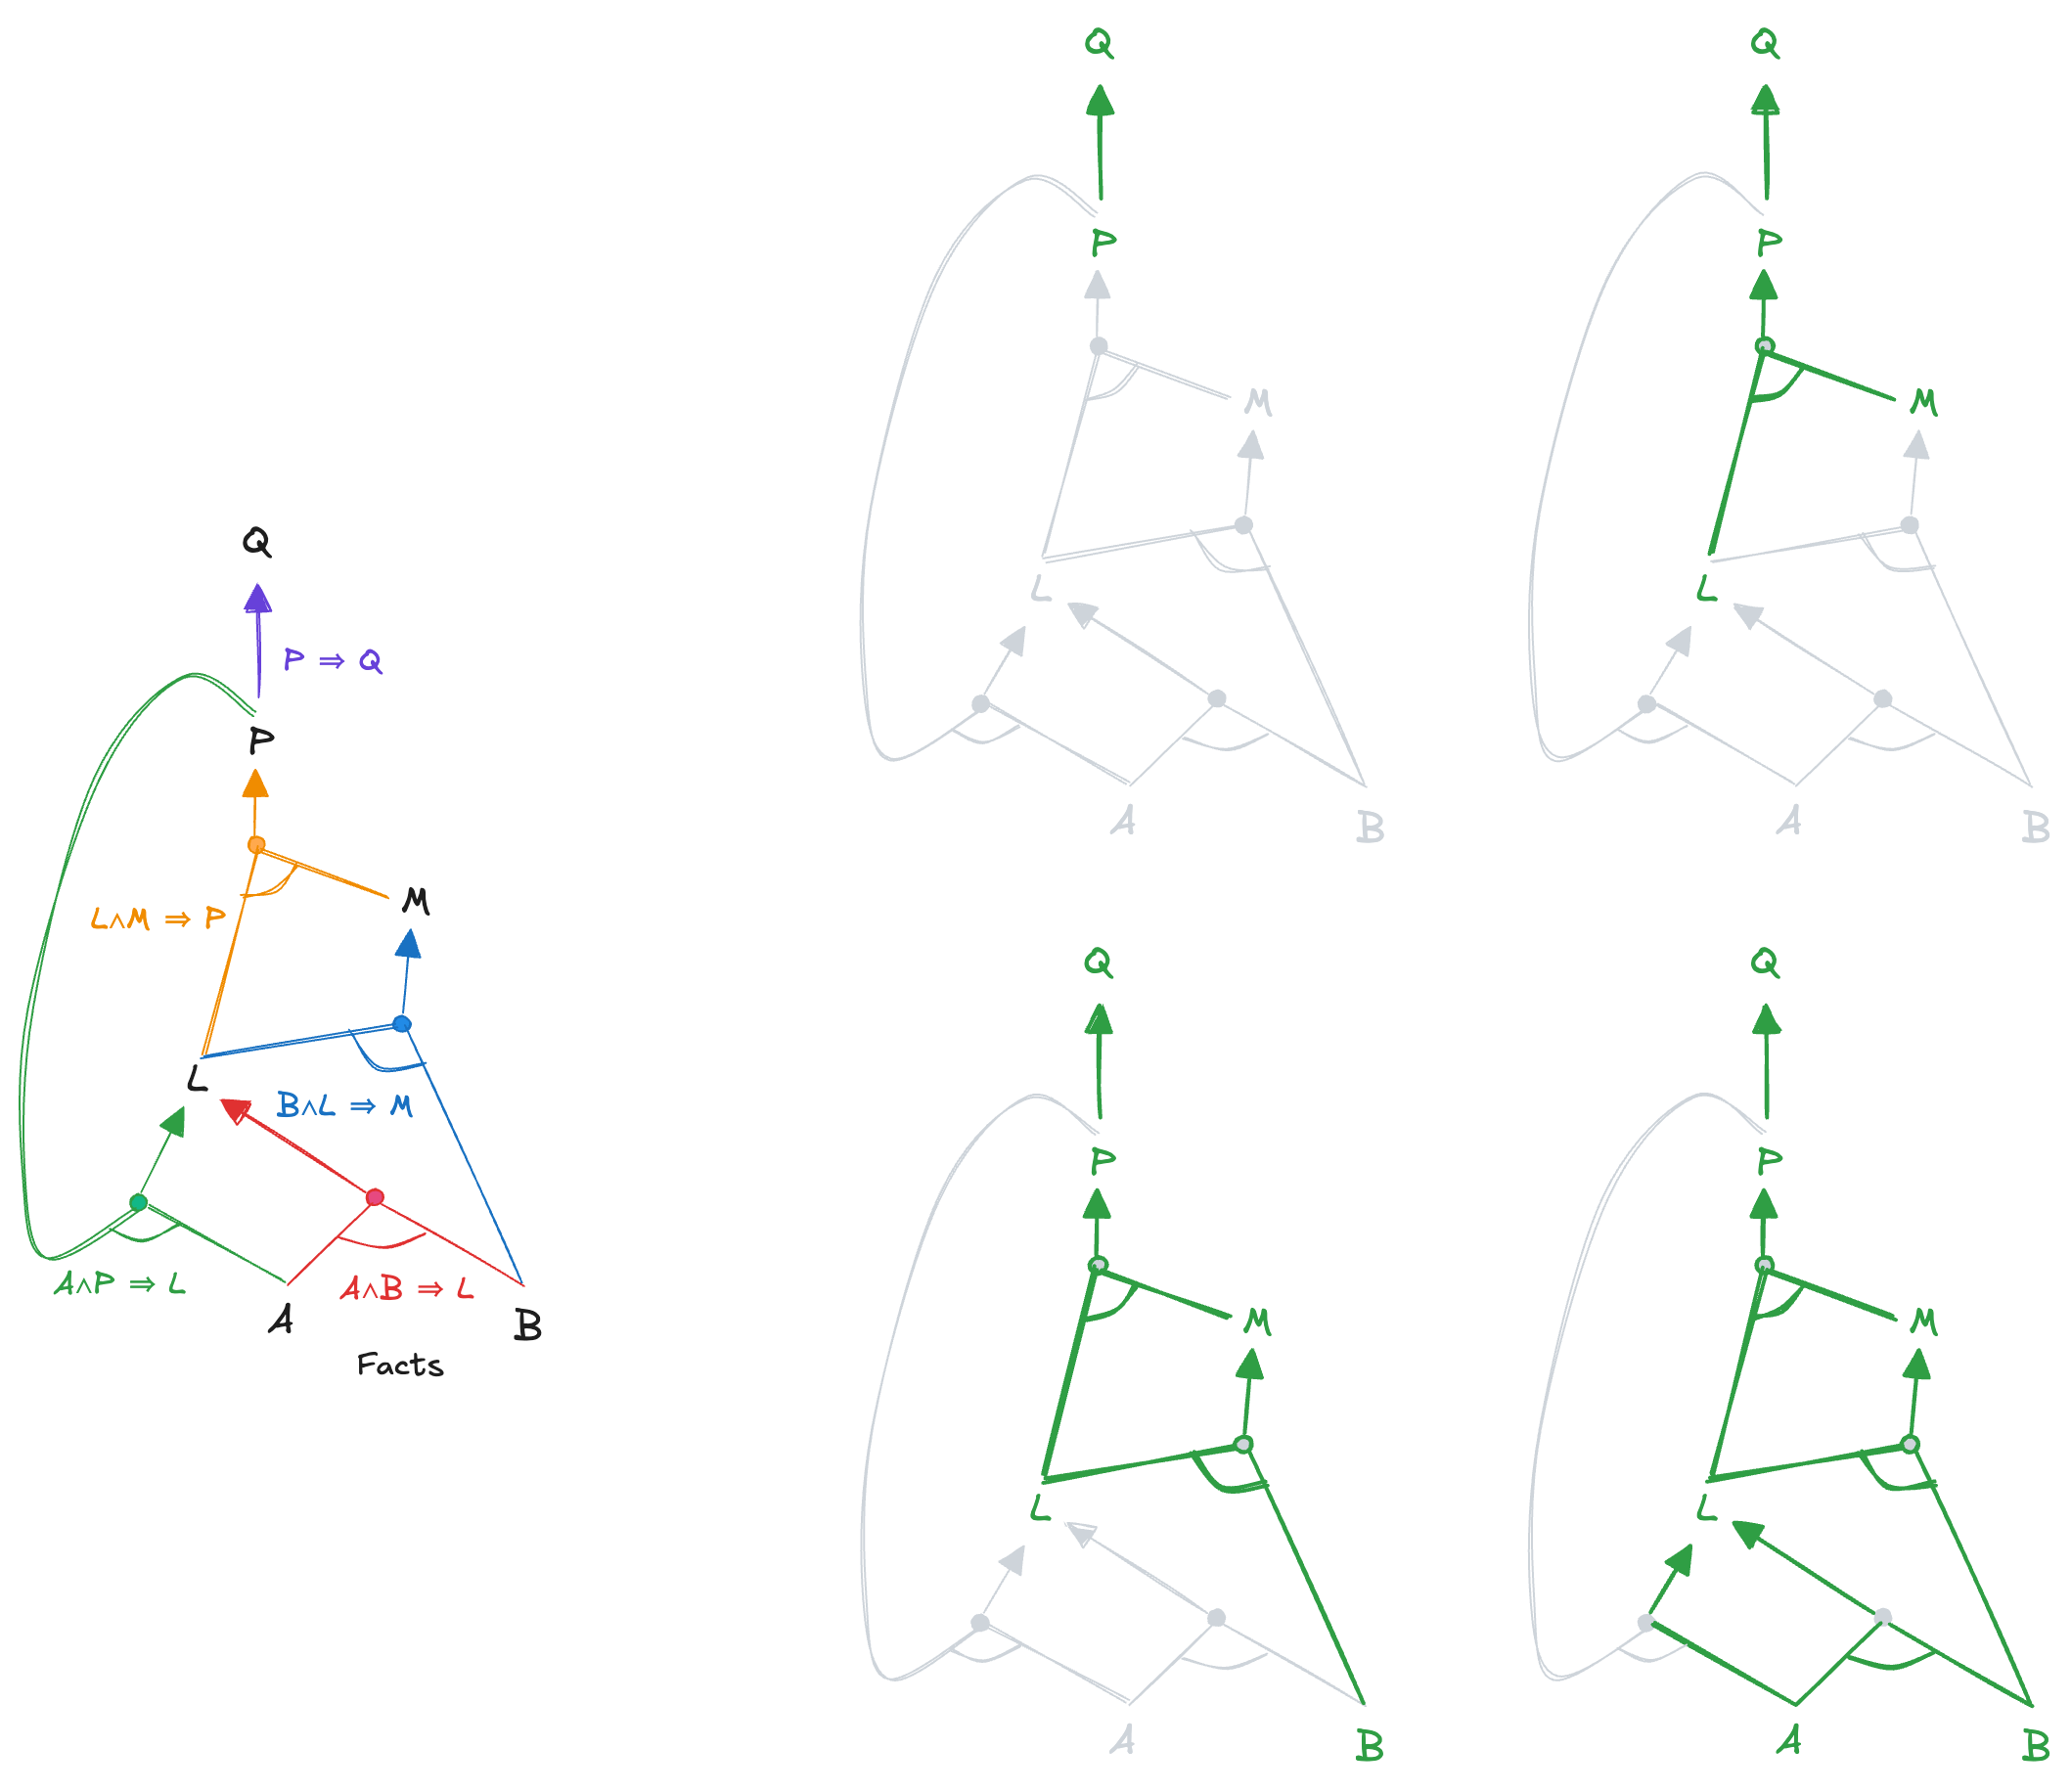

We can wrote the algorithm similar to the forward-chaining algorithm, but with a few key differences: the agenda

In [666]:
def backward_chaining_entail(kb, query, path=None, verbose=True):

    # Create a path 
    if path is None:
        path = set()

    # Avoid infinite loops in the same path
    if repr(query) in path:
        return False
    
    # Add the current query to the path
    if verbose: print("Current query:", query)
    path.add(repr(query))

    # If query is a known fact
    for clause in kb.sentences:
        if clause.op != 'IMPLIES' and repr(clause) == repr(query):
            if verbose: print("Found in known facts:", clause)
            return True

    # Otherwise, check if it can be derived from the rules
    for clause in kb.sentences:
        
        if clause.op == 'IMPLIES' and repr(clause.args[1]) == repr(query):

            if verbose: print("Checking rule:", clause)

            body = clause.args[0]
            premises = list(body.args) if body.op == 'AND' else [body]

            # Recursively prove all premises
            if all(backward_chaining_entail(kb, p, path.copy(), verbose) for p in premises):
                return True
            
    # If we exhaust all rules and facts without finding the query, it is not entailed      
    return False

We can use the method on the previous example:

In [668]:
result = backward_chaining_entail(kb, Q)
print(f"Does the knowledge base entail {Q}? {'Yes' if result else 'No'}")

Current query: Q
Checking rule: (P -> Q)
Current query: P
Checking rule: ((L & M) -> P)
Current query: L
Checking rule: ((A & P) -> L)
Current query: A
Found in known facts: A
Checking rule: ((A & B) -> L)
Current query: A
Found in known facts: A
Current query: B
Found in known facts: B
Current query: M
Checking rule: ((B & L) -> M)
Current query: B
Found in known facts: B
Current query: L
Checking rule: ((A & P) -> L)
Current query: A
Found in known facts: A
Checking rule: ((A & B) -> L)
Current query: A
Found in known facts: A
Current query: B
Found in known facts: B
Does the knowledge base entail Q? Yes


Backward chaining is a form of **goal-directed reasoning** in which **inference starts from a specific query** and **works backward to identify the conditions that must hold for the query to be true**. It is particularly well-suited for answering targeted questions such as "What action should I take next?" or "Where are my keys?2. One of its key advantages is efficiency: backward chaining **focuses only on the relevant facts and rules needed to support the goal**, often avoiding the need to process the entire knowledge base.

### Problem examples

To illustrate the inference methods discussed, we now consider a series of example problems that highlight how logical reasoning can be applied to derive conclusions from a knowledge base.

#### Smart Puzzle

We are now ready to tackle a challenging example: a **smart puzzle**, it is a type of logical problem that demands systematic and thoughtful reasoning. Unlike puzzles that rely on guessing or trial-and-error, smart puzzles present **a set of clues or facts that must be logically combined to reach a definitive conclusion**. Solving them typically involves **multiple steps of deduction**, including indirect reasoning: **not only identifying what must be true, but also ruling out what must be false**, gradually narrowing the space of possibilities. Smart puzzles often hinge on core logical principles such as implication, contradiction, and equivalence. They are carefully crafted so that every clue is meaningful and no information is redundant; the challenge lies not in the complexity of the clues themselves, but in **applying them rigorously and in the correct order**. Classic murder mysteries are well-known examples: the detective must determine the culprit by integrating clues about access, motive, opportunity, and alibis. Each clue may be inconclusive on its own, but together (through logical reasoning) they allow the elimination of false leads and the identification of the only possible solution. Let's consider and example:

In [669]:
# Define atomic propositions:
ButlerInStudy = PL_Expr("Butler in study")
ButlerGuilty = PL_Expr("Butler guilty")
ButlerInKitchen = PL_Expr("Butler in kitchen")
MaidInKitchen = PL_Expr("Maid in kitchen")
GardenerLying = PL_Expr("Gardener lying")

# Create KB
kb = KB()

# 1. If the butler was in the study, then he is guilty
kb.tell(ButlerInStudy >> ButlerGuilty)

# 2. Gardener says he saw the butler in the kitchen
# Gardener's statement: "ButlerInKitchen"
# Gardener tells the truth unless he is lying
kb.tell(~GardenerLying >> ButlerInKitchen)

# 3. If maid was in the kitchen, gardener is lying
kb.tell(MaidInKitchen >> GardenerLying)

# 4. Maid says she was in the kitchen
kb.tell(MaidInKitchen)

# Now ask questions with inference
# Query: Is the butler guilty?
result = forward_chaining_entail(kb, ButlerGuilty)
print(f"Is the butler guilty? {'Yes' if result else 'No'}")

Rules: [(Butler guilty, [Butler in study]), (Butler in kitchen, [¬Gardener lying]), (Gardener lying, [Maid in kitchen])]
Agenda: [Maid in kitchen]
Inferred facts: {Maid in kitchen}
Considering fact: Maid in kitchen
Inferred new fact:  Gardener lying
Agenda: [Gardener lying]
Inferred facts: {Gardener lying, Maid in kitchen}
Considering fact: Gardener lying
Exhausted agenda without finding the query.
Is the butler guilty? No


The maid claims she was in the kitchen, so MaidInKitchen is true. If MaidInKitchen is true, then GardenerLying must be true (from fact 3). If GardenerLying is true, then we cannot trust the gardener's statement that the butler was in the kitchen.
Therefore, we cannot confirm that the butler was not in the study. Because we cannot prove the butler was elsewhere, and if he was in the study he would be guilty, the butler could still be guilty. Let's extend the knowledge base to force the logical conclusion that the butler must be guilty, using a few more facts:

In [670]:
# 5. If not ButlerInKitchen, then ButlerInStudy
kb.tell(~ButlerInKitchen >> ButlerInStudy)

# 6. ButlerInKitchen iff NOT ButlerInStudy (exclusive location)
kb.tell(ButlerInKitchen == ~ButlerInStudy)

# 7. If the gardener is lying, ButlerInKitchen is false
kb.tell(GardenerLying >> ~ButlerInKitchen)

# Ask again if the butler is guilty
result = forward_chaining_entail(kb, ButlerGuilty)
print(f"Is the butler guilty? {'Yes' if result else 'No'}")

Rules: [(Butler guilty, [Butler in study]), (Butler in kitchen, [¬Gardener lying]), (Gardener lying, [Maid in kitchen]), (Butler in study, [¬Butler in kitchen]), (¬Butler in kitchen, [Gardener lying])]
Agenda: [Maid in kitchen, (Butler in kitchen <-> ¬Butler in study)]
Inferred facts: {Maid in kitchen, (Butler in kitchen <-> ¬Butler in study)}
Considering fact: Maid in kitchen
Inferred new fact:  Gardener lying
Agenda: [(Butler in kitchen <-> ¬Butler in study), Gardener lying]
Inferred facts: {Gardener lying, Maid in kitchen, (Butler in kitchen <-> ¬Butler in study)}
Considering fact: (Butler in kitchen <-> ¬Butler in study)
Agenda: [Gardener lying]
Inferred facts: {Gardener lying, Maid in kitchen, (Butler in kitchen <-> ¬Butler in study)}
Considering fact: Gardener lying
Inferred new fact:  ¬Butler in kitchen
Agenda: [¬Butler in kitchen]
Inferred facts: {Gardener lying, Maid in kitchen, (Butler in kitchen <-> ¬Butler in study), ¬Butler in kitchen}
Considering fact: ¬Butler in kitchen


We can now apply the backward reasoning style:

In [671]:
# Ask again if the butler is guilty
result = backward_chaining_entail(kb, ButlerGuilty)
print(f"Is the butler guilty? {'Yes' if result else 'No'}")

Current query: Butler guilty
Checking rule: (Butler in study -> Butler guilty)
Current query: Butler in study
Checking rule: (¬Butler in kitchen -> Butler in study)
Current query: ¬Butler in kitchen
Checking rule: (Gardener lying -> ¬Butler in kitchen)
Current query: Gardener lying
Checking rule: (Maid in kitchen -> Gardener lying)
Current query: Maid in kitchen
Found in known facts: Maid in kitchen
Is the butler guilty? Yes


Both algorithms successfully solve this smart puzzle and correctly conclude that the butler is guilty. However, they differ in their approach: forward chaining systematically derives all consequences from the known facts, while backward chaining focuses only on what is necessary to prove the specific query. Each method excels in different contexts: forward chaining is well-suited for **agents that need to maintain a continuously updated view of the world**, whereas backward chaining is ideal for **goal-driven tasks such as diagnosis or answering targeted questions**.

#### Wumpus World

We can reconsider the Wumpus World example we discussed earlier, applying the inference methods we have learned. The Wumpus World is a classic problem in artificial intelligence that involves reasoning about a grid-based environment inhabited by a Wumpus, pits, and an agent. The agent must navigate the world while avoiding dangers and collecting gold. In order to apply the propositional logic to the reasoning around the Wumpus world, we need to formalize the knowledge base. First, we define the symbols to be used to represent the facts about the world:

- Pxy represents a pit in [x,y]
- Wxy represents a wumpus in [x,y]
- Bxy represents a breeze in [x,y]
- Sxy represents true if there is a smell in [x,y]

In the NxN Wumpus world, we need to define symbols for all NxN rooms. In ordert to simplify the notation, we limit to the square around the agent starting position, like in the informal reasoning example: 

In [688]:
W11 = PL_Expr("W11")
W21 = PL_Expr("W21")
W31 = PL_Expr("W31")
W12 = PL_Expr("W12")
W22 = PL_Expr("W22")
W13 = PL_Expr("W13")

P11 = PL_Expr("P11")
P21 = PL_Expr("P21")
P31 = PL_Expr("P31")
P12 = PL_Expr("P12")
P22 = PL_Expr("P22")
P13 = PL_Expr("P13")

B11 = PL_Expr("B11")
B21 = PL_Expr("B21")
B31 = PL_Expr("B31")
B12 = PL_Expr("B12")
B22 = PL_Expr("B22")
B13 = PL_Expr("B13")

S11 = PL_Expr("S11")
S21 = PL_Expr("S21")
S31 = PL_Expr("S31")
S12 = PL_Expr("S12")
S22 = PL_Expr("S22")
S13 = PL_Expr("S13")

Then we introduce a set of sentences that capture the **a priori facts** about the environment. In particular:

- A square exhibits a breeze if and only if there exists a pit in an adjacent square.
- A square exhibits a smell if and only if there exists a wumpus in an adjacent square.

These logical relationships are structural properties of any Wumpus World and, as such, must be explicitly formalized for each square in the environment. We explicitly add the information only for the square visited by the agent:

In [689]:
# Create KB
kb = KB()

# Add kwowledge about the breeze
kb.tell(B11 == (P21 | P12))
kb.tell(B21 == (P11 | P22 | P31))
kb.tell(B12 == (P13 | P22 | P11))

# Add kwowledge about the smell
kb.tell(S11 == (W21 | W12))
kb.tell(S21 == (W11 | W22 | W31))
kb.tell(S12 == (W13 | W22 | W11))

We now begin to populate the knowledge base with the **evidence** gathered by the agent as it explores the environment. The agent starts in square [1,1], and it immediately knows that there is neither a pit nor a wumpus in that square:

In [690]:
kb.tell(~P11)
kb.tell(~W11)

Moreover, the agent don't perceive anything in [1,1]:

In [691]:
kb.tell(~B11)
kb.tell(~S11)

Since the agent aims to explore the environment safely, it queries the knowledge base to determine whether the square [2,1] is safe:

In [692]:
print("There is a pit in [2,1]?", resolution_entail(kb, P21, verbose=False))
print("There is a wumpus in [2,1]?", resolution_entail(kb, W21, verbose=False))

There is a pit in [2,1]? False
There is a wumpus in [2,1]? False


It seems that the square [2,1] is safe, at least according to the current knowledge base. The agent moves to square [2,1], and it perceives a breeze, and no smell:

In [693]:
kb.tell(B21)
kb.tell(~S21)

As in the informal reasonig example, we can infere if there is a pit or a wumpus in [1,2] before moving:

In [694]:
print("There is a pit in [1,2]?", resolution_entail(kb, P12, verbose=False))
print("There is a wumpus in [1,2]?", resolution_entail(kb, W12, verbose=False))

There is a pit in [1,2]? False
There is a wumpus in [1,2]? False


Continuing the exploration, the agent moves to square [1,2], where it gathers new evidence: there is no pit, no wumpus, and no breeze, but a smell is perceived:

In [695]:
kb.tell(~P12)
kb.tell(~W12)
kb.tell(~B12)
kb.tell(S12)

At this stage, the agent is able to formally infer the presence of the wumpus in square [1,3] and the absense of a pit in square [2,2], like the informal logical reasoning process outlined in the earlier example:

In [701]:
print("There is the Wumpus in [1,3]?", resolution_entail(kb, W13, verbose=False))
print("There is a pit in [2,2]?", resolution_entail(kb, P22, verbose=False))

There is the Wumpus in [1,3]? True
There is a pit in [2,2]? False


## Knowledge Engineering

To understand the general process of **knowledge-base construction**, we must consider the role of the **knowledge engineer**, a person who studies a specific domain, identifies the key concepts, and develops a formal representation of the objects and relationships within that domain. We illustrate the **knowledge engineering process** using the domain of electronic circuits as a running example and the first-order logic representation of the knowledge base as the final product. In the following sections, we will consider the following digital circuit:

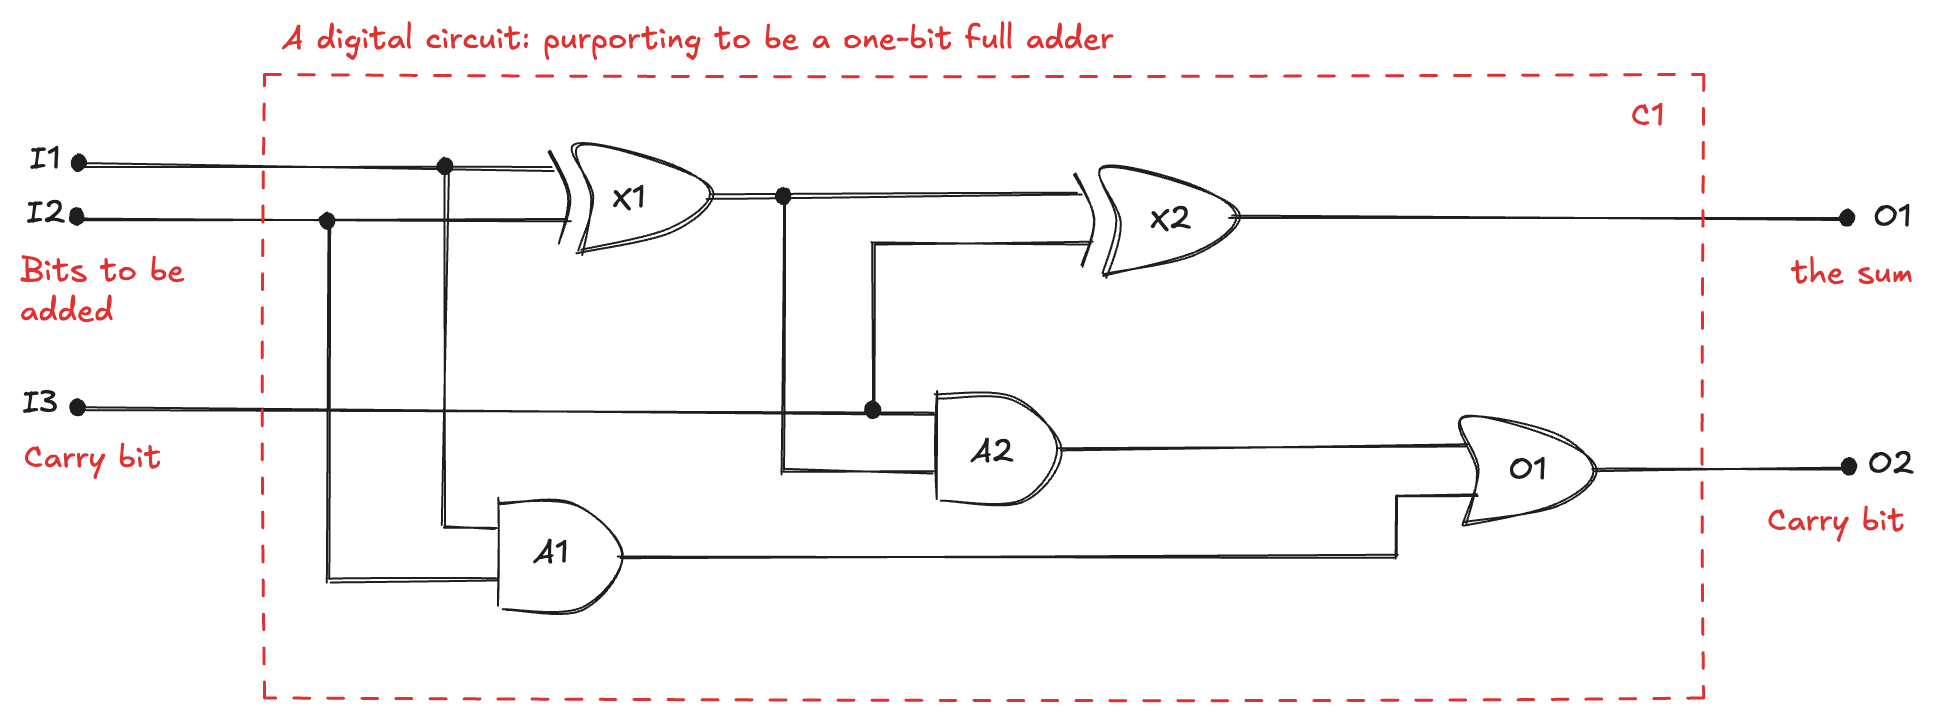

While knowledge engineering projects can vary greatly in content, scope, and complexity, they all share a common set of fundamental steps.

### Identify the questions 

The knowledge engineer must define **the scope of questions** the knowledge base will address and **the types of facts** available for each problem instance. In the case of digital electronic circuits, from a top-level analysis focuses on **functionality**, some interesting questions are: "Does the circuit perform addition correctly?", "If all inputs are high, what is the output of gate A2?". **Structural questions** are also important: "Which gates are connected to the first input terminal?", or "Does the circuit include any feedback loops?". More detailed analyses, such as those involving timing delays, area, power consumption, or manufacturing cost—require additional layers of knowledge.

### Assemble the relevant knowledge

The knowledge engineer may already be an expert in the domain or may need to **collaborate with domain experts** to extract relevant information, a process known as **knowledge acquisition**.

So, what do we know about digital circuits? For our purposes, a circuit consists of wires and logic gates. Signals travel along wires to the input terminals of gates, and each gate produces a signal on its output terminal, which then flows to the input of another gate. To determine the output of a circuit, we must understand how each gate transforms its input signals. In our simplified model, there are four types of gates: AND, OR, and XOR gates, each with two input terminals, and the NOT gate, which has one. All gates have exactly one output terminal. Circuits themselves, like gates, also have input and output terminals. When reasoning about functionality and connectivity, the physical paths taken by wires, their junctions, or layout are not important. What matters are the logical connections between terminals. It is sufficient to state that one output terminal is connected to a particular input terminal, without describing the physical medium of connection. Similarly, attributes such as the size, shape, color, or cost of the components are irrelevant to this level of analysis.

At this stage, the knowledge is **not yet formally represented**. The goal is to **understand the task at hand**, **define the scope of the knowledge base**, and **build a conceptual understanding** of how the domain actually works.

The ontology would change if the goal were different. If the purpose were debugging faulty circuits, it would make sense to include wires in the ontology, since a faulty wire can corrupt the signal it carries. If the focus were on resolving timing faults, we would need to include gate delays. If the goal were product design, factors such as cost and speed relative to competitors would become important. In complex, real-world domains, determining what information is relevant can be difficult. For example, a system for simulating VLSI designs might or might not need to consider stray capacitance or skin effects, depending on the required level of detail. 

### Decide on a vocabulary 

The important domain-level concepts (circuits, terminals, signals, and gates) has to be **translated** into logic-level names (constants, predicates, and functions). We represent each gate as a constant object:

$\displaystyle X1, X2, A1, A2, O1$

and assert the identity of a gate g we a predicate:

$\text{Gate}(g)$

The type of the gate can be represented as a constant, one of the following:

$\displaystyle \text{AND, OR, XOR, NOT}$

and we use a function to map a gate g to its type:

$\text{Type}(g) = \text{XOR} | \text{AND} | \text{OR} | \text{NOT}$

We also represent circuits as constant objects (in the example we have just one):

$\displaystyle C1$

and denote the identity of a circuit c using a predicate:

$\text{Circuit}(c)$

Next we consider terminals, which are identified by the predicate: 

$\text{Terminal}(t)$

Each gate or circuit has associated a number of input and output terminals. We define these using functions to express the nth input and output terminals of a gate or circuit g:

$\displaystyle \text{In}(n, g)$ 
$\displaystyle \text{Out}(n, g)$ 

To state that a gate or circuit g has i input terminals and j output terminals, we use the function:

$\displaystyle \text{Arity}(g, i, j)$

To describe connectivity, to asserts that the output terminal t1 is connected to the input terminal t2 we introduce a predicate: 

$\displaystyle \text{Connected}(t1, t2)$

For example: 

$\displaystyle \text{Connected}(\text{Out}(1, X1), \text{In}(1, X2))$

states that the output of gate X1 is connected to the first input of gate X2.

We need to represent signal values at terminals. We introduce as objects two signal values:

$\displaystyle 1, 0$

representing "on" and "off" respectively, and a function to denotes the signal value for a terminal t:

$\displaystyle \text{Signal}(t) = 1 | 0$

Once the choices have been made, the result is a vocabulary that is known as the **ontology of the domain**. The word ontology means a particular theory of the nature of being or existence. This vocabulary provides a complete formal framework for modeling circuits like the one-bit full adder depicted. It allows us to reason about structure ("which gates and terminals are present and how they are connected?"), about functionality ("how signal values propagate through the circuit?"), and about specific queries ("what is the output given certain inputs?").

### Encode general knowledge about the domain

The knowledge engineer writes down the **axioms** for all the vocabulary terms. This pins down (to the extent possible) the
meaning of the terms, enabling the expert to check the content. Often, this step **reveals misconceptions** or **gaps** in the vocabulary that must be fixed by returning to the previous step and iterating through the process. One sign that we have a good ontology is that we require only a few general rules, which can be stated clearly and concisely. 

In our running example, we can write down the following axioms:

(1) If two terminals are connected, then they have the same signal: 

$\displaystyle \forall t1, t2 \; (\text{Terminal}(t1) \land \text{Terminal}(t2) \land \text{Connected}(t1, t2) \Rightarrow \text{Signal}(t1) = \text{Signal}(t2))$

(2) The signal at every terminal is either 1 or 0:        

$\displaystyle \forall t \; (\text{Terminal}(t) \Rightarrow \text{Signal}(t) = 1 \lor \text{Signal}(t) = 0)$

(3) Connections are commutative:      

$\displaystyle \forall t1, t2 \; (\text{Connected}(t1, t2) \Leftrightarrow \text{Connected}(t2, t1))$

(4) There are four types of gates:        

$\displaystyle \forall g \; (\text{Gate}(g) \land \text{Type}(g) = k \Rightarrow (k = \text{AND} \lor k = \text{OR} \lor k = \text{XOR} \lor k = \text{NOT}))$

(5) An AND gate’s output is 0 if and only if any of its inputs is 0:    

$\displaystyle \forall g \; (\text{Gate}(g) \land \text{Type}(g) = \text{AND} \Rightarrow \text{Signal}(\text{Out}(1, g)) = 0 \Leftrightarrow \exists n \; \text{Signal}(\text{In}(n, g)) = 0)$

(6) An OR gate’s output is 1 if and only if any of its inputs is 1:    

$\displaystyle \forall g \; (\text{Gate}(g) \land \text{Type}(g) = \text{OR} \Rightarrow \text{Signal}(\text{Out}(1, g)) = 1 \Leftrightarrow \exists n \; \text{Signal}(\text{In}(n, g)) = 1)$

(7) An XOR gate’s output is 1 if and only if its inputs are different:      

$\displaystyle \forall g \; (\text{Gate}(g) \land \text{Type}(g) = \text{XOR} \Rightarrow \text{Signal}(\text{Out}(1, g)) = 1 \Leftrightarrow \text{Signal}(\text{In}(1, g)) \neq \text{Signal}(\text{In}(2, g)))$

(8) A NOT gate’s output is different from its input:      

$\displaystyle \forall g \; (\text{Gate}(g) \land \text{Type}(g) = \text{NOT} \Rightarrow \text{Signal}(\text{Out}(1, g)) \neq \text{Signal}(\text{In}(1, g)))$

(9) The gates (except for NOT) have two inputs and one output:      

$\displaystyle \forall g \; (\text{Gate}(g) \land \text{Type}(g) = \text{NOT} \Rightarrow \text{Arity}(g, 1, 1))$   
$\displaystyle \forall g \; (\text{Gate}(g) \land k = \text{Type}(g) \land (k = \text{AND} \lor k = \text{OR} \lor k = \text{XOR}) \Rightarrow \text{Arity}(g, 2, 1))$

(10) A circuit has terminals, up to its input and output arity, and nothing beyond its arity:  

$\displaystyle \forall c, i, j \; (\text{Circuit}(c) \land \text{Arity}(c, i, j) \Rightarrow$       
$\displaystyle \forall n \; (n \leq i \Rightarrow \text{Terminal}(\text{In}(n, c))) \land (n > i \Rightarrow \text{In}(n, c) = \text{Nothing}) \land$       
$\displaystyle  \forall n \; (n \leq j \Rightarrow \text{Terminal}(\text{Out}(n, c))) \land (n > j \Rightarrow \text{Out}(n, c) = \text{Nothing}))$     

(11) Gates, terminals, and signals are all distinct:

$\displaystyle \forall g, t, s \; (\text{Gate}(g) \land \text{Terminal}(t) \land \text{Signal}(s) \Rightarrow g \neq t \land g \neq s \land t \neq s)$

(12) Gates are circuits:

$\displaystyle \forall g \; (\text{Gate}(g) \Rightarrow \text{Circuit}(g))$

### Encode a description of the problem instance

If the ontology has been carefully designed, this step becomes straightforward. It consists of writing simple atomic sentences about specific instances of the concepts already defined in the ontology. For a logical agent, problem instances are typically provided by its sensors. In contrast, a "disembodied" knowledge base (not tied to a physical agent) receives sentences as input, much like traditional programs receive data. In the case of the circuit we start by categorizing the circuit and its component gates:

$\displaystyle \text{Circuit}(C1) \land \text{Arity}(C1, 3, 2)$     
$\displaystyle \text{Gate}(X1) \land \text{Type}(X1) = \text{XOR}$      
$\displaystyle \text{Gate}(X2) \land \text{Type}(X2) = \text{XOR}$      
$\displaystyle \text{Gate}(A1) \land \text{Type}(A1) = \text{AND}$      
$\displaystyle \text{Gate}(A2) \land \text{Type}(A2) = \text{AND}$      
$\displaystyle \text{Gate}(O1) \land \text{Type}(O1) = \text{OR}$       

Then we show the connections between them:

$\displaystyle \text{Connected}(\text{In}(1, C1), \text{In}(1, X1))$  
$\displaystyle \text{Connected}(\text{In}(2, C1), \text{In}(1, X2))$

$\displaystyle \text{Connected}(\text{In}(1, C1), \text{In}(1, A1))$      
$\displaystyle \text{Connected}(\text{In}(2, C1), \text{In}(1, A2))$    

$\displaystyle \text{Connected}(\text{Out}(1, X1), \text{In}(1, X2))$   
$\displaystyle \text{Connected}(\text{In}(3, C1), \text{In}(2, X2))$    
      
$\displaystyle \text{Connected}(\text{In}(3, C1), \text{In}(1, A2))$    
$\displaystyle \text{Connected}(\text{Out}(1, X1), \text{In}(2, A2))$           
     
$\displaystyle \text{Connected}(\text{Out}(1, A2), \text{In}(1, O1))$       
$\displaystyle \text{Connected}(\text{Out}(1, A1), \text{In}(2, O1))$   

$\displaystyle \text{Connected}(\text{Out}(1, X2), \text{Out}(1, C1))$      
$\displaystyle \text{Connected}(\text{Out}(1, O1), \text{Out}(2, C1))$      

### Pose queries to the inference procedure and get answers

This is where the real payoff comes: by allowing the inference procedure to operate on the axioms and problem-specific facts, we can **automatically derive the information we seek**. In doing so, **we eliminate the need to write a custom, application-specific solution algorithm**. For example, we can ask "what combinations of inputs would cause the first output of C1 (the sum bit) to be 0 and the second output of C1 (the carry bit) to be 1?":

The answers are substitutions for the variables in the sentence such that the resulting sentence is entailed by the knowledge base. For example we can use three such substitutions:

$\displaystyle \{i1/0, i2/1, i3/1\}, \{i1/1, i2/0, i3/1\}, \{i1/1, i2/1, i3/0\}$

We can also ask "what are the possible sets of values of all the terminals for the adder circuit?":

$\displaystyle \exists i_1, i_2, i_3, o_1, o_2 \; (\text{Signal}(\text{In}(1, C1)) = i_1 \land \text{Signal}(\text{In}(2, C1)) = i_2 \land \text{Signal}(\text{In}(3, C1)) = i_3 \land \text{Signal}(\text{Out}(1, C1)) = o_1 \land \text{Signal}(\text{Out}(2, C1)) = o_2)$

This query will return a complete input–output table for the device, which can be used to check that it does in fact add its inputs correctly. This is a simple example of **circuit verification**. 

Many domains are amenable to the same kind of structured knowledge-base development, in which more complex concepts are defined on top of simpler concepts.

### Debug and evaluate the knowledge base. 

Unfortunately, the answers to queries are rarely correct on the first attempt. More precisely, the answers will be logically correct **with respect to the knowledge base as written**, assuming a sound inference procedure, but they **may not match the user’s expectations**. For instance, if an axiom is missing, the system may be unable to answer certain queries. This often leads to a substantial **debugging process**. Missing or overly weak axioms can typically be identified by examining where the reasoning process breaks down or fails to produce expected conclusions.

For example, in our digital electronic exampel we forget to assert that:

$\displaystyle 1 \lnot = 0$

Suddenly, the system will be unable to prove any outputs for the circuit, except for the simple input cases 000 and 110. We can pinpoint the problem by asking for the outputs of each gate. For example, we can ask:

$\displaystyle \exists i_1, i_2, o \; (\text{Signal}(\text{In}(1, C1)) = i_1 \land \text{Signal}(\text{In}(2, C1)) = i_2 \land \text{Signal}(\text{Out}(1, X1)) = o)$

which reveals that no outputs are known at X1 for the input cases 10 and 01. Then, we look at the axiom for XOR gates, as applied to X1:

$\displaystyle \text{Signal}(\text{Out}(1, X1)) = 1 \Leftrightarrow \text{Signal}(\text{In}(1, X1)) \neq \text{Signal}(\text{In}(2, X1))$

If the inputs are known to be, say, 1 and 0, then this reduces to:

$\displaystyle \text{Signal}(\text{Out}(1, X1)) = 1 \Leftrightarrow 1 \neq 0$

Now the problem is apparent: the system is unable to infer that:

$\displaystyle \text{Signal}(\text{Out}(1, X1)) = 1$

so we need to tell it that: 

$\displaystyle 1 \lnot = 0$

When we get to the point where there are no obvious errors in our knowledge base, it is tempting to declare success. But unless there are obviously no errors, it is better to **formally evaluate** our system by running it on a **test suite** of queries and measuring how many we get right. Without **objective measurement**, it is too easy to convince ourself that the job is done.